# Análise quantitativa com os microdados do ENEM 2023 — notebook da aula

**Curso:** Métodos Quantitativos / Tópicos de Análise Quantitativa (CAEO/CAO — CBMDF)
**Autor:** André T. Campos

Este notebook é a **parte prática** do curso. Ele segue o percurso da palestra (conhecer a base → descrever → limpar → comparar grupos → testar → relacionar variáveis), com duas ênfases:

1. **Amostragem e tamanho do efeito no centro.** A base do ENEM tem *todos* os participantes. Isso permite algo que nunca acontece no trabalho real: conhecer o valor verdadeiro e verificar se a amostra, o intervalo de confiança e o teste acertam. Toda decisão de tamanho de amostra passa a ter justificativa, e todo teste vem acompanhado de **efeito + IC + tamanho do efeito**.
2. **IA integrada.** Em cada parte aparecem os **prompts dos slides** (caixas *IA*) e, logo depois, o código da **verificação independente** que o analista faz sobre a resposta da IA.

| Parte | Módulo do curso | O que se faz |
|---|---|---|
| 0 | Módulo 1 — evidências e protocolo de IA | preparar o ambiente, ler a base, registrar |
| 1 | Módulos 2 e 3 — descritiva e EDA | conhecer a base, nulos, zeros, definir a base de análise |
| 2 | Módulo 4 — probabilidade e distribuições | normal, TCL, taxa de base, binomial |
| 3 | Módulo 5 — amostragem e IC | erro amostral, cobertura do IC, tamanho de amostra, planos, vieses |
| 4 | Módulo 6 — testes de hipóteses | pré-registro, poder, valor-p × tamanho do efeito, t, ANOVA, qui-quadrado |
| 5 | Módulo 7 — correlação e regressão | dispersão, regressão, resíduos, regressão múltipla, quarteto de Anscombe |

**Fio condutor:** *quanto as notas do ENEM variam com a **renda**, o **tipo de escola**, o **território**, o **sexo** e a **cor/raça**? De que tamanho são essas diferenças, quem fica fora da medição, e com que segurança podemos afirmar, sem confundir associação com causa?* Cada parte responde a um pedaço dessa pergunta. Alguns exemplos ficam fora do fio de propósito (moeda, binomial dos militares, normal das notas, MT ~ CN, treineiros, Anscombe): servem para introduzir conceitos.

**Fonte dos dados:** INEP, Microdados do ENEM 2023 — <https://www.gov.br/inep/pt-br/acesso-a-informacao/dados-abertos/microdados/enem>. Usamos uma versão reduzida (25 colunas, todos os 3.933.955 inscritos, sem o número de inscrição), gerada por `src/gerar_base_aula.py`. **Consulte o dicionário de dados antes de usar qualquer coluna.**

**Reprodutibilidade:** todo sorteio usa a semente `2023`. Rodando de cima para baixo, os números saem iguais aos dos slides.

---
# Parte 0 — Preparação (Módulo 1)

O protocolo de IA do curso tem 7 regras: (1) pergunta e hipótese antes dos dados; (2) não enviar dados sensíveis; (3) pedir código, não números; (4) contexto completo no prompt; (5) pedir premissas e limitações; (6) verificar de forma independente; (7) registrar tudo. Este notebook aplica as regras 3, 6 e 7 em cada parte.

In [1]:
# Bibliotecas (todas disponíveis no Google Colab)
import warnings
from datetime import datetime
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
from statsmodels.stats.power import TTestIndPower, GofChisquarePower
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from statsmodels.stats.multitest import multipletests
from statsmodels.stats.outliers_influence import variance_inflation_factor

warnings.filterwarnings('ignore', category=FutureWarning)
pd.set_option('display.max_columns', 40)
pd.set_option('display.width', 140)

# Semente única do curso (regra 7: registrar a semente)
SEMENTE = 2023
rng = np.random.default_rng(SEMENTE)

In [2]:
# Estilo dos gráficos: títulos que dizem a conclusão, eixos rotulados, sem 3D, paleta fixa
AZUL, LARANJA, VERDE, CINZA, VERMELHO = '#2a78d6', '#eb6834', '#1baf7a', '#8a8984', '#e34948'
mpl.rcParams.update({
    'figure.figsize': (9, 5), 'figure.dpi': 110,
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.color': '#e6e5e0', 'grid.linewidth': 0.8, 'axes.axisbelow': True,
    'axes.titlesize': 12, 'axes.titleweight': 'bold', 'axes.titlelocation': 'left',
    'axes.labelsize': 11, 'legend.frameon': False,
    'axes.prop_cycle': mpl.cycler(color=[AZUL, LARANJA, VERDE]),
})

# Pasta de saída (figuras para os slides). No Colab, é criada na pasta atual.
RAIZ = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
SAIDA = RAIZ / 'saida'
SAIDA.mkdir(exist_ok=True)

def salvar(fig, nome):
    # Salva a figura em saida/ para uso nos slides
    fig.savefig(SAIDA / f'{nome}.png', dpi=200, bbox_inches='tight')

def br(x, casas=1):
    # Formata número no padrão brasileiro: 1.234,5
    return f'{x:,.{casas}f}'.replace(',', 'X').replace('.', ',').replace('X', '.')

def fmt_p(p):
    return '< 0,001' if p < 0.001 else br(p, 3)

In [3]:
# Funções estatísticas usadas em todo o notebook (escritas à mão para que se veja a fórmula)

def ic_media(x, conf=0.95):
    # IC da média pela t de Student: média ± t * S/raiz(n)
    x = np.asarray(x, dtype=float)
    n, m = len(x), x.mean()
    ep = x.std(ddof=1) / np.sqrt(n)
    t = stats.t.ppf((1 + conf) / 2, n - 1)
    return m, m - t * ep, m + t * ep

def d_cohen(a, b):
    # d de Cohen: diferença de médias / desvio padrão combinado
    a, b = np.asarray(a, dtype=float), np.asarray(b, dtype=float)
    na, nb = len(a), len(b)
    sp = np.sqrt(((na - 1) * a.var(ddof=1) + (nb - 1) * b.var(ddof=1)) / (na + nb - 2))
    return (a.mean() - b.mean()) / sp

def magnitude(d):
    # Convenções de Cohen (1988) — referência, não regra de decisão
    d = abs(d)
    return 'desprezível' if d < 0.2 else 'pequeno' if d < 0.5 else 'médio' if d < 0.8 else 'grande'

def comparar(a, b, nome_a='A', nome_b='B'):
    # Teste t de Welch + IC da diferença + d de Cohen: as três coisas que sempre se reportam
    a, b = np.asarray(a, dtype=float), np.asarray(b, dtype=float)
    r = stats.ttest_ind(a, b, equal_var=False)
    ic = r.confidence_interval(0.95)
    d = d_cohen(a, b)
    return pd.Series({'grupo A': nome_a, 'grupo B': nome_b, 'n A': len(a), 'n B': len(b),
                      'média A': a.mean(), 'média B': b.mean(), 'diferença (A−B)': a.mean() - b.mean(),
                      'IC95% inf': ic.low, 'IC95% sup': ic.high, 't': r.statistic, 'p': r.pvalue,
                      'd de Cohen': d, 'magnitude': magnitude(d)})

def relatar(res, unidade='pontos'):
    # Frase-padrão de relatório: efeito + IC + p + tamanho do efeito
    print(f"{res['grupo A']} − {res['grupo B']}: diferença de {br(res['diferença (A−B)'])} {unidade} "
          f"(IC95% [{br(res['IC95% inf'])}; {br(res['IC95% sup'])}]); "
          f"d = {br(res['d de Cohen'], 2)} (efeito {res['magnitude']}); p {fmt_p(res['p'])}; "
          f"n = {br(res['n A'], 0)} e {br(res['n B'], 0)}.")

def classificar(lo, hi, margem):
    # Leitura de relevância: compara o IC95% da diferença com a margem de relevância fixada antes
    if lo > margem or hi < -margem:
        return 'diferença relevante'
    if -margem < lo and hi < margem:
        return 'diferente, mas irrelevante' if (lo > 0 or hi < 0) else 'equivalente na prática'
    if lo > 0 or hi < 0:
        return 'diferente; relevância incerta'
    return 'inconclusivo'

def eta2(y, grupos):
    # Eta ao quadrado: fração da variação total associada aos grupos (SQ entre / SQ total)
    df_ = pd.DataFrame({'y': np.asarray(y, dtype=float), 'g': np.asarray(grupos)})
    media = df_.y.mean()
    g = df_.groupby('g').y.agg(['count', 'mean'])
    sq_entre = (g['count'] * (g['mean'] - media) ** 2).sum()
    sq_total = ((df_.y - media) ** 2).sum()
    return sq_entre / sq_total

## 0.1 Leitura da base

**No Colab**, o notebook baixa a base da *Release* do repositório (`URL_BASE`). Localmente, lê o arquivo da pasta indicada na variável de ambiente `MQ_DADOS` ou, na falta dela, de `dados/` na raiz do projeto. O formato Parquet é colunar e comprimido: 55 MB em vez de 1,7 GB do CSV original, e a leitura leva segundos.

In [4]:
import os
ARQUIVO_LOCAL = Path(os.environ.get('MQ_DADOS', RAIZ / 'dados')) / 'enem2023_aula.parquet'
URL_BASE = 'https://github.com/atc857/metodos_quanti/releases/download/base-v1/enem2023_aula.parquet'

FONTE = ARQUIVO_LOCAL if ARQUIVO_LOCAL.exists() else URL_BASE
if not FONTE:
    raise FileNotFoundError('Defina URL_BASE com o link do arquivo enem2023_aula.parquet.')

insc = pd.read_parquet(FONTE)   # uma linha por INSCRITO
print(f'{len(insc):,} linhas × {insc.shape[1]} colunas'.replace(',', '.'))

3.933.955 linhas × 25 colunas


In [5]:
# Registro da execução (regra 7 do protocolo)
import sys, scipy, statsmodels
print('Executado em:', datetime.now().strftime('%d/%m/%Y %H:%M'))
print('Python', sys.version.split()[0], '| pandas', pd.__version__, '| numpy', np.__version__,
      '| scipy', scipy.__version__, '| statsmodels', statsmodels.__version__)
print('Semente:', SEMENTE, '| Fonte:', 'arquivo local' if FONTE == ARQUIVO_LOCAL else URL_BASE)

Executado em: 07/10/2026 20:09
Python 3.14.7 | pandas 3.0.6 | numpy 2.5.3 | scipy 1.18.1 | statsmodels 0.15.0
Semente: 2023 | Fonte: arquivo local


## 0.2 Dicionário: os rótulos que vamos usar

Os códigos abaixo foram copiados do **Dicionário de Microdados do ENEM 2023** (planilha do INEP). Não deduza o significado de um código pelo nome da coluna: `TP_ESCOLA = 1` é "Não respondeu", e não "pública".

In [6]:
ROT_SEXO = {'F': 'Feminino', 'M': 'Masculino'}
ROT_COR = {0: 'Não declarado', 1: 'Branca', 2: 'Preta', 3: 'Parda', 4: 'Amarela', 5: 'Indígena', 6: 'Não dispõe da informação'}
ROT_CONCLUSAO = {1: 'Já concluiu o EM', 2: 'Concluirá o EM em 2023', 3: 'Concluirá o EM após 2023', 4: 'Não concluiu e não está cursando'}
ROT_ESCOLA = {1: 'Não respondeu', 2: 'Pública', 3: 'Privada'}
ROT_DEPENDENCIA = {1: 'Federal', 2: 'Estadual', 3: 'Municipal', 4: 'Privada'}
ROT_PRESENCA = {0: 'Faltou', 1: 'Presente', 2: 'Eliminado'}
ROT_STATUS_RED = {1: 'Sem problemas', 2: 'Anulada', 3: 'Cópia do texto motivador', 4: 'Em branco', 6: 'Fuga ao tema',
                  7: 'Não atendimento ao tipo textual', 8: 'Texto insuficiente', 9: 'Parte desconectada'}
# Q001 (pai) e Q002 (mãe): até que série estudou
ROT_INSTRUCAO = {'A': 'Nunca estudou', 'B': 'Não completou o 5º ano', 'C': '5º ano, sem o 9º ano',
                 'D': '9º ano, sem o EM', 'E': 'EM, sem faculdade', 'F': 'Faculdade, sem pós',
                 'G': 'Pós-graduação', 'H': 'Não sei'}
# Q006: renda mensal da família (17 faixas ordinais, A a Q; salário mínimo de 2023 = R$ 1.320)
FAIXAS_RENDA = list('ABCDEFGHIJKLMNOPQ')
ROT_RENDA = {'A': 'Nenhuma renda', 'B': 'até 1.320', 'C': '1.320–1.980', 'D': '1.980–2.640', 'E': '2.640–3.300',
             'F': '3.300–3.960', 'G': '3.960–5.280', 'H': '5.280–6.600', 'I': '6.600–7.920', 'J': '7.920–9.240',
             'K': '9.240–10.560', 'L': '10.560–11.880', 'M': '11.880–13.200', 'N': '13.200–15.840',
             'O': '15.840–19.800', 'P': '19.800–26.400', 'Q': 'acima de 26.400'}
# Agrupamento em 4 faixas usado nos Módulos 5 e 6
RENDA_4 = {**dict.fromkeys('AB', '1) até R$ 1.320'), **dict.fromkeys('CDE', '2) R$ 1.320–3.300'),
           **dict.fromkeys('FGH', '3) R$ 3.300–6.600'), **dict.fromkeys('IJKLMNOPQ', '4) acima de R$ 6.600')}

AREAS = ['CN', 'CH', 'LC', 'MT']
NOTAS = ['NU_NOTA_CN', 'NU_NOTA_CH', 'NU_NOTA_LC', 'NU_NOTA_MT', 'NU_NOTA_REDACAO']
NOME_NOTA = {'NU_NOTA_CN': 'Ciências da Natureza', 'NU_NOTA_CH': 'Ciências Humanas', 'NU_NOTA_LC': 'Linguagens',
             'NU_NOTA_MT': 'Matemática', 'NU_NOTA_REDACAO': 'Redação'}

### IA — Prompt do Módulo 1: prompt ruim × prompt bom

O mesmo prompt do slide "Prompt ruim × prompt bom". A pergunta (federais × privadas em Linguagens) é respondida com os dados na Parte 4 (Ex. 1).

**Ruim:** "Analise o ENEM e diga o que é significativo." Sem pergunta, sem variáveis, sem hipótese; convida a varrer os dados e pede números em vez de código.

**Bom: o prompt completo, parte por parte**

```text
Papel: Você é um estatístico revisando uma análise para gestores públicos.

Contexto: Estou analisando os microdados do ENEM 2023 (uma linha por inscrito). Colunas: NU_NOTA_LC
(numérica, 0 a 1000, vazia se ausente); TP_DEPENDENCIA_ADM_ESC (1 federal, 2 estadual, 3 municipal,
4 privada; preenchida só para concluintes de 2023); TP_PRESENCA_LC (1 = presente).

Pergunta: A nota média de Linguagens difere entre escolas federais e privadas? Definido antes de ver
os dados: H0 = médias iguais; α = 0,05; teste bilateral; menor diferença relevante para a decisão:
d = 0,2.

Tarefa: Escreva código Python (pandas, scipy, statsmodels) que: (1) filtre os presentes; (2) calcule
o n para detectar d = 0,2 com poder de 80%; (3) verifique as suposições do teste; (4) execute o
teste; (5) calcule o tamanho do efeito e o IC de 95% da diferença.

Restrições: Não invente colunas; se algo for ambíguo, pergunte antes de supor; comente cada passo em
português; use semente fixa.

Formato: Primeiro as suposições do teste e como verificá-las; depois o código; por fim, como ler
cada saída em linguagem de gestor.
```

**Verificação independente:** peça ao modelo que cite a linha do dicionário que justifica cada coluna usada e compare com a seção 0.2. Se ele não avisar que a dependência administrativa só existe para concluintes de 2023, não leu o dicionário.

---
# Parte 1 — Conhecer a base (Módulos 2 e 3)

> *"Antes de testar qualquer hipótese, conheça seus dados: de onde vêm, o que significa cada coluna, o que está faltando e o que está estranho."*

Roteiro de perfilamento (Módulo 3): origem → estrutura → valores ausentes → códigos → variáveis numéricas → relações → subpopulações.

## 1.1 Estrutura: uma linha = um inscrito

In [7]:
insc.head()

,TP_FAIXA_ETARIA,TP_SEXO,TP_COR_RACA,TP_ST_CONCLUSAO,TP_ESCOLA,IN_TREINEIRO,SG_UF_ESC,TP_DEPENDENCIA_ADM_ESC,CO_MUNICIPIO_PROVA,NO_MUNICIPIO_PROVA,SG_UF_PROVA,TP_PRESENCA_CN,TP_PRESENCA_CH,TP_PRESENCA_LC,TP_PRESENCA_MT,NU_NOTA_CN,NU_NOTA_CH,NU_NOTA_LC,NU_NOTA_MT,TP_STATUS_REDACAO,NU_NOTA_REDACAO,Q001,Q002,Q005,Q006
0,14,M,1,1,1,0,NaN,NaN,5300108,Brasília,DF,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,A,F,5,F
1,12,M,1,1,1,0,NaN,NaN,5300108,Brasília,DF,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,F,E,3,H
2,6,F,1,1,1,0,NaN,NaN,4305108,Caxias do Sul,RS,1,1,1,1,502.0,498.9,475.6,363.2,1.0,700.0,H,E,5,C
3,2,F,3,2,2,0,CE,2.0,2304400,Fortaleza,CE,1,1,1,1,459.0,508.5,507.2,466.7,1.0,880.0,D,D,5,C
4,3,F,3,2,2,0,CE,2.0,2311306,Quixadá,CE,1,1,1,1,402.5,379.2,446.9,338.3,1.0,560.0,B,B,4,B


In [8]:
insc.tail()

,TP_FAIXA_ETARIA,TP_SEXO,TP_COR_RACA,TP_ST_CONCLUSAO,TP_ESCOLA,IN_TREINEIRO,SG_UF_ESC,TP_DEPENDENCIA_ADM_ESC,CO_MUNICIPIO_PROVA,NO_MUNICIPIO_PROVA,SG_UF_PROVA,TP_PRESENCA_CN,TP_PRESENCA_CH,TP_PRESENCA_LC,TP_PRESENCA_MT,NU_NOTA_CN,NU_NOTA_CH,NU_NOTA_LC,NU_NOTA_MT,TP_STATUS_REDACAO,NU_NOTA_REDACAO,Q001,Q002,Q005,Q006
3933950,12,M,1,1,1,0,NaN,NaN,4303103,Cachoeirinha,RS,1,1,1,1,566.2,605.6,613.7,547.3,1.0,540.0,C,E,5,F
3933951,1,F,1,3,1,1,NaN,NaN,3550308,São Paulo,SP,1,1,1,1,377.2,535.6,610.6,644.4,1.0,640.0,F,F,4,F
3933952,3,F,3,2,2,0,NaN,NaN,4205407,Florianópolis,SC,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,E,C,6,B
3933953,2,M,1,2,3,0,NaN,NaN,3507605,Bragança Paulista,SP,1,1,1,1,515.7,539.0,536.0,569.0,1.0,600.0,G,G,3,N
3933954,3,F,3,2,2,0,SP,2.0,3534401,Osasco,SP,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,E,F,4,C


In [9]:
print('Linhas × colunas:', insc.shape)
insc.dtypes.to_frame('tipo').T

Linhas × colunas: (3933955, 25)


,TP_FAIXA_ETARIA,TP_SEXO,TP_COR_RACA,TP_ST_CONCLUSAO,TP_ESCOLA,IN_TREINEIRO,SG_UF_ESC,TP_DEPENDENCIA_ADM_ESC,CO_MUNICIPIO_PROVA,NO_MUNICIPIO_PROVA,SG_UF_PROVA,TP_PRESENCA_CN,TP_PRESENCA_CH,TP_PRESENCA_LC,TP_PRESENCA_MT,NU_NOTA_CN,NU_NOTA_CH,NU_NOTA_LC,NU_NOTA_MT,TP_STATUS_REDACAO,NU_NOTA_REDACAO,Q001,Q002,Q005,Q006
tipo,int64,str,int64,int64,int64,int64,str,float64,int64,str,str,int64,int64,int64,int64,float64,float64,float64,float64,float64,float64,str,str,int64,str


## 1.2 Quem são os inscritos

In [10]:
# Sexo e cor/raça, com rótulos do dicionário e em percentual
sexo = insc.TP_SEXO.map(ROT_SEXO).value_counts()
cor = insc.TP_COR_RACA.map(ROT_COR).value_counts()
display(pd.DataFrame({'n': sexo, '%': (100 * sexo / sexo.sum()).round(1)}))
display(pd.DataFrame({'n': cor, '%': (100 * cor / cor.sum()).round(1)}))

,n,%
TP_SEXO,,
Feminino,2411185,61.3
Masculino,1522770,38.7


,n,%
TP_COR_RACA,,
Parda,1706798,43.4
Branca,1575848,40.1
Preta,509511,13.0
Amarela,64512,1.6
Não declarado,52575,1.3
Indígena,24711,0.6


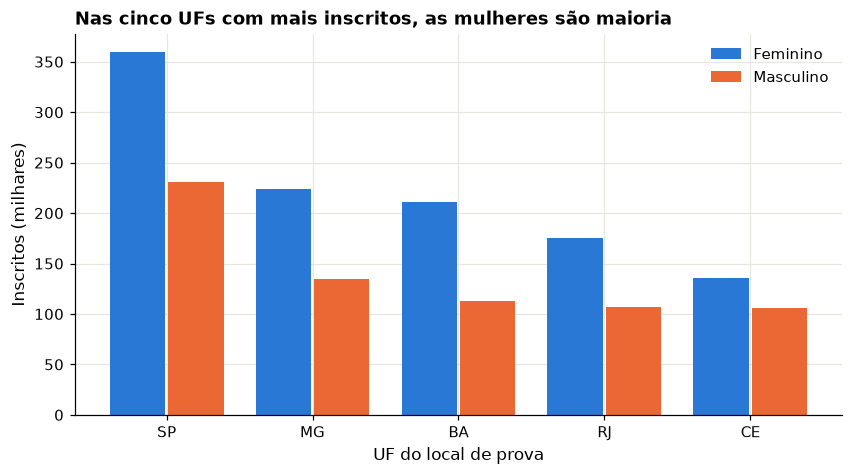

In [11]:
# As 5 UFs com mais inscritos (local de prova) e a divisão por sexo
top5 = insc.SG_UF_PROVA.value_counts().head(5)
tab = (insc[insc.SG_UF_PROVA.isin(top5.index)]
       .groupby(['SG_UF_PROVA', 'TP_SEXO']).size().unstack().loc[top5.index] / 1000)
fig, ax = plt.subplots(figsize=(9, 4.5))
x = np.arange(len(tab))
ax.bar(x - 0.2, tab['F'], width=0.38, label='Feminino', color=AZUL)
ax.bar(x + 0.2, tab['M'], width=0.38, label='Masculino', color=LARANJA)
ax.set_xticks(x, tab.index)
ax.set_ylabel('Inscritos (milhares)')
ax.set_xlabel('UF do local de prova')
ax.set_title('Nas cinco UFs com mais inscritos, as mulheres são maioria')
ax.legend()
plt.show()

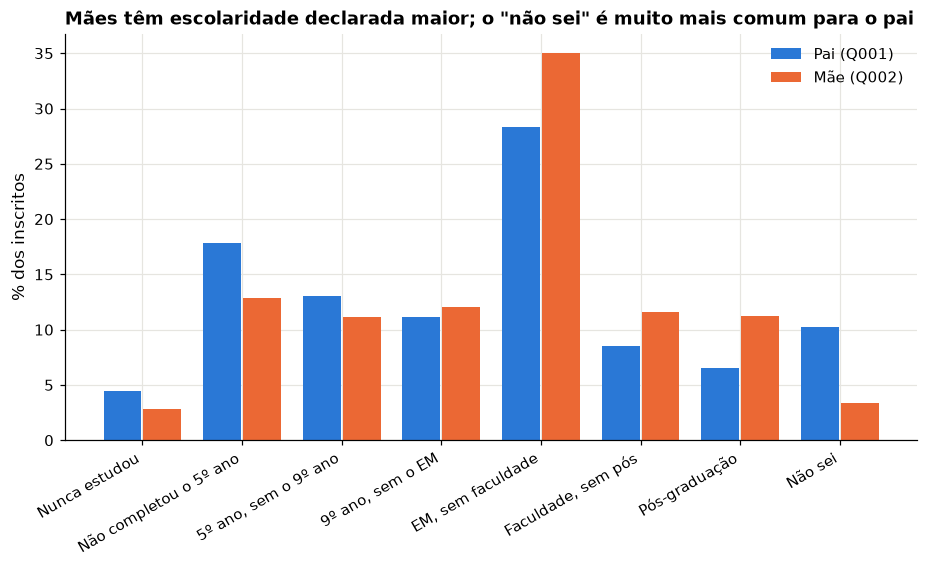

,Pai (Q001),Mãe (Q002)
A,4.4,2.8
B,17.8,12.9
C,13.0,11.1
D,11.1,12.0
E,28.3,35.0
F,8.5,11.6
G,6.5,11.2
H,10.3,3.4


In [12]:
# Escolaridade do pai (Q001) e da mãe (Q002), em % dos inscritos
instr = pd.DataFrame({'Pai (Q001)': insc.Q001.value_counts(normalize=True),
                      'Mãe (Q002)': insc.Q002.value_counts(normalize=True)}).loc[list('ABCDEFGH')] * 100
fig, ax = plt.subplots(figsize=(10, 4.8))
x = np.arange(len(instr))
ax.bar(x - 0.2, instr['Pai (Q001)'], width=0.38, label='Pai (Q001)', color=AZUL)
ax.bar(x + 0.2, instr['Mãe (Q002)'], width=0.38, label='Mãe (Q002)', color=LARANJA)
ax.set_xticks(x, [ROT_INSTRUCAO[k] for k in instr.index], rotation=30, ha='right')
ax.set_ylabel('% dos inscritos')
ax.set_title('Mães têm escolaridade declarada maior; o "não sei" é muito mais comum para o pai')
ax.legend()
plt.show()
instr.round(1)

## 1.3 Valores ausentes: o nulo tem significado

Uma contagem de nulos sem pergunta não diz nada. A pergunta é: **por que** está faltando?

In [13]:
nulos = (insc.isna().mean() * 100).round(1).sort_values(ascending=False)
nulos[nulos > 0].to_frame('% nulos')

,% nulos
TP_DEPENDENCIA_ADM_ESC,75.6
SG_UF_ESC,75.6
NU_NOTA_CN,31.6
NU_NOTA_MT,31.6
NU_NOTA_LC,28.2
NU_NOTA_CH,28.2
NU_NOTA_REDACAO,28.2
TP_STATUS_REDACAO,28.2


In [14]:
# A nota de MT é nula exatamente para quem não esteve presente: o nulo É a ausência
pd.crosstab(insc.TP_PRESENCA_MT.map(ROT_PRESENCA), insc.NU_NOTA_MT.isna().map({True: 'nota vazia', False: 'nota preenchida'}))

NU_NOTA_MT,nota preenchida,nota vazia
TP_PRESENCA_MT,,
Eliminado,0,2212
Faltou,0,1239316
Presente,2692427,0


In [15]:
# A escola (dependência administrativa) só é informada para quem concluirá o EM em 2023, e nem para todos eles
pd.crosstab(insc.TP_ST_CONCLUSAO.map(ROT_CONCLUSAO),
            insc.TP_DEPENDENCIA_ADM_ESC.isna().map({True: 'escola vazia', False: 'escola informada'}))

# Entre os concluintes de 2023: a dependência falta mais para quem declarou escola pública
conc23 = insc[insc.TP_ST_CONCLUSAO == 2]
dep_vazia = conc23.TP_DEPENDENCIA_ADM_ESC.isna()
display(pd.crosstab(conc23.TP_ESCOLA.map(ROT_ESCOLA), dep_vazia.map({True: 'escola vazia', False: 'escola informada'}),
                    margins=True, margins_name='Total'))
print(f'Concluintes de 2023 sem dependência: {br(dep_vazia.sum(), 0)} ({br(100 * dep_vazia.mean())}%) | '
      f'pública: {br(100 * dep_vazia[conc23.TP_ESCOLA == 2].mean())}% | privada: {br(100 * dep_vazia[conc23.TP_ESCOLA == 3].mean())}%')

TP_DEPENDENCIA_ADM_ESC,escola informada,escola vazia,Total
TP_ESCOLA,,,
Não respondeu,2,3,5
Privada,205319,29300,234619
Pública,753185,413355,1166540
Total,958506,442658,1401164


Concluintes de 2023 sem dependência: 442.658 (31,6%) | pública: 35,4% | privada: 12,5%


**Leitura:** comparar "federal × estadual × privada" com essa coluna analisa **apenas concluintes de 2023 com a escola informada**, e não "os candidatos do ENEM". E nem todo concluinte de 2023 tem a dependência: ela falta para 442.658 deles (31,6%), mais entre os que declararam escola pública (35,4%) que entre os de privada (12,5%). Esse subconjunto não é aleatório. População-alvo × população acessível (Módulo 5).

## 1.4 Resumo descritivo das notas (presentes em cada prova)

In [16]:
# Para cada prova, só quem esteve presente naquela prova (redação: dia 1, junto com LC e CH)
linhas = {}
for nota in NOTAS:
    x = insc[nota].dropna()
    linhas[NOME_NOTA[nota]] = {'n': len(x), 'média': x.mean(), 'dp (n−1)': x.std(ddof=1),
                               'mín': x.min(), 'Q1': x.quantile(0.25), 'mediana': x.median(),
                               'Q3': x.quantile(0.75), 'máx': x.max()}
pd.DataFrame(linhas).T.round(1)

,n,média,dp (n−1),mín,Q1,mediana,Q3,máx
Ciências da Natureza,2692427.0,495.8,87.9,0.0,440.5,493.9,551.2,868.4
Ciências Humanas,2822643.0,523.4,88.6,0.0,467.8,530.4,584.9,823.0
Linguagens,2822643.0,518.1,75.5,0.0,471.4,523.1,570.3,820.8
Matemática,2692427.0,533.8,131.6,0.0,431.2,523.6,630.1,958.6
Redação,2822643.0,617.8,214.6,0.0,500.0,620.0,780.0,1000.0


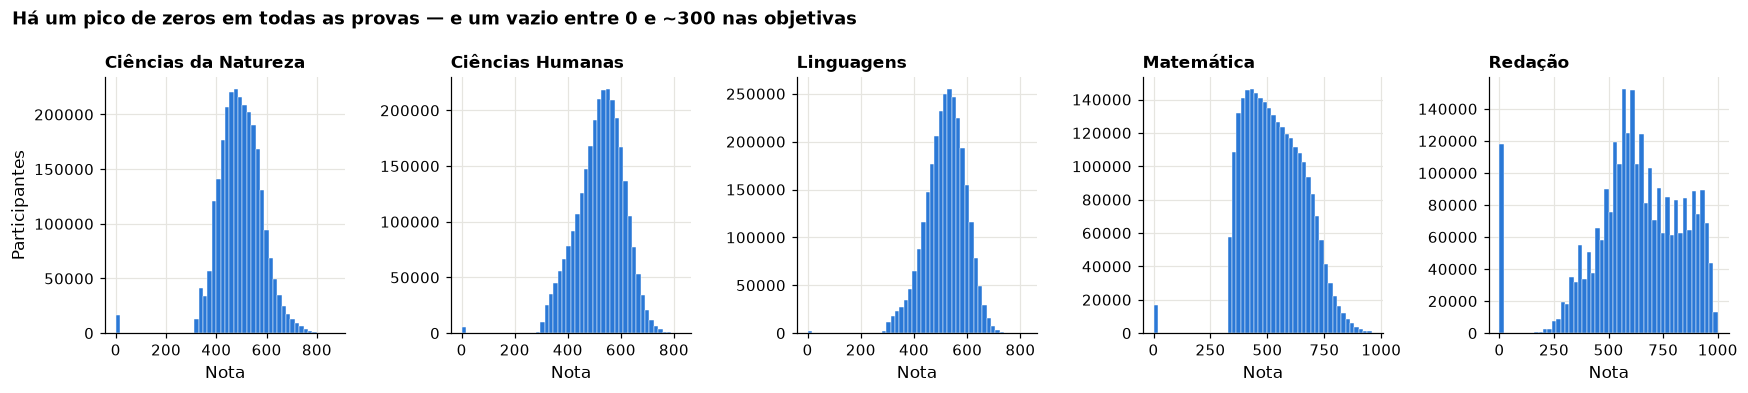

In [17]:
fig, axes = plt.subplots(1, 5, figsize=(16, 3.6), sharey=False)
for ax, nota in zip(axes, NOTAS):
    ax.hist(insc[nota].dropna(), bins=50, color=AZUL, edgecolor='white', linewidth=0.3)
    ax.set_title(NOME_NOTA[nota], fontsize=11)
    ax.set_xlabel('Nota')
axes[0].set_ylabel('Participantes')
fig.suptitle('Há um pico de zeros em todas as provas — e um vazio entre 0 e ~300 nas objetivas', x=0.01, ha='left', fontweight='bold')
plt.tight_layout()
plt.show()

## 1.5 Zeros: habilidade ou registro administrativo?

O histograma mostra zeros isolados. Antes de apagar, investigar.

In [18]:
for nota in NOTAS:
    x = insc[nota].dropna()
    print(f'{NOME_NOTA[nota]:22s} zeros: {br((x == 0).sum(), 0):>8s} | menor nota não nula: {br(x[x > 0].min())} | notas 1000: {br((x == 1000).sum(), 0)}')

Ciências da Natureza   zeros:   16.547 | menor nota não nula: 316,1 | notas 1000: 0
Ciências Humanas       zeros:    5.612 | menor nota não nula: 289,9 | notas 1000: 0
Linguagens             zeros:    2.169 | menor nota não nula: 287,0 | notas 1000: 0
Matemática             zeros:   16.638 | menor nota não nula: 319,8 | notas 1000: 0


Redação                zeros:  117.829 | menor nota não nula: 40,0 | notas 1000: 60


In [19]:
# Redação: o zero acompanha a situação da redação (TP_STATUS_REDACAO)
pd.crosstab(insc.TP_STATUS_REDACAO.map(ROT_STATUS_RED), insc.NU_NOTA_REDACAO == 0,
            colnames=['nota = 0']).sort_values(True, ascending=False)

nota = 0,False,True
TP_STATUS_REDACAO,,
Em branco,0,55403
Fuga ao tema,0,24466
Cópia do texto motivador,0,22505
Texto insuficiente,0,9091
Parte desconectada,0,2443
Anulada,0,2016
Não atendimento ao tipo textual,0,1905
Sem problemas,2704814,0


**O que os zeros são:**
- **Redação:** todo zero corresponde a `TP_STATUS_REDACAO ≠ 1` (anulada, em branco, fuga ao tema etc.). É **zero administrativo**, não medida de habilidade.
- **Provas objetivas:** não existe nota entre 0 e ~290 (a menor nota não nula de MT é 319,8). Conferindo no CSV completo do INEP (colunas `TX_RESPOSTAS_*`, que não estão na base reduzida), **todos os zeros das provas objetivas são cartões sem nenhuma resposta marcada** (16.638 em MT, 16.547 em CN, 5.612 em CH e 2.169 em LC): o participante esteve presente e entregou a prova em branco.

Nos dois casos, o zero **não mede desempenho**. Excluir esses casos é uma decisão justificada; apagar "toda linha com algum zero" sem saber por quê, não.

## 1.6 A base de análise (decisão registrada)

**Decisão:** para as análises de desempenho usaremos os participantes **presentes nas quatro provas objetivas**, com **redação sem problemas** (`TP_STATUS_REDACAO = 1`) e **nenhuma prova objetiva em branco** (nota 0). Os inscritos (`insc`) continuam disponíveis para as análises de presença (viés de seleção).

*Limitação a declarar:* quem faltou a um dos dias ou teve a redação anulada sai da base. Esses grupos não são aleatórios (Parte 3.7).

In [20]:
presente_4 = (insc[[f'TP_PRESENCA_{a}' for a in AREAS]] == 1).all(axis=1)
redacao_ok = insc.TP_STATUS_REDACAO == 1
em_branco = (insc[['NU_NOTA_CN', 'NU_NOTA_CH', 'NU_NOTA_LC', 'NU_NOTA_MT']] == 0).any(axis=1)

funil = pd.Series({
    'Inscritos': len(insc),
    'Presentes nas 4 provas objetivas': presente_4.sum(),
    '… e redação sem problemas': (presente_4 & redacao_ok).sum(),
    '… e nenhuma prova objetiva em branco (BASE)': (presente_4 & redacao_ok & ~em_branco).sum(),
})
base = insc[presente_4 & redacao_ok & ~em_branco].copy()
base['MEDIA_GERAL'] = base[NOTAS].mean(axis=1)
base['RENDA_4'] = base.Q006.map(RENDA_4)
display(funil.to_frame('participantes').assign(**{'% dos inscritos': (100 * funil / len(insc)).round(1)}))
print('Zeros restantes na base:', int((base[NOTAS] == 0).sum().sum()))

,participantes,% dos inscritos
Inscritos,3933955,100.0
Presentes nas 4 provas objetivas,2678264,68.1
… e redação sem problemas,2585115,65.7
… e nenhuma prova objetiva em branco (BASE),2569190,65.3


Zeros restantes na base: 0


## 1.7 Correlação entre as notas (exploração; volta na Parte 5)

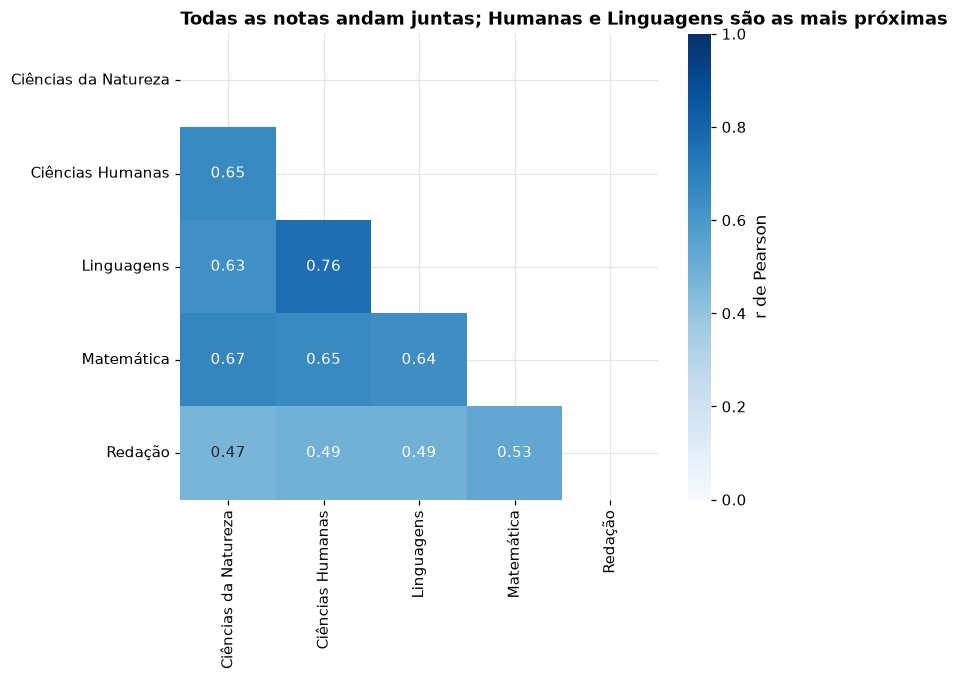

In [21]:
corr = base[NOTAS].rename(columns=NOME_NOTA).corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
fig, ax = plt.subplots(figsize=(7, 5.5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='Blues', mask=mask, vmin=0, vmax=1, ax=ax,
            cbar_kws={'label': 'r de Pearson'})
ax.set_title('Todas as notas andam juntas; Humanas e Linguagens são as mais próximas')
plt.show()

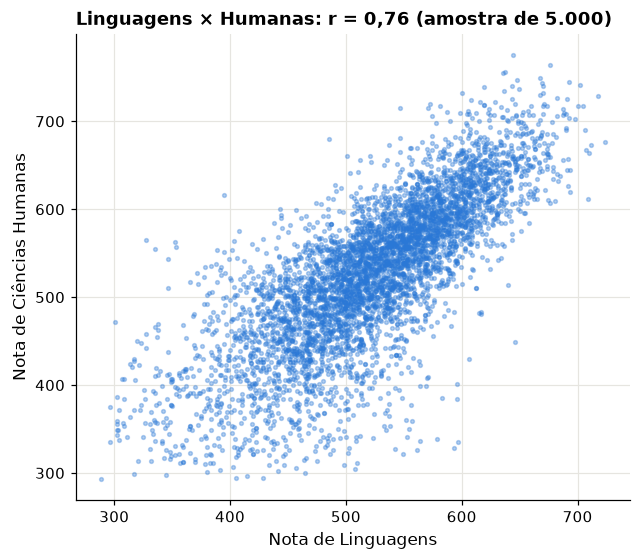

In [22]:
# Com 2,5 milhões de pontos, o gráfico de dispersão vira uma mancha: desenhar uma amostra
amostra_disp = base.sample(5000, random_state=SEMENTE)
fig, ax = plt.subplots(figsize=(6.5, 5.5))
ax.scatter(amostra_disp.NU_NOTA_LC, amostra_disp.NU_NOTA_CH, s=6, alpha=0.35, color=AZUL)
ax.set_xlabel('Nota de Linguagens')
ax.set_ylabel('Nota de Ciências Humanas')
ax.set_title(f"Linguagens × Humanas: r = {br(corr.loc['Linguagens', 'Ciências Humanas'], 2)} (amostra de 5.000)")
plt.show()

## 1.8 Comparação entre as regiões do Brasil

In [23]:
REGIAO = {'AC': 'Norte', 'AL': 'Nordeste', 'AP': 'Norte', 'AM': 'Norte', 'BA': 'Nordeste', 'CE': 'Nordeste',
          'DF': 'Centro-Oeste', 'ES': 'Sudeste', 'GO': 'Centro-Oeste', 'MA': 'Nordeste', 'MT': 'Centro-Oeste',
          'MS': 'Centro-Oeste', 'MG': 'Sudeste', 'PA': 'Norte', 'PB': 'Nordeste', 'PR': 'Sul', 'PE': 'Nordeste',
          'PI': 'Nordeste', 'RJ': 'Sudeste', 'RN': 'Nordeste', 'RS': 'Sul', 'RO': 'Norte', 'RR': 'Norte',
          'SC': 'Sul', 'SP': 'Sudeste', 'SE': 'Nordeste', 'TO': 'Norte'}
base['REGIAO'] = base.SG_UF_PROVA.map(REGIAO)
reg = base.groupby('REGIAO')[NOTAS].mean().rename(columns=NOME_NOTA)
reg.insert(0, 'n', base.REGIAO.value_counts())
reg.sort_values('Matemática', ascending=False).round(1)

,n,Ciências da Natureza,Ciências Humanas,Linguagens,Matemática,Redação
REGIAO,,,,,,
Sudeste,867248,517.4,548.7,540.2,571.6,666.1
Sul,278918,514.3,544.4,538.3,564.0,647.4
Centro-Oeste,210555,504.4,531.1,524.5,541.2,650.8
Nordeste,942924,487.4,514.5,509.3,518.2,644.7
Norte,269545,479.1,505.9,500.1,494.6,617.0


Média sozinha engana: a tabela agora mostra o **n** de cada grupo. Para dizer se uma diferença é "grande", faltam a **dispersão** (Módulo 2) e a **incerteza** (Módulo 5).

## 1.9 DF por dependência administrativa da escola

**Os microdados de 2023 não trazem o código da escola (`CO_ESCOLA`)**, então a comparação é por dependência administrativa, com o tamanho de cada grupo e o intervalo de confiança.

In [24]:
df_dep = base[base.SG_UF_ESC == 'DF']
linhas = []
for cod, g in df_dep.groupby('TP_DEPENDENCIA_ADM_ESC'):
    m, lo, hi = ic_media(g.NU_NOTA_LC)
    linhas.append({'dependência': ROT_DEPENDENCIA[int(cod)], 'n': len(g), 'média LC': m, 'IC95% inf': lo, 'IC95% sup': hi,
                   'meia-largura do IC': (hi - lo) / 2})
pd.DataFrame(linhas).round(1)

,dependência,n,média LC,IC95% inf,IC95% sup,meia-largura do IC
0,Federal,788,558.3,553.8,562.8,4.5
1,Estadual,9145,520.3,519.0,521.6,1.3
2,Privada,6418,570.0,568.5,571.5,1.5


**Observe a última coluna:** o grupo menor tem o intervalo mais largo. Média de grupo pequeno varia mais, e é por isso que rankings de escolas ou de municípios **sem IC** enganam (Parte 3).

## 1.10 Matemática por faixa de renda: a bivariada que prepara a ANOVA

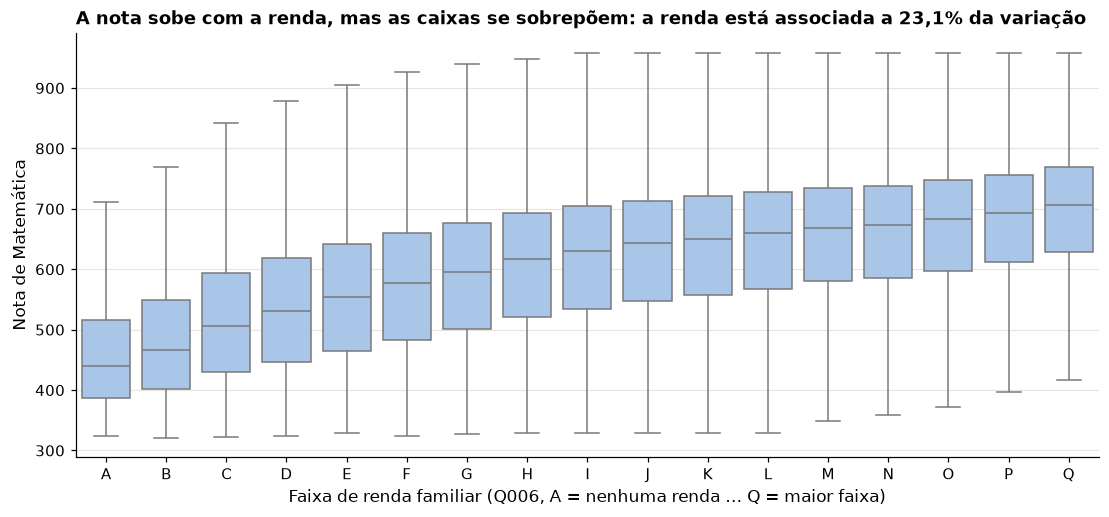

In [25]:
fig, ax = plt.subplots(figsize=(12, 5))
sns.boxplot(data=base, x='Q006', y='NU_NOTA_MT', order=FAIXAS_RENDA, showfliers=False,
            color='#9ec5f4', linewidth=1, ax=ax)
ax.set_xlabel('Faixa de renda familiar (Q006, A = nenhuma renda … Q = maior faixa)')
ax.set_ylabel('Nota de Matemática')
e2 = eta2(base.NU_NOTA_MT, base.Q006)
ax.set_title(f'A nota sobe com a renda, mas as caixas se sobrepõem: a renda está associada a {br(100 * e2)}% da variação')
salvar(fig, 'm2_mt_por_renda_boxplot')
plt.show()

**R² descritivo (BUS 4.6):** a fração da variação total de MT associada às 17 faixas de renda é o **η²** do título. O restante da variação ocorre **dentro** de cada faixa. É a semente da ANOVA (Parte 4) e da regressão (Parte 5).

## 1.11 Gráfico honesto: o mesmo dado, duas mensagens

A mesma série (média de MT por região, seção 1.8) em duas apresentações. À esquerda, o erro mais comum: o eixo vertical começa perto do menor valor e transforma uma diferença de cerca de 15% em uma barra "muitas vezes" maior. À direita, a versão corrigida: eixo a partir de zero, valor e n em cada barra e um título que diz a conclusão que os dados sustentam (Módulo 2).

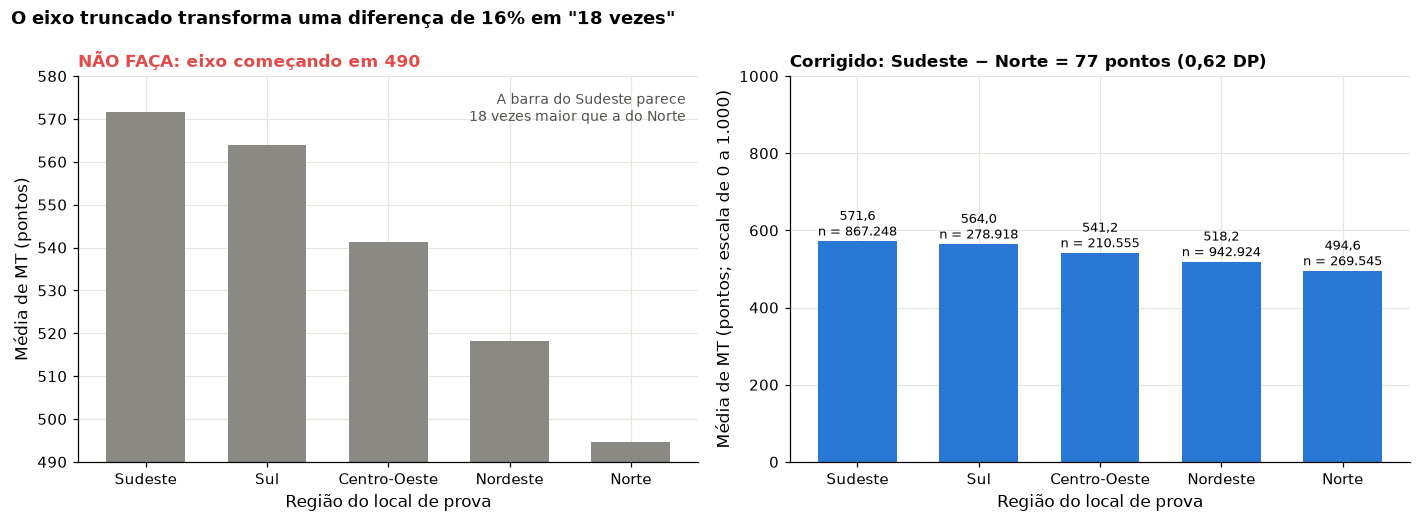

Razão real Sudeste/Norte = 1,16 | razão visual com eixo em 490 = 17,8


In [26]:
# Mesma série, duas apresentações
mt_reg = reg['Matemática'].sort_values(ascending=False)
n_reg = reg.loc[mt_reg.index, 'n']
PISO = 490                                    # início do eixo truncado (o erro a mostrar)
razao_real = mt_reg.iloc[0] / mt_reg.iloc[-1]
razao_visual = (mt_reg.iloc[0] - PISO) / (mt_reg.iloc[-1] - PISO)
dif = mt_reg.iloc[0] - mt_reg.iloc[-1]
dp_mt = base.NU_NOTA_MT.std()

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
ax = axes[0]
ax.bar(mt_reg.index, mt_reg.values, color=CINZA, width=0.65)
ax.set_ylim(PISO, 580)
ax.set_ylabel('Média de MT (pontos)')
ax.set_title(f'NÃO FAÇA: eixo começando em {PISO}', fontsize=11, color=VERMELHO)
ax.text(0.98, 0.96, f'A barra do {mt_reg.index[0]} parece\n{razao_visual:.0f} vezes maior que a do {mt_reg.index[-1]}',
        transform=ax.transAxes, ha='right', va='top', fontsize=9, color='#52514e')
ax = axes[1]
ax.bar(mt_reg.index, mt_reg.values, color=AZUL, width=0.65)
ax.set_ylim(0, 1000)
for i, (v, n) in enumerate(zip(mt_reg.values, n_reg.values)):
    ax.text(i, v + 15, f'{br(v)}\nn = {br(n, 0)}', ha='center', fontsize=8.5)
ax.set_ylabel('Média de MT (pontos; escala de 0 a 1.000)')
ax.set_title(f'Corrigido: {mt_reg.index[0]} − {mt_reg.index[-1]} = {br(dif, 0)} pontos ({br(dif / dp_mt, 2)} DP)', fontsize=11)
for ax in axes:
    ax.set_xlabel('Região do local de prova')
fig.suptitle(f'O eixo truncado transforma uma diferença de {br(100 * (razao_real - 1), 0)}% em "{razao_visual:.0f} vezes"',
             x=0.01, ha='left', fontweight='bold')
plt.tight_layout()
salvar(fig, 'm1_grafico_enganoso_corrigido')
plt.show()
print(f'Razão real {mt_reg.index[0]}/{mt_reg.index[-1]} = {br(razao_real, 2)} | razão visual com eixo em {PISO} = {br(razao_visual, 1)}')

## 1.12 Sexo e cor/raça: as outras dimensões do fio condutor

Cor/raça é **autodeclarada** (rótulos do dicionário, seção 0.2). Duas lições descritivas: (1) a **direção** da diferença entre sexos depende da prova; (2) as diferenças por cor/raça andam junto com a renda, o que volta na regressão (5.4). Os recortes aqui são nacionais: cruzar cor/raça com municípios pequenos ou escolas pode reidentificar pessoas (Módulo 1, LGPD).

TP_SEXO,Feminino,Masculino,homens − mulheres
Ciências da Natureza,492.2,515.0,22.8
Ciências Humanas,525.5,536.6,11.1
Linguagens,521.5,525.9,4.5
Matemática,522.8,569.3,46.5
Redação,663.7,627.3,-36.4


,n,média_MT,dp_MT,média_geral,pct_renda_até_2640
cor,,,,,
Branca,1119070,577.2,127.2,575.3,44.7
Amarela,40854,544.9,138.3,544.8,61.7
Não declarado,31436,544.4,130.3,550.4,62.0
Parda,1062833,514.3,115.7,529.7,72.7
Preta,301740,499.6,107.8,521.1,76.7
Indígena,13257,470.5,101.0,491.8,83.5


η² em MT: cor/raça = 0,070 | sexo = 0,033 | renda (17 faixas) = 0,231


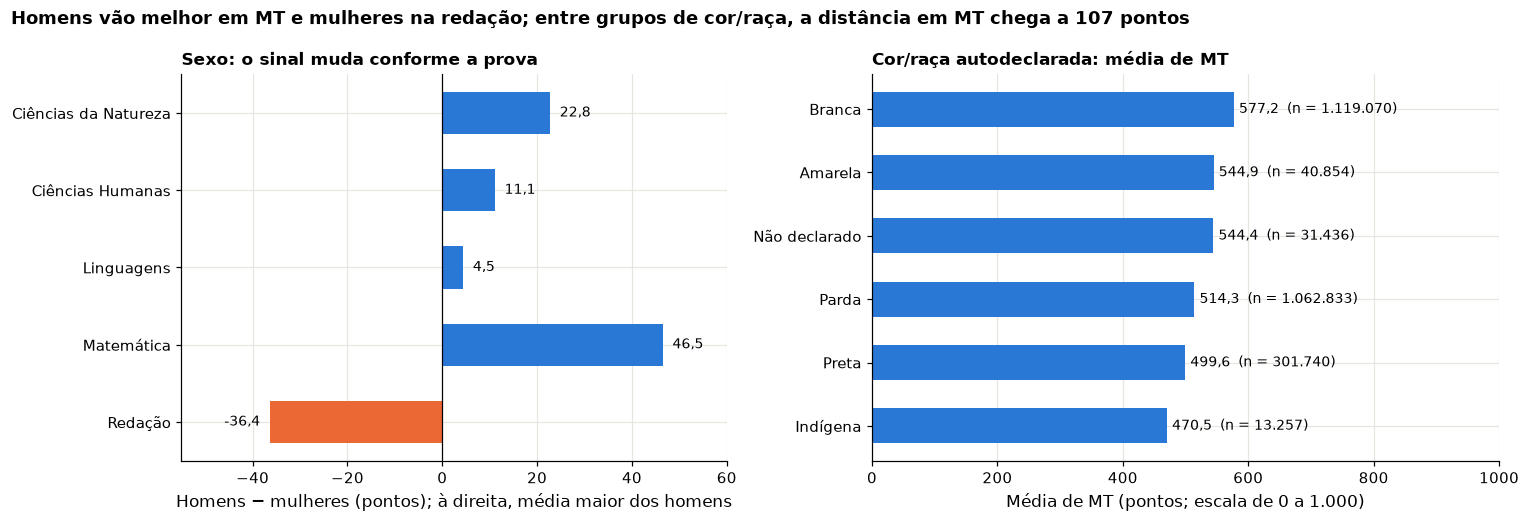

In [27]:
# Sexo: média de cada prova e diferença homens − mulheres (base de análise)
sexo_notas = base.groupby(base.TP_SEXO.map(ROT_SEXO))[NOTAS].mean().rename(columns=NOME_NOTA).T
sexo_notas['homens − mulheres'] = sexo_notas['Masculino'] - sexo_notas['Feminino']
display(sexo_notas.round(1))

# Cor/raça: n, MT, média geral e % com renda familiar até R$ 2.640 (faixas A–D)
cor_tab = (base.assign(cor=base.TP_COR_RACA.map(ROT_COR), renda_ate_2640=base.Q006.isin(list('ABCD')))
           .groupby('cor').agg(n=('NU_NOTA_MT', 'size'), média_MT=('NU_NOTA_MT', 'mean'), dp_MT=('NU_NOTA_MT', 'std'),
                               média_geral=('MEDIA_GERAL', 'mean'), pct_renda_até_2640=('renda_ate_2640', 'mean'))
           .sort_values('média_MT', ascending=False))
cor_tab['pct_renda_até_2640'] *= 100
display(cor_tab.round(1))
print(f'η² em MT: cor/raça = {br(eta2(base.NU_NOTA_MT, base.TP_COR_RACA), 3)} | sexo = {br(eta2(base.NU_NOTA_MT, base.TP_SEXO), 3)} '
      f'| renda (17 faixas) = {br(eta2(base.NU_NOTA_MT, base.Q006), 3)}')

fig, axes = plt.subplots(1, 2, figsize=(14, 4.8), gridspec_kw={'width_ratios': [1, 1.15]})
ax = axes[0]
dif_s = sexo_notas['homens − mulheres']
cores_s = [AZUL if v > 0 else LARANJA for v in dif_s]
ax.barh(range(len(dif_s)), dif_s.values, color=cores_s, height=0.55)
ax.set_yticks(range(len(dif_s)), dif_s.index)
ax.invert_yaxis()
ax.axvline(0, color='black', lw=0.8)
for i, v in enumerate(dif_s.values):
    ax.text(v + (2 if v > 0 else -2), i, br(v), va='center', ha='left' if v > 0 else 'right', fontsize=9)
ax.set_xlim(-55, 60)
ax.set_xlabel('Homens − mulheres (pontos); à direita, média maior dos homens')
ax.set_title('Sexo: o sinal muda conforme a prova', fontsize=11)
ax = axes[1]
ct = cor_tab.iloc[::-1]
ax.barh(range(len(ct)), ct['média_MT'], color=AZUL, height=0.55)
ax.set_yticks(range(len(ct)), ct.index)
for i, (v, n) in enumerate(zip(ct['média_MT'], ct['n'])):
    ax.text(v + 8, i, f'{br(v)}  (n = {br(n, 0)})', va='center', fontsize=9)
ax.set_xlim(0, 1000)
ax.set_xlabel('Média de MT (pontos; escala de 0 a 1.000)')
ax.set_title('Cor/raça autodeclarada: média de MT', fontsize=11)
fig.suptitle(f'Homens vão melhor em MT e mulheres na redação; entre grupos de cor/raça, a distância em MT chega a '
             f'{br(cor_tab.média_MT.max() - cor_tab.média_MT.min(), 0)} pontos', x=0.01, ha='left', fontweight='bold')
plt.tight_layout()
salvar(fig, 'm1_sexo_cor_raca')
plt.show()

**Leitura:** "homens vão melhor no ENEM" ou "mulheres vão melhor" são frases falsas sem dizer **qual prova**. Por cor/raça, as médias mais baixas estão nos grupos com mais renda baixa (última coluna da tabela): a descritiva mostra a associação, mas não separa cor/raça de renda. Isso é o que a regressão múltipla tenta fazer (5.4).

### IA — Prompt do Módulo 2: na descritiva, peça código

```text
Papel: Você é um analista de dados que escreve código Python claro e auditável.

Contexto: DataFrame pandas df com os microdados do ENEM 2023 (cerca de 3,9 milhões de linhas).
Colunas: NU_NOTA_MT (número; vazia se o inscrito faltou); TP_PRESENCA_MT (0 faltou, 1 presente, 2
eliminado); TP_ESCOLA (1 não respondeu, 2 pública, 3 privada).

Pergunta: Como se distribui a nota de Matemática dos presentes em cada tipo de escola?

Tarefa: Escreva código que, só para os presentes em MT, calcule por TP_ESCOLA: n, média, mediana,
desvio padrão amostral, primeiro e terceiro quartis, mínimo e máximo.

Restrições: Declare o ddof do desvio padrão e o método dos quartis. Trate TP_ESCOLA = 1 como
categoria à parte e mostre quantos casos tem. Use groupby, sem laços. Não calcule números: só o
código.

Formato: Código comentado em português e, ao final, 3 decisões de tratamento que você tomou e que eu
devo confirmar.
```

**Verificação independente** (feita na célula abaixo):
- ddof explícito? (pandas = 1; NumPy = 0)
- Método dos quartis declarado?
- Soma dos n = 2.692.427 presentes
- DP da privada: 124,6104 (ddof = 1) × 124,6101 (ddof = 0)
- Refazer uma linha sem groupby: média 630,8

In [28]:
# Verificação independente do código gerado pela IA
pres_mt = insc[insc.TP_PRESENCA_MT == 1]
resumo = (pres_mt.groupby(pres_mt.TP_ESCOLA.map(ROT_ESCOLA)).NU_NOTA_MT
          .agg(n='count', média='mean', mediana='median', dp=lambda s: s.std(ddof=1),
               Q1=lambda s: s.quantile(0.25, interpolation='linear'),
               Q3=lambda s: s.quantile(0.75, interpolation='linear'), mín='min', máx='max'))
display(resumo.round(1))

# (1) os n por grupo somam o total de presentes?
print('Soma dos n =', resumo.n.sum(), '| presentes em MT =', len(pres_mt), '| confere:', resumo.n.sum() == len(pres_mt))
# (2) ddof: pandas usa n−1 por padrão; numpy usa n. A diferença é pequena aqui, mas existe:
x = pres_mt.loc[pres_mt.TP_ESCOLA == 3, 'NU_NOTA_MT'].to_numpy()
print('dp privada  ddof=1:', round(x.std(ddof=1), 4), '| ddof=0:', round(x.std(ddof=0), 4))
# (3) uma linha recalculada sem groupby
print('média privada sem groupby:', round(x.mean(), 1))

,n,média,mediana,dp,Q1,Q3,mín,máx
TP_ESCOLA,,,,,,,,
Não respondeu,1637283,535.9,526.0,133.4,432.4,633.3,0.0,958.6
Privada,221705,630.8,646.7,124.6,548.6,718.8,0.0,958.6
Pública,833439,504.0,492.4,116.1,415.4,586.1,0.0,958.6


Soma dos n = 2692427 | presentes em MT = 2692427 | confere: True
dp privada  ddof=1: 124.6104 | ddof=0: 124.6101
média privada sem groupby: 630.8


### IA — Prompt do Módulo 3: perfil e plano antes

```text
Papel: Você é um analista de qualidade de dados.

Contexto: Arquivo Parquet com os microdados do ENEM 2023 (3,9 milhões de linhas). Colo abaixo o
trecho do dicionário das colunas que usarei (nome, descrição, categorias). [colar o trecho do
dicionário]

Pergunta: A base está pronta para comparar notas por tipo de escola? O que falta, o que está
codificado e o que é estranho?

Tarefa: Escreva um script que gere um relatório de qualidade: (1) nº de linhas; (2) % de nulos por
coluna; (3) para cada NU_NOTA_*, o cruzamento do nulo com o TP_PRESENCA_* da mesma prova; (4)
frequência de TP_ESCOLA e de TP_DEPENDENCIA_ADM_ESC, com os rótulos do dicionário; (5) número de
notas iguais a zero e de notas máximas.

Restrições: Use só colunas do dicionário que enviei; se precisar de outra, pergunte antes. Não
interprete nem tire conclusões. Nenhum dado real vai no prompt: só a estrutura.

Formato: Um bloco de código comentado por item e, ao final, uma tabela dizendo o que cada bloco
produz.
```

**Verificação independente** (feita na célula abaixo):
- Linhas = 3.933.955 (CSV oficial)
- Nulo da nota = ausência, em todas as linhas
- Rótulos vêm do dicionário, não da “memória” do modelo
- TP_ESCOLA = 1 é “Não respondeu”, não “pública”
- Causa proposta pela IA é hipótese: confira na documentação do INEP

In [29]:
# Verificação: os números do relatório gerado pela IA devem bater com estes
print('Linhas (CSV oficial tem 3.933.955 linhas de dados):', len(insc))
for a in AREAS:
    nula = insc[f'NU_NOTA_{a}'].isna()
    ausente = insc[f'TP_PRESENCA_{a}'] != 1
    print(f'{a}: nota nula = não presente em todas as linhas? {bool((nula == ausente).all())}')
print(insc.TP_ESCOLA.map(ROT_ESCOLA).value_counts(normalize=True).mul(100).round(1).to_dict())

Linhas (CSV oficial tem 3.933.955 linhas de dados): 3933955
CN: nota nula = não presente em todas as linhas? True
CH: nota nula = não presente em todas as linhas? True
LC: nota nula = não presente em todas as linhas? True
MT: nota nula = não presente em todas as linhas? True
{'Não respondeu': 64.4, 'Pública': 29.7, 'Privada': 6.0}


### IA — Outro prompt do Módulo 3: o plano de análise *antes* de olhar os dados

```text
Quero escrever o plano de análise ANTES de ver os resultados.
Pergunta: [pergunta de gestão].
Variáveis: [variáveis e definições].
Gere um modelo de plano com: hipótese nula e alternativa, variável resposta, teste previsto,
nível de significância, critérios de exclusão de dados, comparações previstas (e quantas),
e como o resultado será reportado, inclusive se não for significativo.
Alerte para decisões que, se tomadas depois de ver os dados, inflariam falsos positivos.
```

**Hipóteses anotadas nesta aula** (serão testadas, com regras prévias, na Parte 4):
1. A nota de Linguagens difere entre escolas federais e privadas.
2. A média geral difere entre seis UFs (SP, MG, BA, RJ, RS, DF).
3. A escolaridade do pai está associada à faixa de renda familiar.

---
# Parte 2 — Probabilidade e distribuições (Módulo 4)

> *"Probabilidade responde: se o mundo fosse assim, o que eu veria? Inferência responde o inverso: vi isto, como é o mundo?"*

## 2.1 A normal descreve as notas?

In [30]:
# Regra 68-95-99,7: % de participantes a menos de 1, 2 e 3 desvios padrão da média
linhas = {}
for nota in NOTAS:
    x = base[nota].to_numpy()
    z = (x - x.mean()) / x.std()
    linhas[NOME_NOTA[nota]] = {'média': x.mean(), 'dp': x.std(), 'assimetria': stats.skew(x),
                               '|z|<1 (%)': 100 * (abs(z) < 1).mean(), '|z|<2 (%)': 100 * (abs(z) < 2).mean(),
                               '|z|<3 (%)': 100 * (abs(z) < 3).mean()}
print('Esperado na normal: 68,3% | 95,4% | 99,7%')
pd.DataFrame(linhas).T.round(2)

Esperado na normal: 68,3% | 95,4% | 99,7%


,média,dp,assimetria,|z|<1 (%),|z|<2 (%),|z|<3 (%)
Ciências da Natureza,500.93,78.77,0.35,68.21,95.39,99.57
Ciências Humanas,529.74,83.93,-0.26,67.82,95.18,99.97
Linguagens,523.17,72.26,-0.31,68.80,95.19,99.74
Matemática,540.60,124.91,0.37,62.51,97.39,99.88
Redação,649.81,174.88,-0.05,64.72,97.88,99.98


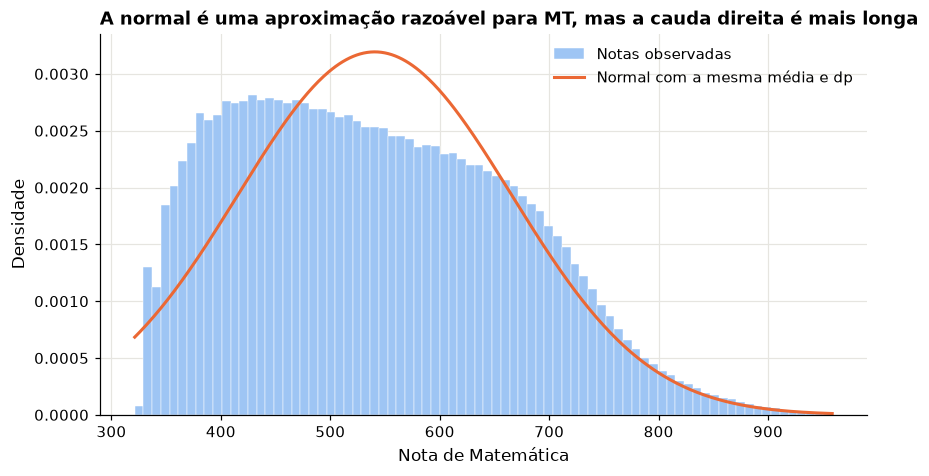

P(MT > 600): normal = 31,7% | observado = 32,7%
P(MT > 700): normal = 10,1% | observado = 12,0%
P(MT > 800): normal = 1,9% | observado = 2,2%
Percentis 1, 25, 50, 75, 95, 99: [336.5 436.9 529.4 634.2 754.2 838.7]


In [31]:
mt = base.NU_NOTA_MT.to_numpy()
MU, SIGMA = mt.mean(), mt.std()   # parâmetros da "população" do curso
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.hist(mt, bins=80, density=True, color='#9ec5f4', edgecolor='white', linewidth=0.3, label='Notas observadas')
xs = np.linspace(mt.min(), mt.max(), 400)
ax.plot(xs, stats.norm.pdf(xs, MU, SIGMA), color=LARANJA, lw=2, label='Normal com a mesma média e dp')
ax.set_xlabel('Nota de Matemática')
ax.set_ylabel('Densidade')
ax.set_title('A normal é uma aproximação razoável para MT, mas a cauda direita é mais longa')
ax.legend()
plt.show()

for lim in (600, 700, 800):
    print(f'P(MT > {lim}): normal = {br(100 * stats.norm.sf(lim, MU, SIGMA))}% | observado = {br(100 * (mt > lim).mean())}%')
print('Percentis 1, 25, 50, 75, 95, 99:', np.percentile(mt, [1, 25, 50, 75, 95, 99]).round(1))

## 2.2 Teorema Central do Limite com uma variável nada normal

A presença na prova é **binária** (0 ou 1). Mesmo assim, a **média de amostras** (a proporção de presentes) fica cada vez mais parecida com a normal, e menos dispersa, à medida que n cresce.

n =   5: dp das proporções = 0.2074 | teórico raiz(p(1−p)/n) = 0.2078
n =  30: dp das proporções = 0.0825 | teórico raiz(p(1−p)/n) = 0.0849


n = 400: dp das proporções = 0.0232 | teórico raiz(p(1−p)/n) = 0.0232


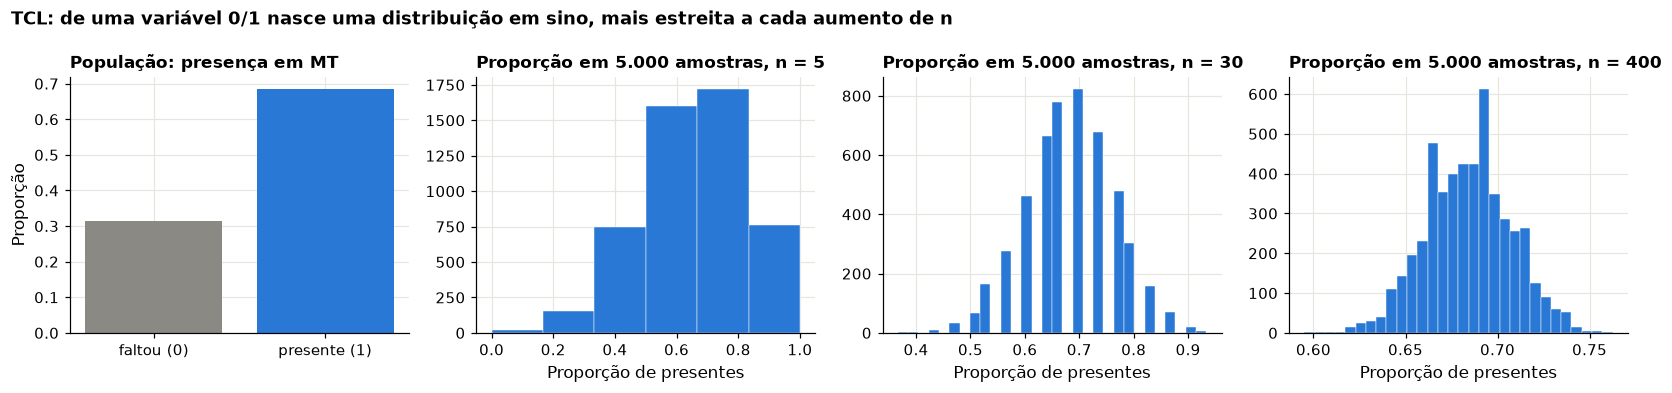

In [32]:
presenca = (insc.TP_PRESENCA_MT == 1).astype(int).to_numpy()
p_pop = presenca.mean()
fig, axes = plt.subplots(1, 4, figsize=(15, 3.6))
axes[0].bar(['faltou (0)', 'presente (1)'], [1 - p_pop, p_pop], color=[CINZA, AZUL])
axes[0].set_title('População: presença em MT', fontsize=11)
axes[0].set_ylabel('Proporção')
for ax, n in zip(axes[1:], (5, 30, 400)):
    medias = rng.choice(presenca, size=(5000, n)).mean(axis=1)
    ax.hist(medias, bins=30 if n > 5 else 6, color=AZUL, edgecolor='white', linewidth=0.3)
    ax.set_title(f'Proporção em 5.000 amostras, n = {n}', fontsize=11)
    ax.set_xlabel('Proporção de presentes')
    print(f'n = {n:3d}: dp das proporções = {medias.std(ddof=1):.4f} | teórico raiz(p(1−p)/n) = {np.sqrt(p_pop * (1 - p_pop) / n):.4f}')
fig.suptitle('TCL: de uma variável 0/1 nasce uma distribuição em sino, mais estreita a cada aumento de n', x=0.01, ha='left', fontweight='bold')
plt.tight_layout()
salvar(fig, 'm3_tcl_presenca')
plt.show()

## 2.3 Taxa de base: P(A|B) não é P(B|A)

In [33]:
rico = base.Q006.isin(list('KLMNOPQ'))       # renda acima de R$ 9.240
top = base.NU_NOTA_MT >= 700
print(f'P(renda K–Q) = {br(100 * rico.mean())}%   (taxa de base)')
print(f'P(MT ≥ 700) = {br(100 * top.mean())}%')
print(f'P(MT ≥ 700 | renda K–Q) = {br(100 * top[rico].mean())}%')
print(f'P(renda K–Q | MT ≥ 700) = {br(100 * rico[top].mean())}%')
pd.crosstab(rico.map({True: 'renda K–Q', False: 'demais faixas'}), top.map({True: 'MT ≥ 700', False: 'MT < 700'}), margins=True)

P(renda K–Q) = 9,7%   (taxa de base)
P(MT ≥ 700) = 12,0%
P(MT ≥ 700 | renda K–Q) = 41,0%
P(renda K–Q | MT ≥ 700) = 33,2%


NU_NOTA_MT,MT < 700,MT ≥ 700,All
Q006,,,
demais faixas,2114404,205611,2320015
renda K–Q,147072,102103,249175
All,2261476,307714,2569190


In [34]:
# A mesma lógica com cor/raça: pretos e pardos são maioria na base, mas não entre as notas altas
pp = base.TP_COR_RACA.isin([2, 3])
branca = base.TP_COR_RACA == 1
print(f'P(preto ou pardo) = {br(100 * pp.mean())}%   (taxa de base)')
print(f'P(MT ≥ 700 | preto ou pardo) = {br(100 * top[pp].mean())}% | P(MT ≥ 700 | branco) = {br(100 * top[branca].mean())}%')
print(f'P(preto ou pardo | MT ≥ 700) = {br(100 * pp[top].mean())}%')

P(preto ou pardo) = 53,1%   (taxa de base)
P(MT ≥ 700 | preto ou pardo) = 6,6% | P(MT ≥ 700 | branco) = 18,4%
P(preto ou pardo | MT ≥ 700) = 29,4%


## 2.4 Binomial: forma, esperança e aproximação normal

X ~ Binomial(n, π): E(X) = nπ e DP = √[nπ(1−π)]. Primeiro, os militares com especialização da caixa *IA* abaixo (π = 0,35) com n = 10 e 50. Depois, o chute numa prova de 5 alternativas (π = 0,2) com n = 5, 20 e 100, comparado à normal com a mesma média e variância. Regra prática: a aproximação é boa quando nπ ≥ 5 e n(1−π) ≥ 5.

n = 10: E(X) = 3,5 | DP = 1,51 | DP da proporção X/n = 0,151
n = 50: E(X) = 17,5 | DP = 3,37 | DP da proporção X/n = 0,067


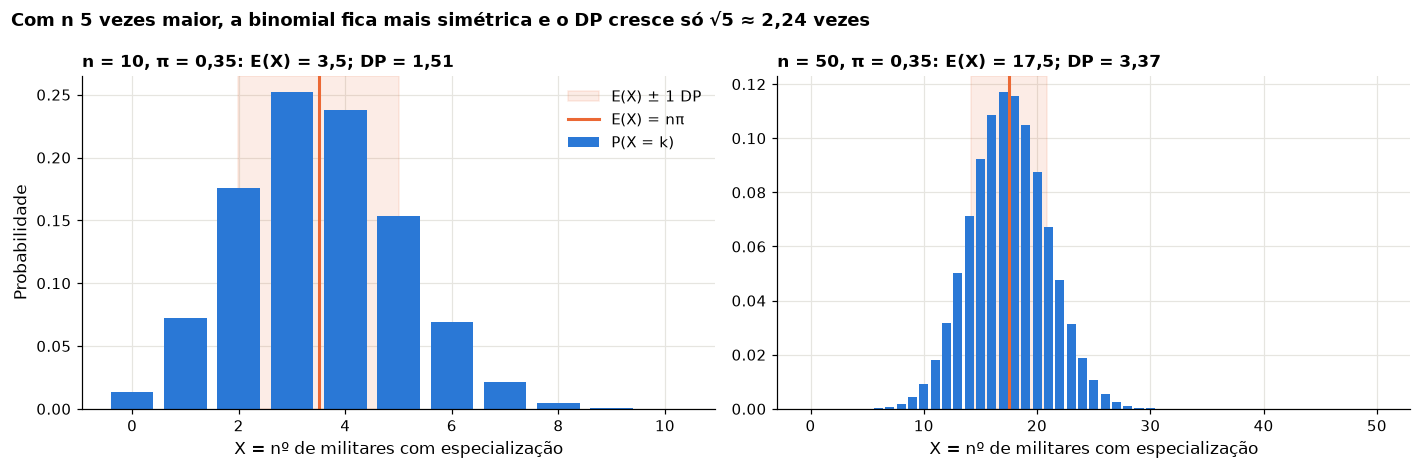

In [35]:
PI_ESP = 0.35
fig, axes = plt.subplots(1, 2, figsize=(13, 4.3))
dps = []
for ax, n in zip(axes, (10, 50)):
    k = np.arange(n + 1)
    mu, dp = n * PI_ESP, np.sqrt(n * PI_ESP * (1 - PI_ESP))
    dps.append(dp)
    ax.axvspan(mu - dp, mu + dp, color=LARANJA, alpha=0.12, label='E(X) ± 1 DP')
    ax.bar(k, stats.binom.pmf(k, n, PI_ESP), color=AZUL, width=0.8, label='P(X = k)')
    ax.axvline(mu, color=LARANJA, lw=2, label='E(X) = nπ')
    ax.set_title(f'n = {n}, π = 0,35: E(X) = {br(mu)}; DP = {br(dp, 2)}', fontsize=11)
    ax.set_xlabel('X = nº de militares com especialização')
    print(f'n = {n}: E(X) = {br(mu)} | DP = {br(dp, 2)} | DP da proporção X/n = {br(dp / n, 3)}')
axes[0].set_ylabel('Probabilidade')
axes[0].legend(loc='upper right')
fig.suptitle(f'Com n 5 vezes maior, a binomial fica mais simétrica e o DP cresce só √5 ≈ {br(dps[1] / dps[0], 2)} vezes',
             x=0.01, ha='left', fontweight='bold')
plt.tight_layout()
salvar(fig, 'm3_binomial')
plt.show()

n =   5: P(X ≤ 1) exata = 0.7373 | normal com correção de continuidade = 0.7119 | diferença = 0.0254
n =  20: P(X ≤ 4) exata = 0.6296 | normal com correção de continuidade = 0.6101 | diferença = 0.0196
n = 100: P(X ≤ 20) exata = 0.5595 | normal com correção de continuidade = 0.5497 | diferença = 0.0097


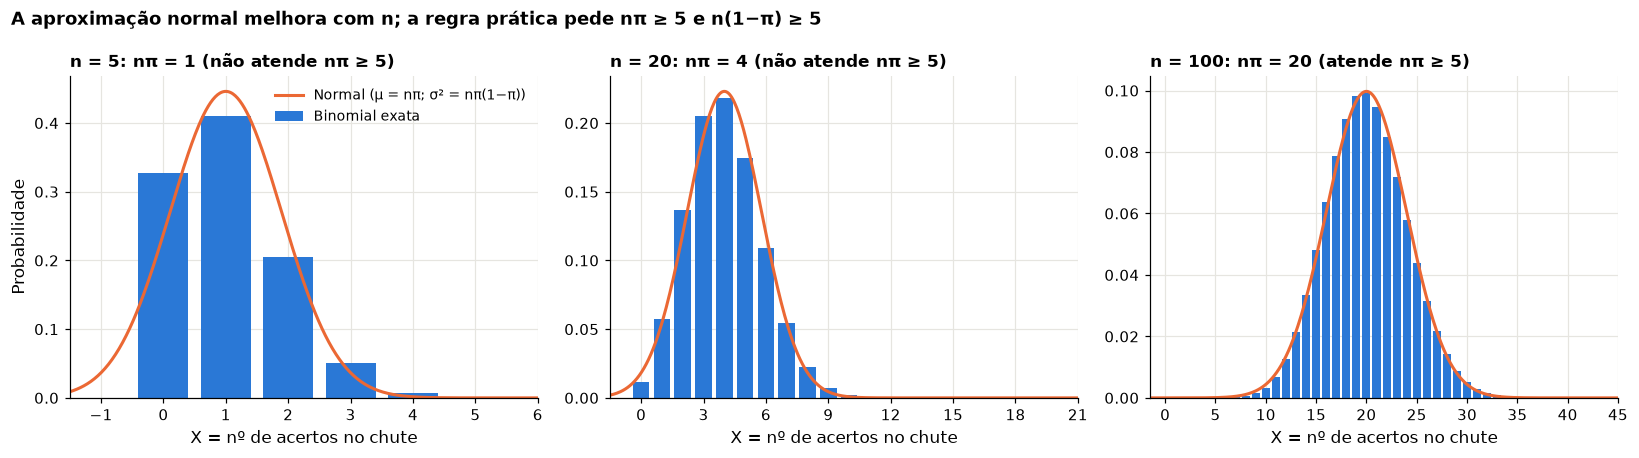

In [36]:
PI_CHUTE = 0.2
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
for ax, n in zip(axes, (5, 20, 100)):
    k = np.arange(n + 1)
    mu, dp = n * PI_CHUTE, np.sqrt(n * PI_CHUTE * (1 - PI_CHUTE))
    ax.bar(k, stats.binom.pmf(k, n, PI_CHUTE), color=AZUL, width=0.8, label='Binomial exata')
    x_max = n + 1 if n < 100 else 45
    xs = np.linspace(-1.5, x_max, 400)
    ax.plot(xs, stats.norm.pdf(xs, mu, dp), color=LARANJA, lw=2, label='Normal (μ = nπ; σ² = nπ(1−π))')
    ax.set_xlim(-1.5, x_max)
    ax.xaxis.set_major_locator(mpl.ticker.MaxNLocator(integer=True))
    atende = 'atende' if min(n * PI_CHUTE, n * (1 - PI_CHUTE)) >= 5 else 'não atende'
    ax.set_title(f'n = {n}: nπ = {br(n * PI_CHUTE, 0)} ({atende} nπ ≥ 5)', fontsize=11)
    ax.set_xlabel('X = nº de acertos no chute')
    c = int(mu)
    exato, aprox = stats.binom.cdf(c, n, PI_CHUTE), stats.norm.cdf(c + 0.5, mu, dp)
    print(f'n = {n:3d}: P(X ≤ {c}) exata = {exato:.4f} | normal com correção de continuidade = {aprox:.4f} | diferença = {abs(exato - aprox):.4f}')
axes[0].set_ylabel('Probabilidade')
axes[0].legend(loc='upper right', fontsize=9)
fig.suptitle('A aproximação normal melhora com n; a regra prática pede nπ ≥ 5 e n(1−π) ≥ 5', x=0.01, ha='left', fontweight='bold')
plt.tight_layout()
salvar(fig, 'm3_binomial_normal')
plt.show()

### IA — Prompts 1 e 2 do Módulo 4

```text
Problema: em um grupo de 12 militares escolhidos ao acaso de um batalhão grande, onde 35% têm
curso de especialização, quero a probabilidade de que pelo menos 6 tenham o curso.

Tarefa:
1) Diga qual distribuição de probabilidade modela X = nº com especialização e por quê.
2) LISTE as suposições necessárias e como cada uma poderia ser violada neste caso concreto.
3) Escreva código Python (scipy.stats) para calcular P(X >= 6) e também uma simulação Monte Carlo
   com 100.000 repetições e semente fixa.
4) Diga se os dois resultados devem coincidir e qual a margem esperada de diferença.
Não calcule "de cabeça": mostre o código e eu executarei.
```

```text
Afirmação de um relatório: "Como 40% dos alunos de alta renda tiram nota alta, 40% dos alunos
de nota alta são de alta renda."
Avalie a afirmação: (a) nomeie o erro de raciocínio, se houver, (b) escreva a probabilidade
condicional correta que a frase deveria estar descrevendo, (c) mostre com números hipotéticos
(tabela 2x2 com 10.000 pessoas) como as duas probabilidades podem diferir muito.
```

A verificação independente em probabilidade é a **simulação**: o cálculo exato e o Monte Carlo devem concordar.

In [37]:
# Verificação do Prompt 1: binomial exata × simulação
exato = stats.binom.sf(5, 12, 0.35)                 # P(X >= 6) = 1 − P(X <= 5)
simulado = (rng.binomial(12, 0.35, size=100_000) >= 6).mean()
print(f'P(X >= 6): exato = {exato:.4f} | simulado = {simulado:.4f} | margem esperada ≈ ±{2 * np.sqrt(exato * (1 - exato) / 100_000):.4f}')

# O mesmo raciocínio com o "chute" no ENEM: 45 itens, 5 alternativas
for k in (15, 18):
    print(f'Chute em 45 itens: P(acertos >= {k}) = {100 * stats.binom.sf(k - 1, 45, 0.2):.2f}% '
          f'(simulado: {100 * (rng.binomial(45, 0.2, 100_000) >= k).mean():.2f}%)')

P(X >= 6): exato = 0.2127 | simulado = 0.2107 | margem esperada ≈ ±0.0026
Chute em 45 itens: P(acertos >= 15) = 2.50% (simulado: 2.44%)
Chute em 45 itens: P(acertos >= 18) = 0.17% (simulado: 0.20%)


---
# Parte 3 — Amostragem e intervalos de confiança (Módulo 5)

**Por que amostrar, se temos todos?** No trabalho real (pesquisa de clima organizacional, auditoria de prontuários de ocorrências, avaliação de satisfação) quase sempre temos **só uma amostra**. Aqui fazemos o contrário: tratamos a base como **população**, conhecemos o valor verdadeiro e **sorteamos amostras** para ver como as estimativas se comportam. É um laboratório.

> *"Amostrar bem é decidir como o acaso entra no estudo. Com sorteio, é possível medir o erro; sem sorteio, o erro é desconhecido e quase sempre tem direção."*

## 3.1 Parâmetro, estimativa e erro amostral

In [38]:
print(f'População (base): N = {br(len(mt), 0)} participantes')
print(f'Parâmetro: média verdadeira de MT μ = {br(MU, 2)} | desvio padrão σ = {br(SIGMA, 2)}')

amostra = rng.choice(mt, size=400, replace=False)   # uma amostra aleatória simples (AAS)
m, lo, hi = ic_media(amostra)
print(f'\nUma AAS de n = 400: média = {br(m)} | S = {br(amostra.std(ddof=1))} | IC95% = [{br(lo)}; {br(hi)}]')
print(f'Erro amostral desta amostra = {br(m - MU)} pontos | o IC contém μ? {lo <= MU <= hi}')

População (base): N = 2.569.190 participantes
Parâmetro: média verdadeira de MT μ = 540,60 | desvio padrão σ = 124,91

Uma AAS de n = 400: média = 541,3 | S = 128,0 | IC95% = [528,7; 553,8]
Erro amostral desta amostra = 0,7 pontos | o IC contém μ? True


## 3.2 A distribuição das médias amostrais

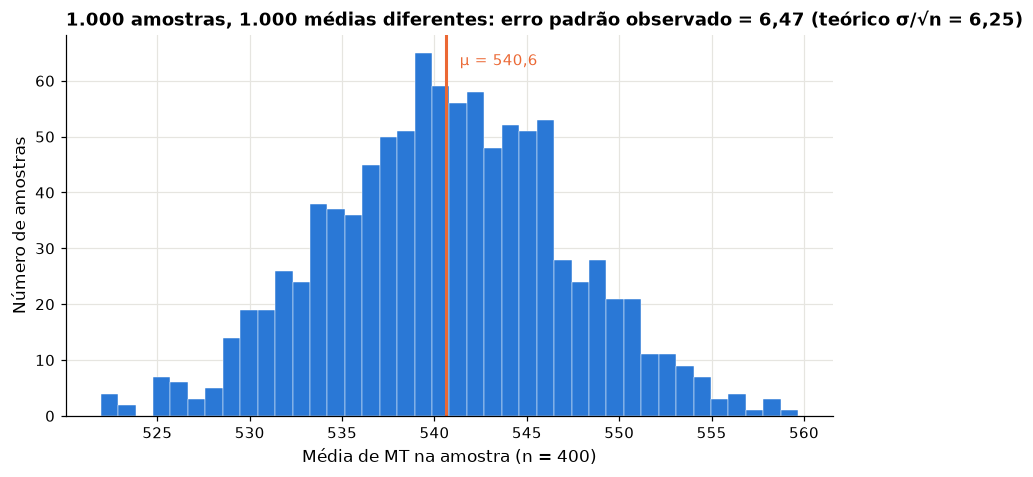

Erro padrão: observado = 6,47 | teórico σ/√n = 6,25; médias entre 521,9 e 559,7


In [39]:
# 1.000 amostras de n = 400 (com N de 2,5 milhões, sortear com ou sem reposição dá o mesmo)
medias_400 = rng.choice(mt, size=(1000, 400)).mean(axis=1)
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.hist(medias_400, bins=40, color=AZUL, edgecolor='white', linewidth=0.3)
ax.axvline(MU, color=LARANJA, lw=2)
ax.text(MU + 0.5, ax.get_ylim()[1] * 0.92, f' μ = {br(MU)}', color=LARANJA)
ax.set_xlabel('Média de MT na amostra (n = 400)')
ax.set_ylabel('Número de amostras')
ax.set_title(f'1.000 amostras, 1.000 médias diferentes: erro padrão observado = {br(medias_400.std(ddof=1), 2)} (teórico σ/√n = {br(SIGMA / 20, 2)})')
salvar(fig, 'm4_distribuicao_medias')
plt.show()
print(f'Erro padrão: observado = {br(medias_400.std(ddof=1), 2)} | teórico σ/√n = {br(SIGMA / 20, 2)}; '
      f'médias entre {br(medias_400.min())} e {br(medias_400.max())}')

## 3.3 Como ler um intervalo de confiança

O parâmetro μ é fixo; **o intervalo é que varia**. "95% de confiança" quer dizer: se repetíssemos o procedimento muitas vezes, cerca de 95% dos intervalos conteriam μ.

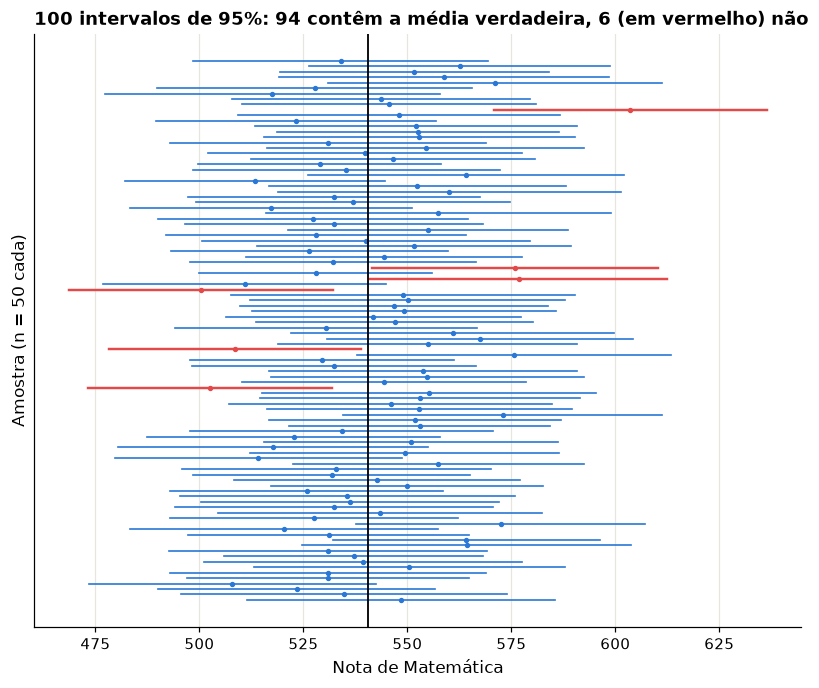

In [40]:
n = 50
amostras = rng.choice(mt, size=(100, n))
medias = amostras.mean(axis=1)
ep = amostras.std(axis=1, ddof=1) / np.sqrt(n)
t = stats.t.ppf(0.975, n - 1)
lo, hi = medias - t * ep, medias + t * ep
acertou = (lo <= MU) & (MU <= hi)

fig, ax = plt.subplots(figsize=(9, 7))
for i in range(100):
    cor = AZUL if acertou[i] else VERMELHO
    ax.plot([lo[i], hi[i]], [i, i], color=cor, lw=1.6 if not acertou[i] else 1.1)
    ax.plot(medias[i], i, 'o', color=cor, ms=2.5)
ax.axvline(MU, color='black', lw=1.2)
ax.set_xlabel('Nota de Matemática')
ax.set_ylabel('Amostra (n = 50 cada)')
ax.set_yticks([])
ax.set_title(f'100 intervalos de 95%: {acertou.sum()} contêm a média verdadeira, {100 - acertou.sum()} (em vermelho) não')
salvar(fig, 'm4_cem_intervalos')
plt.show()

In [41]:
# Cobertura e largura do IC95% para vários n (1.000 amostras por n), com z e com t
linhas = []
for n in (10, 30, 100, 400, 1600):
    a = rng.choice(mt, size=(1000, n))
    med, ep = a.mean(axis=1), a.std(axis=1, ddof=1) / np.sqrt(n)
    tq = stats.t.ppf(0.975, n - 1)
    linhas.append({'n': n,
                   'cobertura z (%)': 100 * ((med - 1.96 * ep <= MU) & (MU <= med + 1.96 * ep)).mean(),
                   'cobertura t (%)': 100 * ((med - tq * ep <= MU) & (MU <= med + tq * ep)).mean(),
                   'largura média do IC t': (2 * tq * ep).mean()})
cobertura = pd.DataFrame(linhas).set_index('n')
cobertura.round(1)

,cobertura z (%),cobertura t (%),largura média do IC t
n,,,
10,90.4,93.8,176.2
30,93.9,94.3,93.1
100,95.8,95.8,49.4
400,95.5,95.5,24.5
1600,95.2,95.2,12.2


**Leitura:** (i) a cobertura fica perto de 95%, como prometido; com n pequeno, o IC pela **t** cobre melhor que o pela z; (ii) **quadruplicar n divide a largura por 2** (lei 1/√n).

## 3.4 Tamanho da amostra: quanto custa a precisão

Fórmulas (BAR 9.5): média, n = (z·σ/E)²; proporção, n = z²·π(1−π)/E². O erro tolerável **E** e a confiança são **decisões do gestor**, não do estatístico.

In [42]:
def n_media(sigma, E, conf=0.95):
    z = stats.norm.ppf((1 + conf) / 2)
    return int(np.ceil((z * sigma / E) ** 2))

def n_proporcao(E, p=0.5, conf=0.95, N=None):
    z = stats.norm.ppf((1 + conf) / 2)
    n0 = z ** 2 * p * (1 - p) / E ** 2
    if N is not None:                       # correção para população finita
        n0 = n0 / (1 + (n0 - 1) / N)
    return int(np.ceil(n0))

S_piloto = amostra.std(ddof=1)              # σ desconhecido: usar a amostra piloto da seção 3.1
for E in (10, 5):
    print(f'Média de MT com erro ±{E} pontos (95%): n = {n_media(S_piloto, E)}')
print('Proporção com erro ±3 p.p., pior caso π = 0,5: n =', n_proporcao(0.03))

# Verificação por simulação: com n para ±5 pontos, 95% das amostras erram menos de 5 pontos?
n5 = n_media(S_piloto, 5)
erros = np.abs(rng.choice(mt, size=(2000, n5)).mean(axis=1) - MU)
print(f'Com n = {n5}: {br(100 * (erros <= 5).mean())}% das 2.000 amostras erraram ≤ 5 pontos (esperado ≈ 95%)')

Média de MT com erro ±10 pontos (95%): n = 630
Média de MT com erro ±5 pontos (95%): n = 2519
Proporção com erro ±3 p.p., pior caso π = 0,5: n = 1068
Com n = 2519: 95,7% das 2.000 amostras erraram ≤ 5 pontos (esperado ≈ 95%)


## 3.5 O plano amostral muda a precisão (mesmo n)

Três planos, todos com **n = 400** e 1.000 repetições:
- **AAS:** sorteio simples de 400 participantes.
- **Estratificada proporcional por renda (4 faixas):** sorteio dentro de cada faixa, na proporção da faixa na população.
- **Conglomerados:** sorteio de 20 municípios de prova (com probabilidade proporcional ao tamanho) e 20 participantes em cada um. Mais barato em campo; menos preciso.

,média das estimativas,viés,erro padrão (dp das estimativas),n equivalente em AAS
AAS,540.88,0.28,6.37,384.44
Estratificada (renda),540.54,-0.06,5.61,495.92
Conglomerados (20×20),540.04,-0.56,10.82,133.30


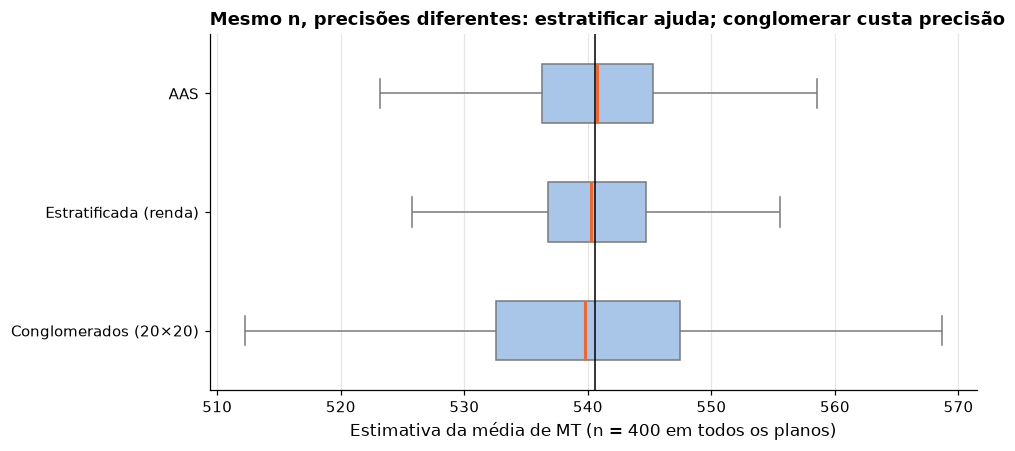

In [43]:
reps, n_total = 1000, 400

# AAS
est_aas = rng.choice(mt, size=(reps, n_total)).mean(axis=1)

# Estratificada proporcional
estratos = {k: base.loc[base.RENDA_4 == k, 'NU_NOTA_MT'].to_numpy() for k in sorted(base.RENDA_4.unique())}
pesos = {k: len(v) / len(mt) for k, v in estratos.items()}
alocacao = {k: round(n_total * w) for k, w in pesos.items()}
est_estr = sum(pesos[k] * rng.choice(v, size=(reps, alocacao[k])).mean(axis=1) for k, v in estratos.items())

# Conglomerados: municípios sorteados com probabilidade proporcional ao nº de participantes
mun = base.CO_MUNICIPIO_PROVA.to_numpy()
notas_por_mun = pd.Series(mt).groupby(mun).apply(np.asarray).to_dict()
est_cong = np.empty(reps)
for r in range(reps):
    sorteados = mun[rng.integers(0, len(mun), 20)]           # PPS: sortear 20 pessoas e usar o município de cada uma
    est_cong[r] = np.mean([rng.choice(notas_por_mun[c], 20).mean() for c in sorteados])

planos = pd.DataFrame({'AAS': est_aas, 'Estratificada (renda)': est_estr, 'Conglomerados (20×20)': est_cong})
resumo_planos = pd.DataFrame({'média das estimativas': planos.mean(), 'viés': planos.mean() - MU,
                              'erro padrão (dp das estimativas)': planos.std(ddof=1)})
resumo_planos['n equivalente em AAS'] = (SIGMA / resumo_planos['erro padrão (dp das estimativas)']) ** 2
display(resumo_planos.round(2))

fig, ax = plt.subplots(figsize=(9, 4.2))
sns.boxplot(data=planos.melt(var_name='plano', value_name='estimativa'), x='estimativa', y='plano', orient='h',
            color='#9ec5f4', width=0.5, showfliers=False, medianprops={'color': LARANJA, 'lw': 2}, ax=ax)
ax.set_ylabel('')
ax.axvline(MU, color='black', lw=1)
ax.set_xlabel('Estimativa da média de MT (n = 400 em todos os planos)')
ax.set_title('Mesmo n, precisões diferentes: estratificar ajuda; conglomerar custa precisão')
salvar(fig, 'm4_planos_amostrais')
plt.show()

**Leitura:** a estratificada é mais precisa porque a renda explica parte da variação (η² da seção 1.10): cada estrato é mais homogêneo. Nos conglomerados, alunos do mesmo município se parecem entre si; 400 alunos de 20 municípios valem bem menos que 400 alunos sorteados de todo o país (última coluna). Os três planos são **sem viés**: todos acertam na média.

## 3.6 Tamanho não cura viés: amostra de conveniência

Uma "pesquisa" que só ouve quem fez a prova no DF, por mais pessoas que entreviste, mira no alvo errado.

Média do DF = 561,8 (N = 48.592) | Brasil = 540,6 | viés = 21,2 pontos


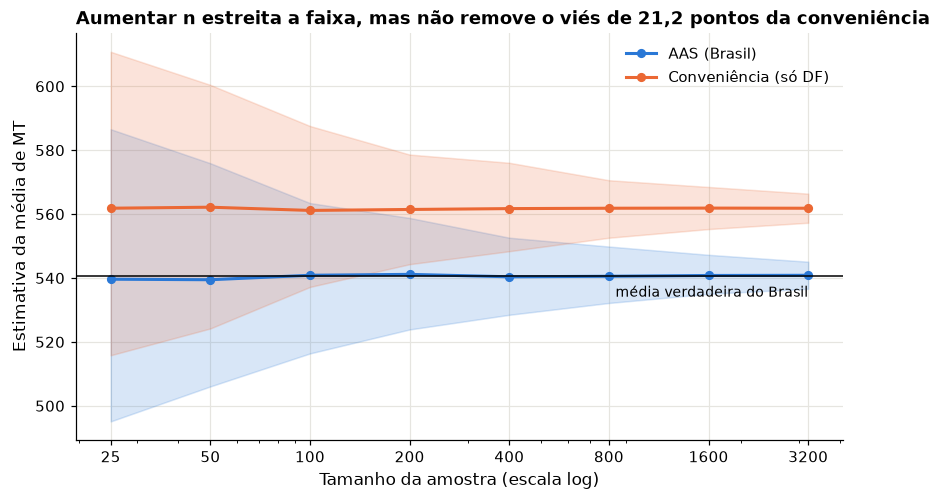

In [44]:
mt_df = base.loc[base.SG_UF_PROVA == 'DF', 'NU_NOTA_MT'].to_numpy()
ns = np.array([25, 50, 100, 200, 400, 800, 1600, 3200])
res = {'AAS (Brasil)': [], 'Conveniência (só DF)': []}
for n in ns:
    res['AAS (Brasil)'].append(rng.choice(mt, size=(500, n)).mean(axis=1))
    res['Conveniência (só DF)'].append(rng.choice(mt_df, size=(500, n)).mean(axis=1))

fig, ax = plt.subplots(figsize=(9, 4.8))
for (nome, ests), cor in zip(res.items(), (AZUL, LARANJA)):
    ests = np.array(ests)
    ax.fill_between(ns, np.percentile(ests, 2.5, axis=1), np.percentile(ests, 97.5, axis=1), color=cor, alpha=0.18)
    ax.plot(ns, ests.mean(axis=1), 'o-', color=cor, lw=2, ms=5, label=nome)
ax.axhline(MU, color='black', lw=1)
ax.text(ns[-1], MU - 3, 'média verdadeira do Brasil', ha='right', va='top', fontsize=9)
ax.set_xscale('log')
ax.set_xticks(ns, [str(v) for v in ns])
ax.set_xlabel('Tamanho da amostra (escala log)')
ax.set_ylabel('Estimativa da média de MT')
ax.set_title(f'Aumentar n estreita a faixa, mas não remove o viés de {br(mt_df.mean() - MU)} pontos da conveniência')
print(f'Média do DF = {br(mt_df.mean())} (N = {br(len(mt_df), 0)}) | Brasil = {br(MU)} | viés = {br(mt_df.mean() - MU)} pontos')
ax.legend(loc='upper right')
salvar(fig, 'm4_conveniencia_vies')
plt.show()

## 3.7 Viés de seleção: quem comparece à prova

A base de notas só tem **quem compareceu**. A presença depende da renda:

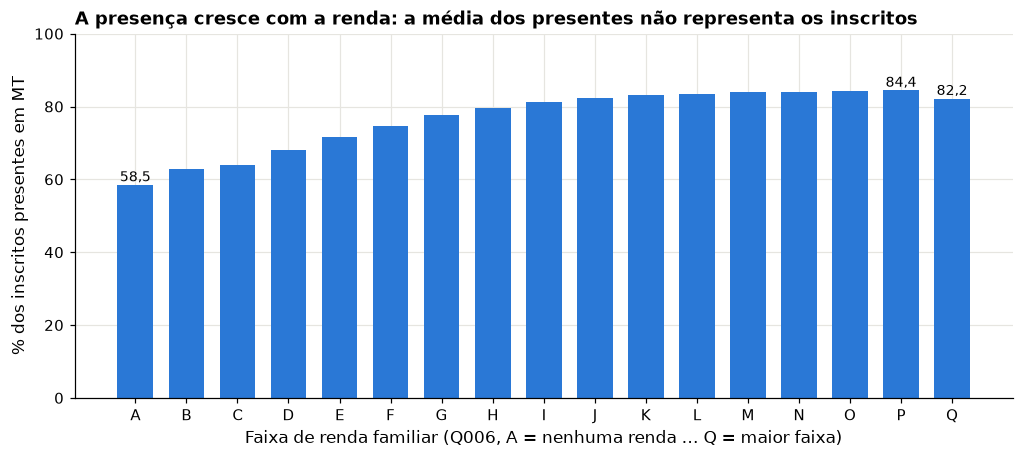

Q006,A,B,C,D,E,F,G,H,I,J,K,L,M,N,O,P,Q
% presentes,58.5,62.9,64.0,67.9,71.6,74.6,77.5,79.6,81.1,82.5,83.2,83.4,84.0,84.1,84.3,84.4,82.2


In [45]:
pres_renda = insc.groupby('Q006').TP_PRESENCA_MT.apply(lambda s: 100 * (s == 1).mean()).loc[FAIXAS_RENDA]
fig, ax = plt.subplots(figsize=(11, 4.3))
ax.bar(pres_renda.index, pres_renda.values, color=AZUL, width=0.7)
for i, v in enumerate(pres_renda.values):
    if i in (0, len(pres_renda) - 1) or i == int(np.argmax(pres_renda.values)):
        ax.text(i, v + 1, br(v), ha='center', fontsize=9)
ax.set_ylim(0, 100)
ax.set_xlabel('Faixa de renda familiar (Q006, A = nenhuma renda … Q = maior faixa)')
ax.set_ylabel('% dos inscritos presentes em MT')
ax.set_title('A presença cresce com a renda: a média dos presentes não representa os inscritos')
salvar(fig, 'm4_presenca_por_renda')
plt.show()
pres_renda.round(1).to_frame('% presentes').T

In [46]:
# A presença também varia por cor/raça? E por sexo? (todos os inscritos)
cor_insc = insc.TP_COR_RACA.map(ROT_COR)
pres_cor = pd.DataFrame({'inscritos': cor_insc.value_counts(),
                         '% presentes em MT': insc.groupby(cor_insc).TP_PRESENCA_MT.apply(lambda s: 100 * (s == 1).mean())})
display(pres_cor.sort_values('% presentes em MT', ascending=False).round(1))
pres_sexo = insc.groupby(insc.TP_SEXO.map(ROT_SEXO)).TP_PRESENCA_MT.apply(lambda s: 100 * (s == 1).mean())
print('% presentes em MT por sexo:', {k: br(v) for k, v in pres_sexo.items()})

,inscritos,% presentes em MT
TP_COR_RACA,,
Branca,1575848,73.6
Amarela,64512,66.6
Parda,1706798,65.8
Não declarado,52575,63.7
Preta,509511,62.5
Indígena,24711,58.8


% presentes em MT por sexo: {'Feminino': '68,5', 'Masculino': '68,4'}


**Leitura:** a presença varia por cor/raça (menor entre indígenas e pretos) e quase não varia por sexo. A base de notas sub-representa os grupos que mais faltam, e eles são, em boa parte, os de menor renda. Toda comparação de notas por cor/raça é feita **entre os presentes**.

## 3.8 Paradoxo de Simpson: treineiros × demais

IN_TREINEIRO,Demais,Treineiros
FAIXA_IDADE,,
1) até 17 anos,556.3,552.4
2) 18 anos,540.7,493.6
3) 19–20 anos,540.0,471.1
4) 21–25 anos,537.8,432.7
5) 26 anos ou mais,506.3,422.4
TOTAL,538.5,549.4


IN_TREINEIRO,% Demais,% Treineiros
FAIXA_IDADE,,
1) até 17 anos,19.6,95.5
2) 18 anos,30.6,3.5
3) 19–20 anos,21.1,0.8
4) 21–25 anos,15.3,0.1
5) 26 anos ou mais,13.5,0.1


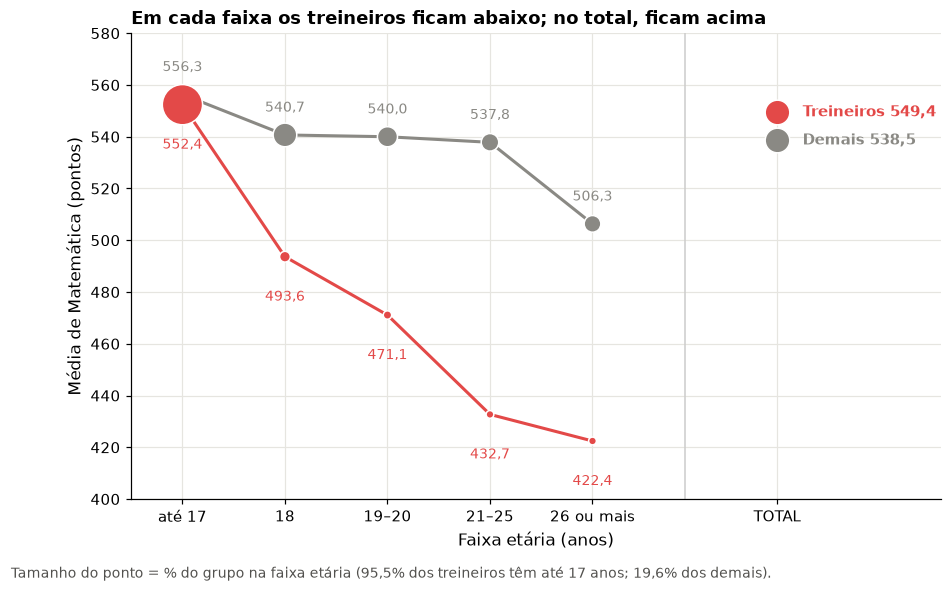

In [47]:
def faixa_etaria(c):
    return ('1) até 17 anos' if c <= 2 else '2) 18 anos' if c == 3 else '3) 19–20 anos' if c <= 5
            else '4) 21–25 anos' if c <= 10 else '5) 26 anos ou mais')
base['FAIXA_IDADE'] = base.TP_FAIXA_ETARIA.map(faixa_etaria)
treino = base.IN_TREINEIRO.map({0: 'Demais', 1: 'Treineiros'})

simpson = base.groupby(['FAIXA_IDADE', treino]).NU_NOTA_MT.mean().unstack()
simpson.loc['TOTAL'] = base.groupby(treino).NU_NOTA_MT.mean()
composicao = pd.crosstab(base.FAIXA_IDADE, treino, normalize='columns') * 100
display(simpson.round(1))
display(composicao.round(1).rename(columns=lambda c: f'% {c}'))

# O gráfico: médias por faixa (linhas), peso de cada faixa no grupo (tamanho do ponto) e o total à direita
faixas = list(composicao.index)
x = np.arange(len(faixas))
x_total = len(faixas) + 0.8
fig, ax = plt.subplots(figsize=(9.5, 5.5))
for grupo, cor, dy in (('Demais', CINZA, 9), ('Treineiros', VERMELHO, -17)):
    medias_g = simpson.loc[faixas, grupo].to_numpy()
    ax.plot(x, medias_g, color=cor, lw=2, zorder=2)
    ax.scatter(x, medias_g, s=7 * composicao[grupo].to_numpy() + 25, color=cor, edgecolor='white', zorder=3)
    for xi, v in zip(x, medias_g):
        ax.text(xi, v + dy, br(v), ha='center', fontsize=9, color=cor)
    ax.scatter([x_total], [simpson.loc['TOTAL', grupo]], s=260, color=cor, edgecolor='white', zorder=3)
    ax.text(x_total + 0.25, simpson.loc['TOTAL', grupo], f"{grupo} {br(simpson.loc['TOTAL', grupo])}",
            va='center', fontsize=10, color=cor, fontweight='bold')
ax.axvline(len(faixas) - 0.1, color='#cccccc', lw=1)
ax.set_xticks(list(x) + [x_total], [f[3:].replace(' anos', '') for f in faixas] + ['TOTAL'])
ax.set_xlim(-0.5, x_total + 1.6)
ax.set_ylim(400, 580)
ax.set_xlabel('Faixa etária (anos)')
ax.set_ylabel('Média de Matemática (pontos)')
ax.set_title('Em cada faixa os treineiros ficam abaixo; no total, ficam acima')
fig.text(0.01, -0.02, f"Tamanho do ponto = % do grupo na faixa etária ({br(composicao.iloc[0]['Treineiros'])}% dos treineiros "
         f"têm até 17 anos; {br(composicao.iloc[0]['Demais'])}% dos demais).", fontsize=9, color='#52514e')
salvar(fig, 'm4_simpson_treineiros')
plt.show()

**Leitura:** no total, os treineiros têm média **maior**; em **cada** faixa etária, têm média **menor**. A composição etária (quase todos os treineiros têm até 17 anos, a faixa de maior média) inverte o sinal do agregado. É descrição de dados observacionais, não efeito causal de "ser treineiro".

## 3.9 Bootstrap: IC para a mediana (sem fórmula)

In [48]:
# A partir da MESMA amostra de n = 400 da seção 3.1
boot_med = np.array([np.median(rng.choice(amostra, 400)) for _ in range(5000)])
lo_b, hi_b = np.percentile(boot_med, [2.5, 97.5])
print(f'Mediana da amostra = {br(np.median(amostra))} | IC95% bootstrap (percentil) = [{br(lo_b)}; {br(hi_b)}] | '
      f'mediana verdadeira = {br(np.median(mt))}')

# Verificação independente: a função pronta do SciPy deve dar resultado parecido
r = stats.bootstrap((amostra,), np.median, n_resamples=5000, method='percentile', random_state=SEMENTE)
print(f'scipy.stats.bootstrap: [{br(r.confidence_interval.low)}; {br(r.confidence_interval.high)}]')

Mediana da amostra = 538,8 | IC95% bootstrap (percentil) = [516,1; 553,1] | mediana verdadeira = 529,4
scipy.stats.bootstrap: [516,1; 551,0]


### IA — Prompts do Módulo 5

**Prompt 1 — sortear a amostra para um teste de hipóteses** (o do slide "IA em amostragem")

```text
Papel: Você é um estatístico que planeja amostras para estudos comparativos.

Contexto: DataFrame base com a base de análise do ENEM 2023 (2.569.190 participantes), que vou
tratar como população. Colunas: NU_NOTA_LC (nota de Linguagens) e TP_DEPENDENCIA_ADM_ESC (1 federal,
4 privada; vazia para quem não é concluinte de 2023).

Pergunta: Quero testar se a nota de LC difere entre escolas federais e privadas usando uma amostra,
como se eu não tivesse a população.

Tarefa: (1) Defina a população acessível e conte cada grupo. (2) Calcule o n por grupo para detectar
d = 0,2 com poder de 80% e α = 0,05 (statsmodels, TTestIndPower). (3) Sorteie, com semente 2023, uma
amostra aleatória simples sem reposição de n em cada grupo. (4) Compare média e DP da amostra com os
da população. (5) Repita o sorteio 1.000 vezes e mostre a distribuição da diferença de médias.

Restrições: Não use outras colunas; não calcule de cabeça; não faça o teste ainda; explique por que
sortear separado em cada grupo.

Formato: Código comentado em português; depois, em 5 linhas, o que o item 5 mostra sobre o erro
amostral.
```

**Verificação independente** (feita na segunda célula abaixo):
- População: 43.273 federais e 212.640 privadas
- n = 394 por grupo
- Diferença verdadeira: −9,6 pontos
- DP das 1.000 diferenças ≈ √(64,5²/394 + 64,6²/394) ≈ 4,6 pontos (conta à mão)
- Sorteados só com código 1 ou 4, sem repetição?

**Outros prompts do bloco**

**Prompt 2 — planejar a amostra e o tamanho (batalhão)**
```text
Preciso estimar, para um batalhão com 1.800 militares, a proporção que concorda com uma
mudança de escala. Quero 95% de confiança e margem de erro de ±4 pontos percentuais.
Há 5 companhias de tamanhos diferentes, e espero 25% de não resposta.

Tarefa:
1) Proponha um plano de amostragem (probabilístico) e justifique em relação a alternativas.
2) Calcule n com e sem correção para população finita; mostre a fórmula e o código Python.
3) Ajuste o n pela não resposta esperada.
4) Liste as 3 principais ameaças à validade (viés de cobertura, de não resposta, de medida)
   e como mitigar cada uma.
Se faltar alguma informação (variabilidade esperada, lista de elementos), pergunte antes.
```

**Prompt 3 — redigir a interpretação correta de um IC**
```text
A estimativa é 58% (n = 600), IC95% = [54,1%; 61,9%]. Escreva três frases:
(a) para a diretoria (linguagem simples), (b) para o relatório técnico, e
(c) uma frase ERRADA, comumente usada, e explique por que está errada.
Não use a expressão "95% de probabilidade de o parâmetro estar no intervalo".
```

**Prompt 4 — auditoria do plano amostral**
```text
Descrevo abaixo como os dados foram coletados: [descrever: quem, como, quando, quantos
responderam, quantos foram convidados]. Atue como revisor de metodologia.
1) Classifique o plano (probabilístico/não probabilístico).
2) Aponte cada fonte de viés possível (cobertura, seleção, não resposta, mensuração).
3) Diga se o cálculo de IC é apropriado e, se não for, o que posso afirmar.
4) Não presuma informações que não estão no texto; liste as perguntas que eu devo
   responder antes de concluir.
```

In [49]:
# Verificação independente do Prompt 2 (refazer as contas e simular)
N_batalhao, E = 1800, 0.04
n0 = n_proporcao(E)                       # sem correção
n_fin = n_proporcao(E, N=N_batalhao)      # com correção para população finita
n_conv = int(np.ceil(n_fin / 0.75))       # 25% de não resposta: convidar n/0,75
print(f'n sem correção = {n0} | com correção finita = {n_fin} | a convidar (25% de não resposta) = {n_conv}')

# Simulação: batalhão hipotético com 58% favoráveis; sortear n_fin SEM reposição 10.000 vezes
populacao = np.zeros(N_batalhao, dtype=int)
populacao[:int(0.58 * N_batalhao)] = 1
erros = np.array([abs(rng.choice(populacao, n_fin, replace=False).mean() - 0.58) for _ in range(10_000)])
print(f'95% das amostras erraram até {br(100 * np.percentile(erros, 95), 2)} p.p. (meta: 4 p.p.)')

# Verificação do Prompt 3: o IC informado bate com n = 600 e 58%?
ep = np.sqrt(0.58 * 0.42 / 600)
print(f'IC95% recalculado: [{br(100 * (0.58 - 1.96 * ep))}%; {br(100 * (0.58 + 1.96 * ep))}%]')

n sem correção = 601 | com correção finita = 451 | a convidar (25% de não resposta) = 602


95% das amostras erraram até 3,90 p.p. (meta: 4 p.p.)
IC95% recalculado: [54,1%; 61,9%]


In [50]:
# Verificação independente do Prompt 1 (slide): a amostra do Ex. 1 e o erro amostral da diferença
lc_f = base.loc[base.TP_DEPENDENCIA_ADM_ESC == 1, 'NU_NOTA_LC'].to_numpy()
lc_p = base.loc[base.TP_DEPENDENCIA_ADM_ESC == 4, 'NU_NOTA_LC'].to_numpy()
n_ex1 = int(np.ceil(TTestIndPower().solve_power(effect_size=0.2, alpha=0.05, power=0.80)))
print(f'População acessível: {br(len(lc_f), 0)} federais e {br(len(lc_p), 0)} privadas | n por grupo = {n_ex1}')
print(f'Diferença verdadeira (federais − privadas) = {br(lc_f.mean() - lc_p.mean())} pontos')

rng_ia = np.random.default_rng(SEMENTE)      # gerador próprio: não altera os sorteios das partes seguintes
difs = np.array([rng_ia.choice(lc_f, n_ex1, replace=False).mean() - rng_ia.choice(lc_p, n_ex1, replace=False).mean()
                 for _ in range(1000)])
ep_mao = np.sqrt(lc_f.var(ddof=1) / n_ex1 + lc_p.var(ddof=1) / n_ex1)
print(f'DP das 1.000 diferenças simuladas = {br(difs.std(ddof=1), 2)} | conta à mão √(s₁²/n + s₂²/n) = {br(ep_mao, 2)}')
print(f'95% das diferenças simuladas entre {br(np.percentile(difs, 2.5))} e {br(np.percentile(difs, 97.5))} pontos')

População acessível: 43.273 federais e 212.640 privadas | n por grupo = 394
Diferença verdadeira (federais − privadas) = -9,6 pontos
DP das 1.000 diferenças simuladas = 4,70 | conta à mão √(s₁²/n + s₂²/n) = 4,60
95% das diferenças simuladas entre -19,1 e -0,7 pontos


---
# Parte 4 — Testes de hipóteses e tamanho do efeito (Módulo 6)

> *"Um teste de hipóteses responde a uma única pergunta: se não houvesse efeito nenhum, quão estranho seria o que eu observei? Não responde se o efeito é grande, importante ou causal."*

## 4.0 Pré-registro (escrito antes de rodar)

| Item | Decisão |
|---|---|
| Hipóteses | H1 (Ex. 1): LC difere entre escolas **federais** e **privadas**. H2 (Ex. 2): a média geral difere entre SP, MG, BA, RJ, RS e DF. H3 (Ex. 3): escolaridade do pai e renda familiar estão associadas. |
| Nível de significância | α = 0,05, bilateral |
| Testes | Ex. 1: t de **Welch**; Ex. 2: ANOVA + Tukey; Ex. 3: qui-quadrado de independência |
| **Menor efeito relevante** (decisão do gestor, antes dos dados) | Ex. 1 e Ex. 2: **d = 0,2** (diferença de médias de 0,2 desvio padrão; em LC ≈ 13 pontos; na média geral das seis UFs ≈ 17 pontos). Ex. 3: **V de Cramér = 0,1** (associação fraca) |
| Tamanho de amostra | calculado **antes**, pelo poder (80%), para o menor efeito relevante, nos três exemplos. Ex. 1: n por grupo (`TTestIndPower`). Ex. 2: n por UF, com α dividido pelos 15 pares de UFs (Bonferroni). Ex. 3: n total (`GofChisquarePower`), conferindo também a condição do qui-quadrado (todas as frequências esperadas ≥ 5) |
| Relato | efeito + IC95% + valor-p + tamanho do efeito + limitações, **inclusive se não for significativo** |

## 4.1 A lógica do teste: a moeda
Oito caras em dez lançamentos. A moeda é viciada?

In [51]:
print('p bilateral   =', round(stats.binomtest(8, 10, 0.5).pvalue, 4))
print('p unilateral  =', round(stats.binomtest(8, 10, 0.5, alternative='greater').pvalue, 4))
print('Com α = 0,05, não há evidência suficiente para dizer que a moeda é viciada — nem com o teste unilateral.')

p bilateral   = 0.1094
p unilateral  = 0.0547
Com α = 0,05, não há evidência suficiente para dizer que a moeda é viciada — nem com o teste unilateral.


## 4.2 O erro tipo I visto de perto (controle negativo)

Sorteamos **dois grupos da mesma população** (H₀ verdadeira) e testamos 2.000 vezes. Se o procedimento está correto, ≈ 5% dos testes dão "significativo" por puro acaso e os valores-p se distribuem de modo uniforme.

n = 30: 4,3% dos 2.000 testes com p < 0,05
n = 300: 4,1% dos 2.000 testes com p < 0,05


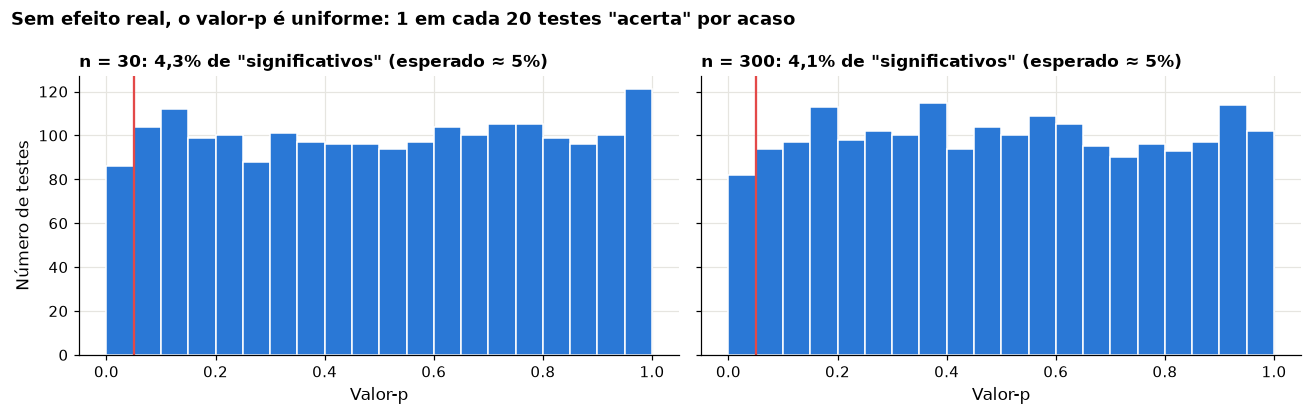

In [52]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.8), sharey=True)
for ax, n in zip(axes, (30, 300)):
    a, b = rng.choice(mt, size=(2000, n)), rng.choice(mt, size=(2000, n))
    p = stats.ttest_ind(a, b, axis=1, equal_var=False).pvalue
    ax.hist(p, bins=20, range=(0, 1), color=AZUL, edgecolor='white')
    ax.axvline(0.05, color=VERMELHO, lw=1.5)
    ax.set_title(f'n = {n}: {br(100 * (p < 0.05).mean())}% de "significativos" (esperado ≈ 5%)', fontsize=11)
    print(f'n = {n}: {br(100 * (p < 0.05).mean())}% dos 2.000 testes com p < 0,05')
    ax.set_xlabel('Valor-p')
axes[0].set_ylabel('Número de testes')
fig.suptitle('Sem efeito real, o valor-p é uniforme: 1 em cada 20 testes "acerta" por acaso', x=0.01, ha='left', fontweight='bold')
plt.tight_layout()
plt.show()

## 4.3 Ex. 1 — Linguagens: escolas federais × privadas (t de Welch)

Três perguntas guiam o exemplo: **quantos alunos sortear, e por quê?** **O que muda se fossem 100 ou 100.000?** **A diferença é grande?** O percurso é: (a) olhar a "verdade" da população; (b) planejar n pelo menor efeito relevante; (c) testar uma amostra; (d) ver o que acontece com o valor-p e com o efeito quando n muda.

In [53]:
# (a) A "verdade" no laboratório: todos os concluintes de 2023 que informaram escola federal ou privada
lc_fed = base.loc[base.TP_DEPENDENCIA_ADM_ESC == 1, 'NU_NOTA_LC'].to_numpy()
lc_priv = base.loc[base.TP_DEPENDENCIA_ADM_ESC == 4, 'NU_NOTA_LC'].to_numpy()
D_VERDADEIRO = d_cohen(lc_fed, lc_priv)
print(f'Federais: N = {br(len(lc_fed), 0)}, média {br(lc_fed.mean())} (dp {br(lc_fed.std(ddof=1))})')
print(f'Privadas: N = {br(len(lc_priv), 0)}, média {br(lc_priv.mean())} (dp {br(lc_priv.std(ddof=1))})')
print(f'Diferença verdadeira = {br(lc_fed.mean() - lc_priv.mean())} pontos | d verdadeiro = {br(D_VERDADEIRO, 3)} ({magnitude(D_VERDADEIRO)})')
print(f'Razão de variâncias = {br(max(lc_fed.var(), lc_priv.var()) / min(lc_fed.var(), lc_priv.var()), 2)} (Welch não exige igualdade)')

Federais: N = 43.273, média 552,4 (dp 64,5)
Privadas: N = 212.640, média 562,0 (dp 64,6)
Diferença verdadeira = -9,6 pontos | d verdadeiro = -0,149 (desprezível)
Razão de variâncias = 1,00 (Welch não exige igualdade)


d = 0,2 corresponde a ≈ 12,9 pontos de LC
n por grupo para poder de 80% (α = 0,05, bilateral): 394
  para d = 0.1: n = 1571 por grupo
  para d = 0.5: n = 64 por grupo
  para d = 0.8: n = 26 por grupo


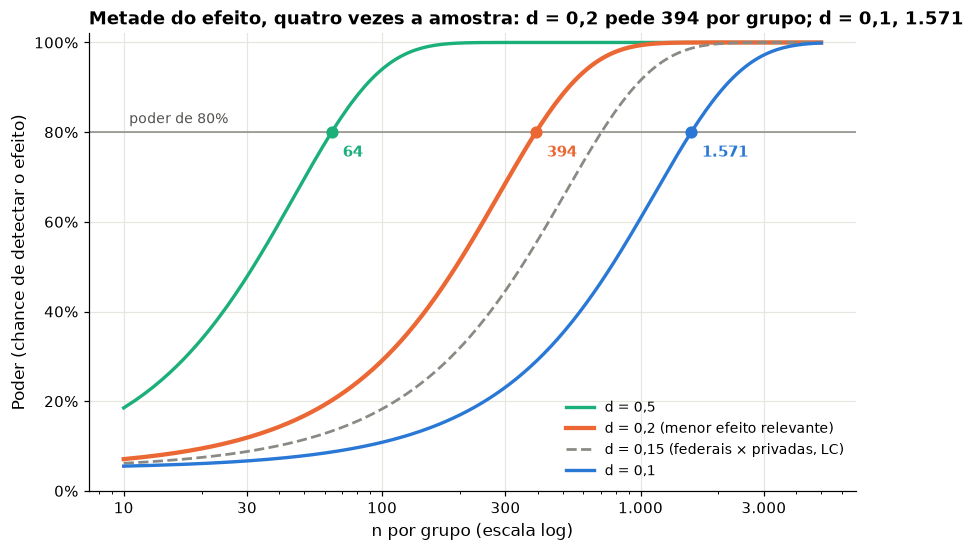

In [54]:
# (b) Planejamento: quantos alunos por grupo para detectar o MENOR efeito relevante (d = 0,2)?
analise_poder = TTestIndPower()
n_planejado = int(np.ceil(analise_poder.solve_power(effect_size=0.2, alpha=0.05, power=0.80)))
dp_comb = np.sqrt((lc_fed.var(ddof=1) + lc_priv.var(ddof=1)) / 2)
print(f'd = 0,2 corresponde a ≈ {br(0.2 * dp_comb)} pontos de LC')
print(f'n por grupo para poder de 80% (α = 0,05, bilateral): {n_planejado}')
for d_alvo in (0.1, 0.5, 0.8):
    print(f'  para d = {d_alvo}: n = {int(np.ceil(analise_poder.solve_power(effect_size=d_alvo, alpha=0.05, power=0.80)))} por grupo')

# Curvas de poder: chance de detectar cada tamanho de efeito, conforme o n por grupo (α = 0,05, bilateral)
ns_poder = np.unique(np.round(np.logspace(1, np.log10(5000), 200)).astype(int))
d_real = abs(D_VERDADEIRO)
fig, ax = plt.subplots(figsize=(9, 5.4))
for d_alvo, cor, lw, ls, rotulo in ((0.5, VERDE, 2.2, '-', 'd = 0,5'), (0.2, LARANJA, 2.8, '-', 'd = 0,2 (menor efeito relevante)'),
                                    (d_real, CINZA, 1.8, '--', f'd = {br(d_real, 2)} (federais × privadas, LC)'), (0.1, AZUL, 2.2, '-', 'd = 0,1')):
    poder_n = analise_poder.power(effect_size=d_alvo, nobs1=ns_poder, alpha=0.05)
    # O statsmodels devolve NaN para alguns n em que o poder já é praticamente 100%; confere-se e usa-se 1
    nan = np.isnan(poder_n)
    assert all(np.nanmax(poder_n[:i]) > 0.9999 for i in np.flatnonzero(nan)), 'NaN fora da região de poder ≈ 100%'
    poder_n = np.where(nan, 1.0, poder_n)
    ax.plot(ns_poder, poder_n, color=cor, lw=lw, ls=ls, label=rotulo)
ax.axhline(0.8, color=CINZA, lw=1)
ax.text(10.5, 0.82, 'poder de 80%', fontsize=9, color='#52514e')
n_alvos = {d_alvo: int(np.ceil(analise_poder.solve_power(effect_size=d_alvo, alpha=0.05, power=0.80))) for d_alvo in (0.5, 0.2, 0.1)}
for d_alvo, cor in ((0.5, VERDE), (0.2, LARANJA), (0.1, AZUL)):
    n_alvo = n_alvos[d_alvo]
    ax.plot([n_alvo], [0.8], 'o', color=cor, ms=7, zorder=4)
    ax.annotate(br(n_alvo, 0), (n_alvo, 0.8), xytext=(7, -16), textcoords='offset points', ha='left',
                fontsize=10, color=cor, fontweight='bold')
ax.set_xscale('log')
ax.set_xticks([10, 30, 100, 300, 1000, 3000], ['10', '30', '100', '300', '1.000', '3.000'])
ax.set_ylim(0, 1.02)
ax.set_yticks([0, 0.2, 0.4, 0.6, 0.8, 1.0], ['0%', '20%', '40%', '60%', '80%', '100%'])
ax.set_xlabel('n por grupo (escala log)')
ax.set_ylabel('Poder (chance de detectar o efeito)')
ax.set_title(f'Metade do efeito, quatro vezes a amostra: d = 0,2 pede {br(n_alvos[0.2], 0)} por grupo; d = 0,1, {br(n_alvos[0.1], 0)}')
ax.legend(loc='lower right', fontsize=9)
salvar(fig, 'm5_poder_curvas')
plt.show()

In [55]:
# (c) Uma amostra com o n planejado — o que o analista teria na vida real
a = rng.choice(lc_fed, n_planejado, replace=False)
b = rng.choice(lc_priv, n_planejado, replace=False)
ex1 = comparar(a, b, 'Federais', 'Privadas')
relatar(ex1)
MARGEM_LC = 0.2 * dp_comb          # menor efeito relevante (d = 0,2) convertido em pontos de LC
print(f"Leitura com a margem de relevância de ±{br(MARGEM_LC)} pontos: {classificar(ex1['IC95% inf'], ex1['IC95% sup'], MARGEM_LC)}")
ex1.to_frame('Ex. 1 (amostra)').T

Federais − Privadas: diferença de -5,7 pontos (IC95% [-14,3; 2,9]); d = -0,09 (efeito desprezível); p 0,196; n = 394 e 394.
Leitura com a margem de relevância de ±12,9 pontos: inconclusivo


,grupo A,grupo B,n A,n B,média A,média B,diferença (A−B),IC95% inf,IC95% sup,t,p,d de Cohen,magnitude
Ex. 1 (amostra),Federais,Privadas,394,394,553.249746,558.943655,-5.693909,-14.334037,2.94622,-1.293623,0.196176,-0.092167,desprezível


**Como ler:** o IC da diferença diz o tamanho plausível do efeito; o valor-p diz só se zero é plausível; o **d** põe a diferença na régua do desvio padrão. Compare o IC com a diferença verdadeira impressa em (a).

Na execução de referência (semente 2023), o teste **não** rejeita H₀ (p ≈ 0,20). Isso **não** prova que federais e privadas são iguais: o IC vai de cerca de −14 a +3 pontos e ainda inclui uma diferença no limite do relevante. A leitura honesta é **inconclusivo quanto à relevância**.

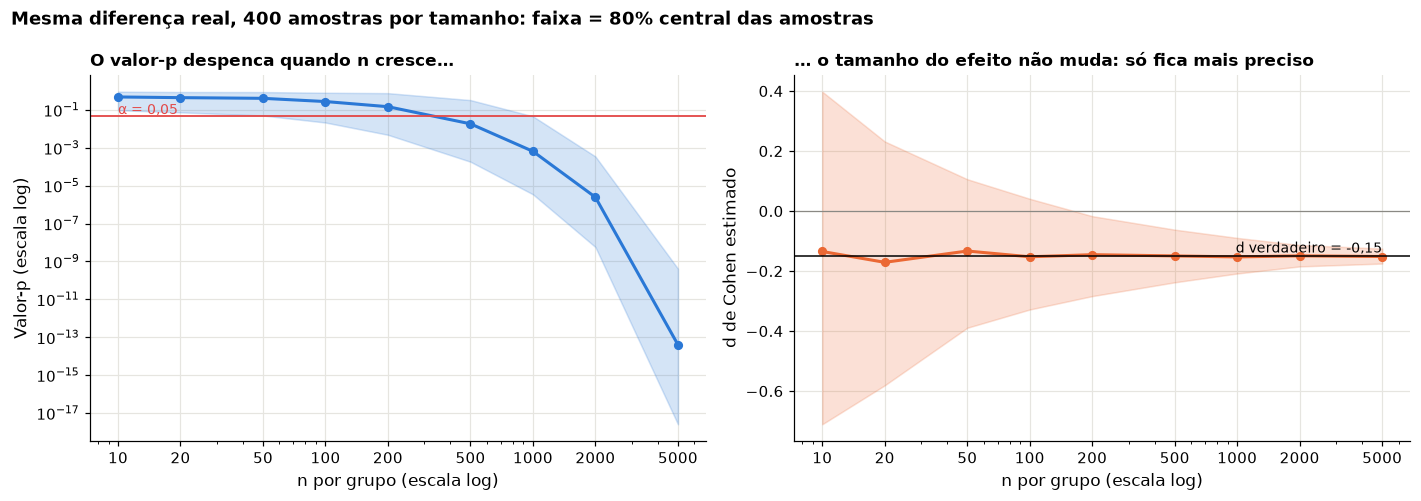

,n por grupo,poder empírico (%),poder teórico (%),p mediano
0,10,5.25,6.154,0.479
1,20,7.25,7.459,0.441
2,50,10.00,11.453,0.406
3,100,18.75,18.282,0.275
4,200,31.25,31.913,0.147
5,500,65.25,65.463,0.018
6,1000,91.00,91.560,0.001
7,2000,99.75,99.710,0.000
8,5000,100.00,100.000,0.000


In [56]:
# (d) O experimento central: mesma diferença real, n diferente
ns = np.array([10, 20, 50, 100, 200, 500, 1000, 2000, 5000])
reps = 400
p_res, d_res, poder = [], [], []
for n in ns:
    A, B = rng.choice(lc_fed, size=(reps, n)), rng.choice(lc_priv, size=(reps, n))
    p = stats.ttest_ind(A, B, axis=1, equal_var=False).pvalue
    sp = np.sqrt((A.var(axis=1, ddof=1) + B.var(axis=1, ddof=1)) / 2)
    d = (A.mean(axis=1) - B.mean(axis=1)) / sp
    p_res.append(p); d_res.append(d); poder.append(100 * (p < 0.05).mean())
p_res, d_res = np.array(p_res), np.array(d_res)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))
ax = axes[0]
ax.fill_between(ns, np.percentile(p_res, 10, axis=1), np.percentile(p_res, 90, axis=1), color=AZUL, alpha=0.2)
ax.plot(ns, np.median(p_res, axis=1), 'o-', color=AZUL, lw=2, ms=5)
ax.axhline(0.05, color=VERMELHO, lw=1.2)
ax.text(ns[0], 0.06, 'α = 0,05', color=VERMELHO, fontsize=9)
ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xticks(ns, [str(v) for v in ns])
ax.set_xlabel('n por grupo (escala log)'); ax.set_ylabel('Valor-p (escala log)')
ax.set_title('O valor-p despenca quando n cresce…', fontsize=11)

ax = axes[1]
ax.fill_between(ns, np.percentile(d_res, 10, axis=1), np.percentile(d_res, 90, axis=1), color=LARANJA, alpha=0.2)
ax.plot(ns, np.median(d_res, axis=1), 'o-', color=LARANJA, lw=2, ms=5)
ax.axhline(D_VERDADEIRO, color='black', lw=1)
ax.text(ns[-1], D_VERDADEIRO, f' d verdadeiro = {br(D_VERDADEIRO, 2)}', va='bottom', ha='right', fontsize=9)
ax.axhline(0, color=CINZA, lw=0.8)
ax.set_xscale('log')
ax.set_xticks(ns, [str(v) for v in ns])
ax.set_xlabel('n por grupo (escala log)'); ax.set_ylabel('d de Cohen estimado')
ax.set_title('… o tamanho do efeito não muda: só fica mais preciso', fontsize=11)
fig.suptitle('Mesma diferença real, 400 amostras por tamanho: faixa = 80% central das amostras', x=0.01, ha='left', fontweight='bold')
plt.tight_layout()
salvar(fig, 'm5_p_vs_d_por_n')
plt.show()

tabela_poder = pd.DataFrame({'n por grupo': ns, 'poder empírico (%)': poder,
                             'poder teórico (%)': [100 * analise_poder.power(effect_size=abs(D_VERDADEIRO), nobs1=n, alpha=0.05) for n in ns],
                             'p mediano': np.median(p_res, axis=1)})
tabela_poder.round(3)

**Três lições do gráfico:**
1. Com n pequeno, a mesma diferença real dá "não significativo" na maioria das amostras: **p > 0,05 não prova igualdade** (erro tipo II).
2. Com n grande, **tudo** fica significativo. Aqui a diferença verdadeira (d ≈ 0,15, cerca de 10 pontos) está **abaixo** do menor efeito relevante do pré-registro (d = 0,2). Mesmo assim, com n = 1.000 por grupo, cerca de 9 em cada 10 amostras dão "significativo". **Significativo e irrelevante.** Em bases com milhões de linhas, o valor-p perde utilidade e o que decide é o **tamanho do efeito**.
3. O d estimado **oscila em torno do mesmo valor** em qualquer n; o que muda é a precisão. O n deve ser escolhido pela **precisão desejada** ou pelo **menor efeito relevante** (seção b), e não por hábito.

> **Sobre o pingouin:** a coluna `power` de `pingouin.ttest` é o "poder alcançado", calculado com o **próprio d observado** (veja o código-fonte da função). Esse "poder observado" é só outra forma de reescrever o valor-p e não informa o poder do estudo (Hoenig e Heisey, 2001). O poder serve para **planejar** n antes da coleta, como em (b).

## 4.4 A régua do tamanho do efeito (população inteira)

Todas as comparações abaixo têm p < 0,001. O que as distingue é o tamanho.

,n A,n B,diferença (A−B),IC95% inf,IC95% sup,p,d de Cohen,magnitude
comparação,,,,,,,,
MT: privada × pública (TP_ESCOLA),219207,783634,121.800,121.237,122.362,0.0,1.086,grande
MT: renda > R$ 6.600 × renda ≤ R$ 1.320,377805,877472,168.476,168.036,168.915,0.0,1.576,grande
MT: homens × mulheres,983373,1585817,46.543,46.228,46.858,0.0,0.379,pequeno
Redação: mulheres × homens,1585817,983373,36.395,35.960,36.831,0.0,0.209,pequeno
MT: brancos × pretos,1119070,301740,77.606,77.155,78.057,0.0,0.629,médio
MT: brancos × pardos,1119070,1062833,62.954,62.631,63.276,0.0,0.517,médio
LC: privada × federal,212640,43273,9.643,8.976,10.310,0.0,0.149,desprezível
"CH × LC (pareado, d_z)",2569190,2569190,6.570,6.502,6.637,0.0,0.119,desprezível


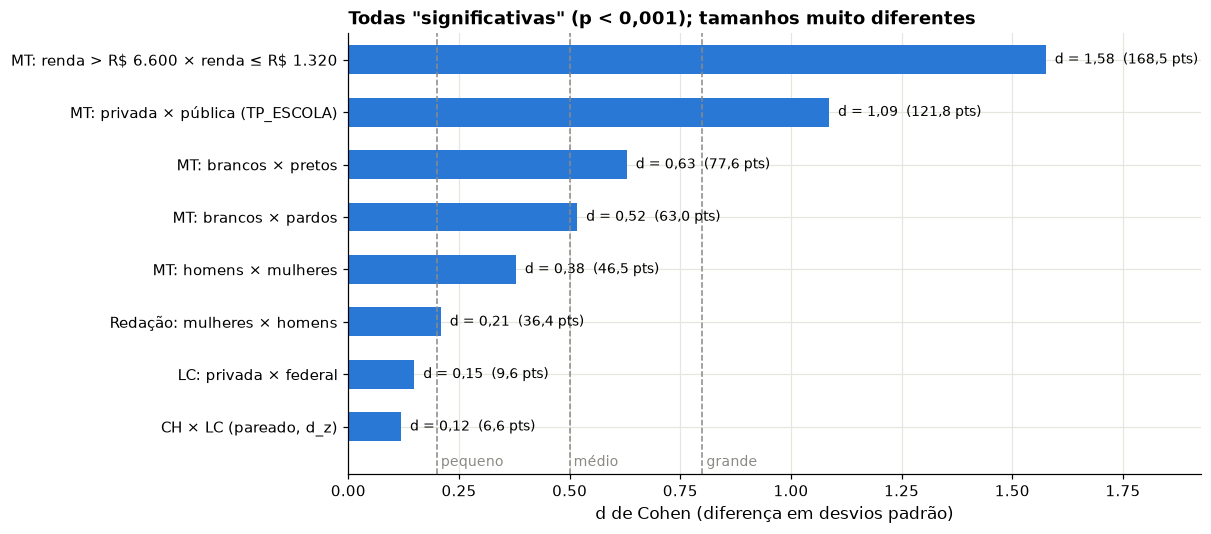

In [57]:
pub = base.loc[base.TP_ESCOLA == 2, 'NU_NOTA_MT']; priv = base.loc[base.TP_ESCOLA == 3, 'NU_NOTA_MT']
masc = base.loc[base.TP_SEXO == 'M', 'NU_NOTA_MT']; fem = base.loc[base.TP_SEXO == 'F', 'NU_NOTA_MT']
mt_branca, mt_preta, mt_parda = (base.loc[base.TP_COR_RACA == c, 'NU_NOTA_MT'] for c in (1, 2, 3))
red_fem, red_masc = (base.loc[base.TP_SEXO == s, 'NU_NOTA_REDACAO'] for s in ('F', 'M'))
alta = base.loc[base.RENDA_4 == '4) acima de R$ 6.600', 'NU_NOTA_MT']; baixa = base.loc[base.RENDA_4 == '1) até R$ 1.320', 'NU_NOTA_MT']
regua = pd.DataFrame([
    comparar(priv, pub, 'MT: privada', 'pública (TP_ESCOLA)'),
    comparar(alta, baixa, 'MT: renda > R$ 6.600', 'renda ≤ R$ 1.320'),
    comparar(masc, fem, 'MT: homens', 'mulheres'),
    comparar(red_fem, red_masc, 'Redação: mulheres', 'homens'),
    comparar(mt_branca, mt_preta, 'MT: brancos', 'pretos'),
    comparar(mt_branca, mt_parda, 'MT: brancos', 'pardos'),
    comparar(lc_priv, lc_fed, 'LC: privada', 'federal'),
])
dif_par = base.NU_NOTA_CH - base.NU_NOTA_LC          # pareado: o mesmo participante nas duas provas
t_par = stats.ttest_rel(base.NU_NOTA_CH, base.NU_NOTA_LC)
regua.loc[len(regua)] = {'grupo A': 'CH', 'grupo B': 'LC (pareado, d_z)', 'n A': len(dif_par), 'n B': len(dif_par),
                         'média A': base.NU_NOTA_CH.mean(), 'média B': base.NU_NOTA_LC.mean(),
                         'diferença (A−B)': dif_par.mean(), 'IC95% inf': t_par.confidence_interval().low,
                         'IC95% sup': t_par.confidence_interval().high, 't': t_par.statistic, 'p': t_par.pvalue,
                         'd de Cohen': dif_par.mean() / dif_par.std(ddof=1), 'magnitude': magnitude(dif_par.mean() / dif_par.std(ddof=1))}
regua['comparação'] = regua['grupo A'] + ' × ' + regua['grupo B']
display(regua.set_index('comparação')[['n A', 'n B', 'diferença (A−B)', 'IC95% inf', 'IC95% sup', 'p', 'd de Cohen', 'magnitude']].round(3))

ordem = regua.sort_values('d de Cohen')
fig, ax = plt.subplots(figsize=(10, 5.2))
ax.barh(range(len(ordem)), ordem['d de Cohen'], color=AZUL, height=0.55)
ax.set_yticks(range(len(ordem)), [c.replace('$', r'\$') for c in ordem['comparação']])   # "$" em rótulo vira fórmula
for v, lab in ((0.2, 'pequeno'), (0.5, 'médio'), (0.8, 'grande')):
    ax.axvline(v, color=CINZA, lw=1, ls='--')
    ax.text(v, -0.75, f' {lab}', color=CINZA, fontsize=9)
ax.set_ylim(-0.9, len(ordem) - 0.5)
for i, (d, dif) in enumerate(zip(ordem['d de Cohen'], ordem['diferença (A−B)'])):
    ax.text(d + 0.02, i, f'd = {br(d, 2)}  ({br(dif)} pts)', va='center', fontsize=9)
ax.set_xlim(0, max(1.3, ordem['d de Cohen'].max() + 0.35))
ax.set_xlabel('d de Cohen (diferença em desvios padrão)')
ax.set_title('Todas "significativas" (p < 0,001); tamanhos muito diferentes')
salvar(fig, 'm5_regua_efeito')
plt.show()

*Cuidados de leitura:* todas são comparações **observacionais**. A diferença entre escolas mistura renda, capital cultural e seleção de alunos; não é "o efeito da escola". As provas de CH e LC têm itens e escalas próprias, então a comparação pareada entre áreas tem sentido limitado. As diferenças por cor/raça misturam renda, escola e território (a seção 5.4 mostra quanto resta com essas variáveis no modelo); a diferença entre sexos muda de sinal conforme a prova (1.12). As convenções de Cohen são referência: a relevância de verdade se decide pela **pergunta de gestão**.

## 4.5 Ex. 2 — ANOVA: média geral em seis UFs

**Pergunta:** a média geral do ENEM (média das cinco notas) difere entre SP, MG, BA, RJ, RS e DF (UF do local de prova)?

**Menor efeito relevante: d = 0,2, o mesmo critério do Ex. 1.** Uma diferença menor que 0,2 desvio padrão entre duas UFs não mudaria nenhuma decisão. Para converter em pontos, usa-se o desvio padrão **dentro** das UFs (a variação entre participantes da mesma UF).

**Tamanho da amostra pelo poder.** Depois da ANOVA, o Tukey compara as UFs **duas a duas**: são 15 pares. Com 15 comparações, a chance de algum falso positivo cresce (seção 4.7). Por isso o planejamento usa, em cada par, α = 0,05 ÷ 15 = 0,0033 (correção de Bonferroni, um pouco mais exigente que o Tukey) e pede poder de 80% para detectar d = 0,2. O n sai por UF, e sorteia-se o **mesmo n em cada UF**, para que nenhuma fique com poucos casos.

**Leitura do Tukey:** um par com p ajustado ≥ 0,05 **não** é "equivalente". Para afirmar equivalência, o IC da diferença tem de caber inteiro dentro da margem de relevância (seção 4.3).

In [58]:
UFS = ['SP', 'MG', 'BA', 'RJ', 'RS', 'DF']
pop_uf = base.loc[base.SG_UF_PROVA.isin(UFS), ['SG_UF_PROVA', 'MEDIA_GERAL']]

# Desvio padrão dentro das UFs (raiz do quadrado médio residual da ANOVA), na população
g_uf = pop_uf.groupby('SG_UF_PROVA').MEDIA_GERAL.agg(['count', 'var'])
dp_dentro = np.sqrt(((g_uf['count'] - 1) * g_uf['var']).sum() / (g_uf['count'].sum() - len(g_uf)))
D_MIN = 0.2                          # menor efeito relevante (pré-registro), como no Ex. 1
MARGEM = D_MIN * dp_dentro           # o mesmo critério em pontos de média geral
n_pares = len(UFS) * (len(UFS) - 1) // 2
alfa_par = 0.05 / n_pares            # Bonferroni: 15 comparações

def n_por_uf(d, alfa=alfa_par):
    return int(np.ceil(analise_poder.solve_power(effect_size=d, alpha=alfa, power=0.80)))

n_uf = n_por_uf(D_MIN)
print(f'Desvio padrão dentro das UFs = {br(dp_dentro)} pontos → d = 0,2 equivale a ±{br(MARGEM)} pontos (margem de relevância)')
print(f'{n_pares} pares de UFs → α por par = 0,05 / {n_pares} = {alfa_par:.4f}')
print(f'n por UF para poder de 80%: {n_uf} (total de {br(len(UFS) * n_uf, 0)} participantes)')
print(f'Sem a correção para 15 pares (α = 0,05), seriam {n_por_uf(D_MIN, 0.05)} por UF, o mesmo n do Ex. 1')
print('Sensibilidade ao d escolhido (n por UF):', {d: br(n_por_uf(d), 0) for d in (0.1, 0.2, 0.3, 0.5)})

Desvio padrão dentro das UFs = 84,7 pontos → d = 0,2 equivale a ±16,9 pontos (margem de relevância)
15 pares de UFs → α por par = 0,05 / 15 = 0.0033
n por UF para poder de 80%: 716 (total de 4.296 participantes)
Sem a correção para 15 pares (α = 0,05), seriam 394 por UF, o mesmo n do Ex. 1
Sensibilidade ao d escolhido (n por UF): {0.1: '2.856', 0.2: '716', 0.3: '320', 0.5: '117'}


In [59]:
# A amostra planejada: n_uf participantes sorteados em cada UF (amostra estratificada por UF)
amostra_uf = pop_uf.groupby('SG_UF_PROVA', group_keys=False).sample(n_uf, random_state=SEMENTE)
display(amostra_uf.groupby('SG_UF_PROVA').MEDIA_GERAL.agg(n='count', média='mean', dp='std')
        .sort_values('média', ascending=False).round(1))

# Tabela ANOVA completa (somas de quadrados, graus de liberdade, variâncias estimadas, razão F)
y_a, g_a = amostra_uf.MEDIA_GERAL, amostra_uf.SG_UF_PROVA
k, N = g_a.nunique(), len(y_a)
grp = y_a.groupby(g_a).agg(['count', 'mean'])
sq_entre = (grp['count'] * (grp['mean'] - y_a.mean()) ** 2).sum()
sq_total = ((y_a - y_a.mean()) ** 2).sum()
sq_dentro = sq_total - sq_entre
F = (sq_entre / (k - 1)) / (sq_dentro / (N - k))
pF = stats.f.sf(F, k - 1, N - k)
tabela_anova = pd.DataFrame({'soma de quadrados': [sq_entre, sq_dentro, sq_total], 'g.l.': [k - 1, N - k, N - 1],
                             'variância estimada': [sq_entre / (k - 1), sq_dentro / (N - k), np.nan],
                             'razão F': [F, np.nan, np.nan]}, index=['entre UFs', 'dentro das UFs', 'total'])
display(tabela_anova.round(2))
print(f'p {fmt_p(pF)} | F crítico (5%) = {br(stats.f.ppf(0.95, k - 1, N - k), 2)} | '
      f'conferência com scipy: F = {br(stats.f_oneway(*[g.to_numpy() for _, g in y_a.groupby(g_a)]).statistic, 2)}')
print(f'η² = {br(sq_entre / sq_total, 3)} na amostra | η² na população das 6 UFs = {br(eta2(pop_uf.MEDIA_GERAL, pop_uf.SG_UF_PROVA), 3)}')

,n,média,dp
SG_UF_PROVA,,,
MG,716,577.1,87.1
SP,716,572.6,85.4
RS,716,567.5,82.5
DF,716,567.1,95.4
RJ,716,563.1,83.9
BA,716,535.0,88.3


,soma de quadrados,g.l.,variância estimada,razão F
entre UFs,794044.13,5,158808.83,20.89
dentro das UFs,32611200.20,4290,7601.68,NaN
total,33405244.33,4295,NaN,NaN


p < 0,001 | F crítico (5%) = 2,22 | conferência com scipy: F = 20,89


η² = 0,024 na amostra | η² na população das 6 UFs = 0,027


In [60]:
ROTULO = 'leitura (IC × margem)'

def tukey_tabela(df_):
    tk = pairwise_tukeyhsd(df_.MEDIA_GERAL, df_.SG_UF_PROVA, alpha=0.05)
    t = pd.DataFrame(tk.summary().data[1:], columns=tk.summary().data[0])
    t['par'] = t.group1 + ' × ' + t.group2
    t[ROTULO] = [classificar(lo, hi, MARGEM) for lo, hi in zip(t.lower, t.upper)]
    return t

tk_amostra = tukey_tabela(amostra_uf)
print(f'Margem de relevância: ±{br(MARGEM)} pontos | meia-largura dos IC de Tukey: {br(((tk_amostra.upper - tk_amostra.lower) / 2).mean())} pontos')
print(tk_amostra[ROTULO].value_counts().to_string())
tk_amostra[['par', 'meandiff', 'lower', 'upper', 'p-adj', ROTULO]].round(2)

Margem de relevância: ±16,9 pontos | meia-largura dos IC de Tukey: 13,1 pontos
leitura (IC × margem)
inconclusivo                     8
diferença relevante              4
diferente; relevância incerta    2
equivalente na prática           1


,par,meandiff,lower,upper,p-adj,leitura (IC × margem)
0,BA × DF,32.08,18.94,45.21,0.00,diferença relevante
1,BA × MG,42.13,28.99,55.27,0.00,diferença relevante
2,BA × RJ,28.13,14.99,41.26,0.00,diferente; relevância incerta
3,BA × RS,32.54,19.41,45.68,0.00,diferença relevante
4,BA × SP,37.56,24.42,50.70,0.00,diferença relevante
5,DF × MG,10.05,-3.09,23.19,0.25,inconclusivo
6,DF × RJ,-3.95,-17.09,9.19,0.96,inconclusivo
7,DF × RS,0.47,-12.67,13.60,1.00,equivalente na prática
8,DF × SP,5.48,-7.65,18.62,0.84,inconclusivo
9,MG × RJ,-14.00,-27.14,-0.86,0.03,diferente; relevância incerta


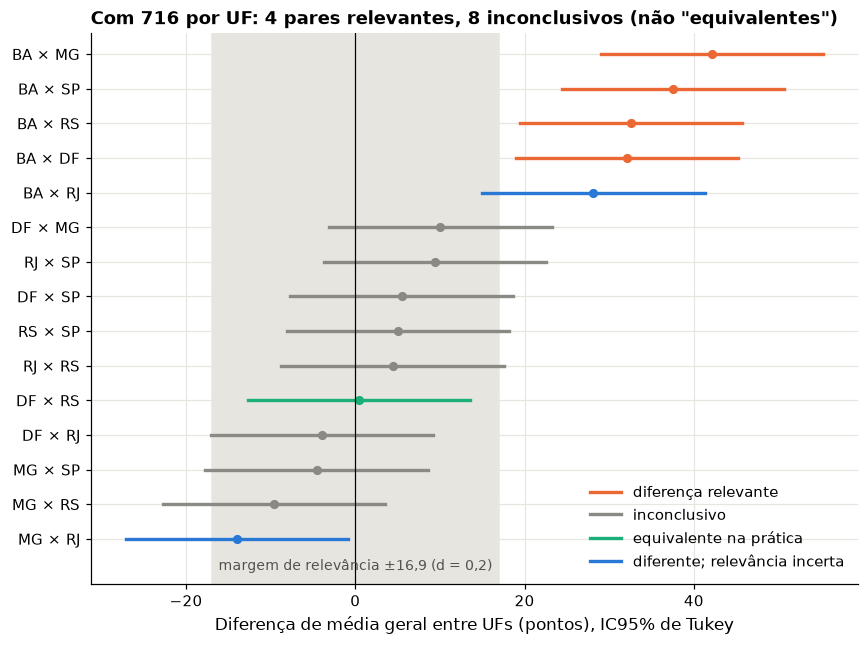

In [61]:
fig, ax = plt.subplots(figsize=(9, 6.5))
t = tk_amostra.sort_values('meandiff').reset_index(drop=True)
ax.axvspan(-MARGEM, MARGEM, color='#e6e5e0', zorder=0)
ax.text(0, -0.9, f'margem de relevância ±{br(MARGEM)} (d = 0,2)', ha='center', fontsize=9, color='#52514e')
ax.set_ylim(-1.3, len(t) - 0.4)
cores = {'diferença relevante': LARANJA, 'inconclusivo': CINZA, 'equivalente na prática': VERDE,
         'diferente, mas irrelevante': VERDE, 'diferente; relevância incerta': AZUL}
for i, r in t.iterrows():
    c = cores[r[ROTULO]]
    ax.plot([r.lower, r.upper], [i, i], color=c, lw=2.2)
    ax.plot(r.meandiff, i, 'o', color=c, ms=5)
ax.axvline(0, color='black', lw=0.8)
ax.set_yticks(range(len(t)), t.par)
ax.set_xlabel('Diferença de média geral entre UFs (pontos), IC95% de Tukey')
presentes = [l for l in cores if l in set(t[ROTULO])]
handles = [plt.Line2D([], [], color=cores[l], lw=2.2, label=l) for l in presentes]
ax.legend(handles=handles, loc='lower right')
cont = t[ROTULO].value_counts()
ax.set_title(f'Com {n_uf} por UF: {cont.get("diferença relevante", 0)} pares relevantes, '
             f'{cont.get("inconclusivo", 0)} inconclusivos (não "equivalentes")')
salvar(fig, 'm5_tukey_margem')
plt.show()

In [62]:
# A mesma análise com TODOS os participantes das seis UFs: os IC ficam estreitos e a margem decide
tk_pop = tukey_tabela(pop_uf)
print(f'n = {br(len(pop_uf), 0)}')
print(tk_pop[ROTULO].value_counts().to_string())
tk_pop[['par', 'meandiff', 'lower', 'upper', 'p-adj', ROTULO]].round(2)

n = 1.187.611
leitura (IC × margem)
diferente, mas irrelevante    9
diferença relevante           5
equivalente na prática        1


,par,meandiff,lower,upper,p-adj,leitura (IC × margem)
0,BA × DF,33.99,32.78,35.20,0.0,diferença relevante
1,BA × MG,39.27,38.56,39.99,0.0,diferença relevante
2,BA × RJ,31.69,30.91,32.46,0.0,diferença relevante
3,BA × RS,31.77,30.87,32.68,0.0,diferença relevante
4,BA × SP,38.05,37.40,38.69,0.0,diferença relevante
5,DF × MG,5.28,4.08,6.48,0.0,"diferente, mas irrelevante"
6,DF × RJ,-2.30,-3.54,-1.07,0.0,"diferente, mas irrelevante"
7,DF × RS,-2.22,-3.54,-0.90,0.0,"diferente, mas irrelevante"
8,DF × SP,4.05,2.90,5.21,0.0,"diferente, mas irrelevante"
9,MG × RJ,-7.59,-8.34,-6.83,0.0,"diferente, mas irrelevante"


**Leitura (Ex. 2):** 
1. **Na amostra planejada** (716 por UF), a ANOVA rejeita H₀ (F = 20,89; p < 0,001), mas a UF está associada a só 2,4% da variação da média geral (η²; 2,7% na população): quase toda a variação está **dentro** de cada UF.
2. **No Tukey**, com margem de ±16,9 pontos (d = 0,2) e IC de cerca de ±13 pontos: 4 pares são diferenças relevantes (BA × DF, MG, RS e SP); 2 têm relevância incerta (BA × RJ e MG × RJ: excluem o zero, mas cruzam a margem); DF × RS é equivalente na prática (o IC cabe inteiro na margem); 8 são **inconclusivos**. O n foi planejado para *detectar* uma diferença de 0,2 desvio padrão, não para *provar equivalência*: para isso o IC teria de ser bem mais estreito que a margem.
3. **Na população**, quase todos os pares são "significativos", mas 9 são **diferentes e irrelevantes** (diferenças de 1 a 8 pontos, dentro da margem); só os 5 pares com a BA são relevantes, e RJ × RS é equivalente na prática.

In [63]:
# Contraste: a UF explica pouco da variação da média geral; a renda explica muito mais
print(f'η² da UF (6 UFs, população)          = {br(eta2(pop_uf.MEDIA_GERAL, pop_uf.SG_UF_PROVA), 3)}')
print(f'η² da renda em 4 faixas (Brasil)      = {br(eta2(base.MEDIA_GERAL, base.RENDA_4), 3)}')
print(f'η² da renda em 4 faixas — MT (Brasil) = {br(eta2(base.NU_NOTA_MT, base.RENDA_4), 3)}')
print(f'η² da cor/raça — MT (Brasil)           = {br(eta2(base.NU_NOTA_MT, base.TP_COR_RACA), 3)}')
print(f'η² do sexo — MT (Brasil)               = {br(eta2(base.NU_NOTA_MT, base.TP_SEXO), 3)}')
anova_renda = base.groupby('RENDA_4').NU_NOTA_MT.agg(n='count', média='mean', dp='std')
grupos_r = [g.to_numpy() for _, g in base.groupby('RENDA_4').NU_NOTA_MT]
print(f'ANOVA MT × renda: F = {br(stats.f_oneway(*grupos_r).statistic, 0)}; razão máx/mín de variâncias = {br(anova_renda.dp.max() ** 2 / anova_renda.dp.min() ** 2, 2)}')
anova_renda.round(1)

η² da UF (6 UFs, população)          = 0,027


η² da renda em 4 faixas (Brasil)      = 0,215


η² da renda em 4 faixas — MT (Brasil) = 0,217
η² da cor/raça — MT (Brasil)           = 0,070


η² do sexo — MT (Brasil)               = 0,033


ANOVA MT × renda: F = 237.427; razão máx/mín de variâncias = 1,47


,n,média,dp
RENDA_4,,,
1) até R$ 1.320,877472,479.6,100.1
2) R$ 1.320–3.300,885423,531.7,111.6
3) R$ 3.300–6.600,428490,589.0,118.4
4) acima de R$ 6.600,377805,648.1,121.3


## 4.6 Ex. 3 — Qui-quadrado: escolaridade do pai × renda familiar

**Pergunta:** a escolaridade do pai (Q001) e a renda familiar (Q006) estão associadas? Todos os inscritos, sem quem respondeu "Não sei" sobre o pai; escolaridade em 5 níveis e renda em 4 faixas (tabela 5 × 4). Primeiro, a tabela e o teste na população; depois, o planejamento da amostra e o teste na amostra.

In [64]:
# Todos os inscritos; "Não sei" (H) fica de fora
INSTR_5 = {**dict.fromkeys('ABC', '1) Fund. incompleto'), 'D': '2) Fund. completo', 'E': '3) Médio completo',
           'F': '4) Superior completo', 'G': '5) Pós-graduação'}
qq = insc.loc[insc.Q001 != 'H', ['Q001', 'Q006']].copy()
qq['instr_pai'] = qq.Q001.map(INSTR_5)
qq['renda'] = qq.Q006.map(RENDA_4)
tab = pd.crosstab(qq.instr_pai, qq.renda)
chi2, p, gl, esperado = stats.chi2_contingency(tab)
V = stats.contingency.association(tab.to_numpy(), method='cramer')
print(f'χ² = {br(chi2, 0)}; gl = {gl}; p {fmt_p(p)}; menor frequência esperada = {br(esperado.min(), 0)}; V de Cramér = {br(V, 3)}')
display(tab)

χ² = 1.199.953; gl = 12; p < 0,001; menor frequência esperada = 32.708; V de Cramér = 0,337


renda,1) até R$ 1.320,2) R$ 1.320–3.300,3) R$ 3.300–6.600,4) acima de R$ 6.600
instr_pai,,,,
1) Fund. incompleto,765306,486049,105437,31308
2) Fund. completo,172624,182948,59716,22851
3) Médio completo,317873,452303,226172,117816
4) Superior completo,32670,84021,91329,125961
5) Pós-graduação,13605,35791,53594,153055


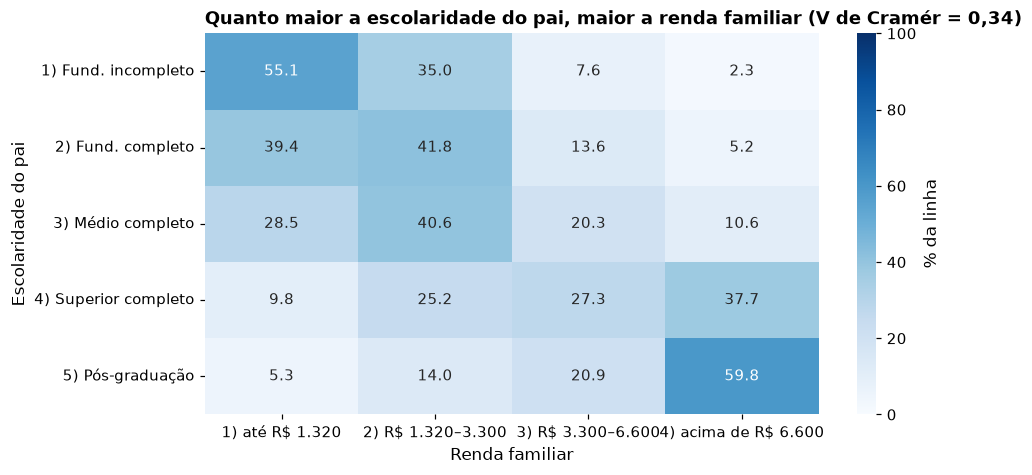

In [65]:
# ONDE está a associação: percentuais por linha (para cada escolaridade do pai, a distribuição da renda)
pct = pd.crosstab(qq.instr_pai, qq.renda, normalize='index') * 100
fig, ax = plt.subplots(figsize=(9, 4.5))
sns.heatmap(pct, annot=True, fmt='.1f', cmap='Blues', vmin=0, vmax=100, cbar_kws={'label': '% da linha'}, ax=ax)
ax.set_xlabel('Renda familiar'); ax.set_ylabel('Escolaridade do pai')
ax.tick_params(axis='x', rotation=0)
ax.set_title(f'Quanto maior a escolaridade do pai, maior a renda familiar (V de Cramér = {br(V, 2)})')
salvar(fig, 'm5_quiquadrado_pai_renda')
plt.show()


### Planejamento da amostra do Ex. 3

**Menor efeito relevante: V de Cramér = 0,1.** O V vai de 0 (nenhuma associação) a 1 (associação total); abaixo de 0,1 a associação seria fraca demais para orientar decisão.

**Do V ao w (só para o cálculo).** A função de poder do qui-quadrado (`GofChisquarePower`, do statsmodels) não recebe o V: recebe o **w de Cohen**, outra medida de força da associação, ligada ao V por **w = V × √(min(linhas, colunas) − 1)**. Na tabela 5 × 4, min(5, 4) − 1 = 3, então w = 0,1 × √3 ≈ 0,17. Os graus de liberdade são (5 − 1) × (4 − 1) = 12 (a função os recebe como `n_bins` = gl + 1).

**Duas condições para o n:**
1. **Poder:** n para detectar V = 0,1 com 80% de poder e α = 0,05.
2. **Frequências esperadas ≥ 5 em todas as caselas** (Barbetta, cap. 12, p. 250–251). A menor esperada é n × (proporção da linha) × (proporção da coluna) da casela mais rara. Aqui as proporções vêm da população; no trabalho real, de um estudo anterior ou de uma amostra piloto.

O n planejado é o **maior** dos dois.

In [66]:
V_MIN = 0.1                                  # menor efeito relevante (pré-registro)
LINHAS, COLUNAS = tab.shape                  # 5 níveis de escolaridade × 4 faixas de renda
GL_TAB = (LINHAS - 1) * (COLUNAS - 1)
W_MIN = V_MIN * np.sqrt(min(LINHAS, COLUNAS) - 1)

def n_qui2(v):
    w = v * np.sqrt(min(LINHAS, COLUNAS) - 1)
    return int(np.ceil(GofChisquarePower().solve_power(effect_size=w, n_bins=GL_TAB + 1, alpha=0.05, power=0.80)))

n_poder = n_qui2(V_MIN)
p_lin = tab.sum(axis=1) / tab.to_numpy().sum()
p_col = tab.sum(axis=0) / tab.to_numpy().sum()
p_casela_min = np.outer(p_lin, p_col).min()
n_esperadas = int(np.ceil(5 / p_casela_min))
n_chi = max(n_poder, n_esperadas)
print(f'V = {V_MIN} em tabela {LINHAS} × {COLUNAS} → w = {br(W_MIN, 3)}; gl = {GL_TAB}')
print(f'(1) Poder de 80%: n = {n_poder}')
print(f'(2) Esperadas ≥ 5: a casela mais rara tem proporção {br(100 * p_casela_min, 2)}% → n ≥ {n_esperadas}')
print(f'n planejado = {n_chi} | menor esperada prevista = {br(n_chi * p_casela_min, 1)}')
n_erro_w = int(np.ceil(GofChisquarePower().solve_power(effect_size=V_MIN, n_bins=GL_TAB + 1, alpha=0.05, power=0.80)))
print(f'Erro comum: usar V = {V_MIN} como se fosse o w daria n = {br(n_erro_w, 0)}, em vez de {n_poder}')
print('Sensibilidade (V → n pelo poder):', {v: br(n_qui2(v), 0) for v in (0.05, 0.1, 0.2, 0.3)})

V = 0.1 em tabela 5 × 4 → w = 0,173; gl = 12
(1) Poder de 80%: n = 578
(2) Esperadas ≥ 5: a casela mais rara tem proporção 0,93% → n ≥ 540
n planejado = 578 | menor esperada prevista = 5,4
Erro comum: usar V = 0.1 como se fosse o w daria n = 1.734, em vez de 578
Sensibilidade (V → n pelo poder): {0.05: '2.312', 0.1: '578', 0.2: '145', 0.3: '65'}


In [67]:
# A amostra planejada: o χ² cai muito; a força (V) quase não muda
sub = qq.sample(n_chi, random_state=SEMENTE)
tab_s = pd.crosstab(sub.instr_pai, sub.renda)
c2s, ps, gls, es = stats.chi2_contingency(tab_s)
V_s = stats.contingency.association(tab_s.to_numpy(), method='cramer')
print(f'Amostra n = {n_chi}: χ² = {br(c2s, 1)}; gl = {gls}; p {fmt_p(ps)}; V = {br(V_s, 3)}; '
      f'menor esperada = {br(es.min(), 1)}; caselas com esperada < 5: {(es < 5).sum()} de {es.size}')

# Se alguma esperada ficar abaixo de 5, o valor-p do χ² pode ser obtido por simulação (permutação),
# que não depende dessa condição: embaralha-se a renda mantendo os totais e recalcula-se o χ²
if (es < 5).any():
    rng_perm = np.random.default_rng(SEMENTE)      # gerador próprio: não altera os sorteios seguintes
    renda_s = sub.renda.to_numpy()
    c2_perm = np.array([stats.chi2_contingency(pd.crosstab(sub.instr_pai.to_numpy(), rng_perm.permutation(renda_s)))[0]
                        for _ in range(2000)])
    print(f'p por permutação (2.000 repetições) = {br((1 + (c2_perm >= c2s).sum()) / 2001, 4)}')

Amostra n = 578: χ² = 178,0; gl = 12; p < 0,001; V = 0,320; menor esperada = 4,8; caselas com esperada < 5: 2 de 20


p por permutação (2.000 repetições) = 0,0005


**Leitura (Ex. 3):** na população, χ² = 1.199.953 e V = 0,337: associação moderada, bem acima do mínimo relevante (0,1). O n planejado (578) é o maior entre o do poder (578) e o das esperadas (540). Na amostra, o χ² cai para 178,0, porque o χ² cresce com n; o V fica parecido (0,320): é o V que mede a força.

Duas das 20 caselas da amostra ficaram com esperada um pouco abaixo de 5 (a menor, 4,8): os totais da amostra variam em torno dos da população. **O planejamento não dispensa a conferência.** Quando a condição falha, o Barbetta indica o teste exato; no computador, o caminho prático é o valor-p por permutação (embaralhar a renda mantendo os totais, a mesma ideia do controle negativo do Ex. 1). Aqui ele dá 0,0005 e confirma a associação.

In [68]:
# Ligação com o Módulo 5: presença em MT × renda (todos os inscritos) — a origem do viés de seleção
tab_pres = pd.crosstab(insc.Q006.map(RENDA_4), insc.TP_PRESENCA_MT == 1).rename(columns={False: 'não presentes', True: 'presentes'})
c2p, pp, glp, ep_ = stats.chi2_contingency(tab_pres)
tab_pres['% presentes'] = 100 * tab_pres.presentes / tab_pres.sum(axis=1)
print(f'χ² = {br(c2p, 0)}; gl = {glp}; p {fmt_p(pp)}; V de Cramér = {br(stats.contingency.association(tab_pres[["não presentes", "presentes"]].to_numpy(), method="cramer"), 3)}')
tab_pres.round(1)

χ² = 95.031; gl = 3; p < 0,001; V de Cramér = 0,155


TP_PRESENCA_MT,não presentes,presentes,% presentes
Q006,,,
1) até R$ 1.320,573015,940309,62.1
2) R$ 1.320–3.300,458316,923986,66.8
3) R$ 3.300–6.600,130667,441283,77.2
4) acima de R$ 6.600,79530,386849,82.9


## 4.7 Comparações múltiplas: quem procura, acha

In [69]:
# 100 testes entre duas metades SORTEADAS de MT (H0 verdadeira em todos)
ps = []
for _ in range(100):
    idx = rng.choice(len(mt), 1000, replace=False)
    ps.append(stats.ttest_ind(mt[idx[:500]], mt[idx[500:]], equal_var=False).pvalue)
ps = np.array(ps)
print(f'p < 0,05 em {(ps < 0.05).sum()} de 100 testes | menor p = {ps.min():.4f}')
for metodo, nome in (('bonferroni', 'Bonferroni'), ('holm', 'Holm'), ('fdr_bh', 'FDR (Benjamini-Hochberg)')):
    print(f'  rejeições após correção de {nome}: {multipletests(ps, alpha=0.05, method=metodo)[0].sum()}')

p < 0,05 em 7 de 100 testes | menor p = 0.0066
  rejeições após correção de Bonferroni: 0
  rejeições após correção de Holm: 0
  rejeições após correção de FDR (Benjamini-Hochberg): 0


### IA — Prompts do Módulo 6

**Prompt 1 — Ex. 1: o teste t**

```text
Papel: Você é um estatístico revisando uma análise para gestores públicos.

Contexto: Amostra aleatória de 394 concluintes de escolas federais e 394 de privadas (ENEM 2023),
num DataFrame amostra com as colunas nota (NU_NOTA_LC) e grupo (“federal” ou “privada”). Dados
observacionais, sem sorteio de quem estuda onde.

Pergunta: A nota média de LC difere entre federais e privadas? H0: médias iguais; bilateral;
α = 0,05; menor efeito relevante: d = 0,2, que equivale a cerca de 12,9 pontos.

Tarefa: (1) Descreva cada grupo (n, média, DP). (2) Aplique o t de Welch (scipy.stats.ttest_ind com
equal_var=False). (3) Calcule a diferença, o IC95% da diferença e o d de Cohen. (4) Classifique o IC
contra a margem de ±12,9 pontos. (5) Faça um controle negativo: embaralhe o grupo 1.000 vezes e
conte quantos p < 0,05.

Restrições: Só código, sem resultados. Não use “poder observado”. Não escreva “prova”, “causa” nem
“efeito da escola”.

Formato: Suposições e como checá-las; código comentado; como ler cada saída, inclusive se p > 0,05.
```

**Verificação independente** (célula abaixo):
- Teste: t de Welch (não exige variâncias iguais)
- Diferença −5,7; IC95% [−14,3; 2,9]; p = 0,196; d = −0,09
- Leitura: inconclusivo (o IC cruza −12,9)
- Controle negativo: 4,6% de p < 0,05
- Conferir t à mão: diferença ÷ erro padrão

**Prompt 2 — Ex. 2: ANOVA e Tukey**

```text
Papel: Você é um estatístico revisando uma análise para gestores públicos.

Contexto: DataFrame base com a base de análise do ENEM 2023, tratada como população. Colunas:
SG_UF_PROVA (UF do local de prova) e MEDIA_GERAL (média das cinco notas). Vou sortear o mesmo número
de participantes em cada uma das UFs SP, MG, BA, RJ, RS e DF, com semente 2023.

Pergunta: A média geral difere entre as seis UFs? H0: as seis médias são iguais; α = 0,05; menor
efeito relevante: d = 0,2 entre duas UFs.

Tarefa: (1) Calcule o n por UF para d = 0,2, poder de 80% e α = 0,05/15 (TTestIndPower) e converta
d = 0,2 em pontos. (2) Sorteie esse n em cada UF; n, média e DP. (3) ANOVA (scipy.stats.f_oneway)
com a tabela completa: somas de quadrados, g.l., variâncias estimadas, razão F e valor-p. (4)
η² = soma de quadrados entre ÷ total. (5) Tukey (pairwise_tukeyhsd) com o IC95% de cada par,
classificado contra a margem. (6) Cheque as suposições.

Restrições: Não chame de “equivalentes” os pares com p ≥ 0,05. Não calcule de cabeça. Comente em
português.

Formato: Tabela ANOVA; tabela de pares com a leitura de cada um; três frases para a diretoria.
```

**Verificação independente** (segunda célula abaixo):
- d = 0,2 ≈ 16,9 pontos; n = 716 por UF (4.296)
- F = 20,89 com 5 e 4.290 g.l.; p < 0,001
- η² = 0,024 (população: 0,027)
- BA × DF, MG, RS, SP: relevante; BA × RJ e MG × RJ: incerta
- 8 pares inconclusivos, não “equivalentes”

**Prompt 3 — Ex. 3: o qui-quadrado**

```text
Papel: Você é um estatístico revisando uma análise para gestores públicos.

Contexto: DataFrame insc com todos os inscritos do ENEM 2023. Q001 = escolaridade do pai (A a G;
H = “Não sei”); Q006 = renda familiar em 17 faixas (A a Q).

Pergunta: A escolaridade do pai e a renda familiar estão associadas? H0: independência; α = 0,05;
menor efeito relevante: V de Cramér = 0,1.

Tarefa: (1) Exclua “Não sei”; agrupe Q001 em 5 níveis (A–C fund. incompleto; D fund.; E médio; F
superior; G pós) e Q006 em 4 faixas (A–B; C–E; F–H; I–Q). (2) Qui-quadrado
(scipy.stats.chi2_contingency): χ², g.l., valor-p e menor esperada; V de Cramér; % por linha num
mapa de calor. (3) Planeje a amostra: n para V = 0,1 com poder de 80% (GofChisquarePower,
w = V × √3, 12 g.l.) e n para esperadas ≥ 5; use o maior. (4) Repita o teste nessa amostra (semente
2023); se alguma esperada ficar < 5, dê também o p por permutação.

Restrições: Confira que todas as frequências esperadas são ≥ 5. Nada de linguagem causal. Só código.

Formato: Tabelas; mapa de calor; como ler χ², valor-p e V na população e na amostra.
```

**Verificação independente** (segunda célula abaixo):
- χ² = 1.199.953; g.l. = 12; menor esperado 32.708
- V = 0,337 (população) × 0,320 (n = 578)
- n = 578 pelo poder (w = 0,17); 540 pelas esperadas
- Pai fund. incompleto: 55,1% até R$ 1.320
- Amostra: χ² = 178,0; 2 esperadas < 5; p por permutação = 0,0005

**Outro prompt do bloco — redigir o resultado sem inflar a conclusão**
```text
Resultado: [colar a frase de `relatar()` da régua de efeitos: privada × pública em MT].
Delineamento observacional. Escreva um parágrafo para um relatório técnico
e três bullets para a diretoria. Regras: não use "prova", "causa" nem "efeito da escola";
mencione o tamanho do efeito e o IC; inclua uma limitação sobre a população analisada
(só concluintes de 2023 que informaram escola) e uma sobre fatores de confusão.
```

In [70]:
# Verificação do Prompt 1 (Ex. 1): o n que a IA calcular deve bater com este
print('n por grupo (d = 0,2; poder 80%; α = 0,05):', n_planejado)

# Controle negativo do Prompt 1 (item 5): rótulos embaralhados 1.000 vezes
amostra_ex1 = pd.DataFrame({'nota': np.r_[a, b], 'grupo': ['federal'] * len(a) + ['privada'] * len(b)})

def analisar(df_):
    return stats.ttest_ind(df_.loc[df_.grupo == 'federal', 'nota'], df_.loc[df_.grupo == 'privada', 'nota'], equal_var=False).pvalue

p_embaralhado = np.array([analisar(amostra_ex1.assign(grupo=rng.permutation(amostra_ex1.grupo.to_numpy())))
                          for _ in range(1000)])
print(f'Controle negativo: {br(100 * (p_embaralhado < 0.05).mean())}% de p < 0,05 com rótulos embaralhados (esperado ≈ 5%)')
print(f'p com os rótulos verdadeiros: {fmt_p(analisar(amostra_ex1))}')

# Frase para colar no "outro prompt do bloco" (redigir o resultado)
relatar(regua.iloc[0])

n por grupo (d = 0,2; poder 80%; α = 0,05): 394


Controle negativo: 4,6% de p < 0,05 com rótulos embaralhados (esperado ≈ 5%)
p com os rótulos verdadeiros: 0,196
MT: privada − pública (TP_ESCOLA): diferença de 121,8 pontos (IC95% [121,2; 122,4]); d = 1,09 (efeito grande); p < 0,001; n = 219.207 e 783.634.


In [71]:
# Verificação do Prompt 2 (Ex. 2): a razão F refeita à mão a partir da tabela ANOVA
print(f'F = ({br(sq_entre, 0)} / {k - 1}) ÷ ({br(sq_dentro, 0)} / {N - k}) = {br((sq_entre / (k - 1)) / (sq_dentro / (N - k)), 2)}')
dp_ufs = amostra_uf.groupby('SG_UF_PROVA').MEDIA_GERAL.std()
print(f'Suposição de variâncias parecidas: maior ÷ menor variância = {br(dp_ufs.max() ** 2 / dp_ufs.min() ** 2, 2)} (regra prática: até 4)')
print('Leitura dos 15 pares:', tk_amostra[ROTULO].value_counts().to_dict())

# Verificação do Prompt 3 (Ex. 3): uma frequência esperada à mão = total da linha × total da coluna ÷ total geral
lin, col = '5) Pós-graduação', '1) até R$ 1.320'
e_mao = tab.loc[lin].sum() * tab[col].sum() / tab.to_numpy().sum()
print(f'Esperada ({lin}; {col}) à mão = {br(e_mao, 1)} | chi2_contingency = {br(esperado[tab.index.get_loc(lin), tab.columns.get_loc(col)], 1)}')
print(f'n do Ex. 3: poder = {n_poder}; esperadas ≥ 5 = {n_esperadas}; planejado = {n_chi}')

F = (794.044 / 5) ÷ (32.611.200 / 4290) = 20,89
Suposição de variâncias parecidas: maior ÷ menor variância = 1,34 (regra prática: até 4)
Leitura dos 15 pares: {'inconclusivo': 8, 'diferença relevante': 4, 'diferente; relevância incerta': 2, 'equivalente na prática': 1}
Esperada (5) Pós-graduação; 1) até R$ 1.320) à mão = 94.433,4 | chi2_contingency = 94.433,4
n do Ex. 3: poder = 578; esperadas ≥ 5 = 540; planejado = 578


---
# Parte 5 — Correlação e regressão (Módulo 7)

> *"Correlação resume a força de uma relação linear; regressão transforma essa relação numa equação que explica e prevê. Nenhuma das duas, sozinha, prova causa."*

## 5.1 Correlação e o tamanho da amostra

In [72]:
print(corr.round(3))
cn, mtv = base.NU_NOTA_CN.to_numpy(), base.NU_NOTA_MT.to_numpy()
r_pop = np.corrcoef(cn, mtv)[0, 1]
idx = rng.choice(len(cn), 300_000, replace=False)
print(f'\nCN × MT: Pearson r = {br(r_pop, 3)} | Spearman (300 mil pares) = {br(stats.spearmanr(cn[idx], mtv[idx]).statistic, 3)}')

linhas = []
for n in (10, 30, 100, 1000):
    ii = rng.integers(0, len(cn), size=(1000, n))
    X, Y = cn[ii], mtv[ii]
    Xc, Yc = X - X.mean(axis=1, keepdims=True), Y - Y.mean(axis=1, keepdims=True)
    r = (Xc * Yc).sum(axis=1) / np.sqrt((Xc ** 2).sum(axis=1) * (Yc ** 2).sum(axis=1))
    linhas.append({'n': n, 'r mediano': np.median(r), 'r (2,5%)': np.percentile(r, 2.5), 'r (97,5%)': np.percentile(r, 97.5)})
print(f'\nVariação de r em 1.000 amostras (r verdadeiro = {br(r_pop, 3)}):')
pd.DataFrame(linhas).set_index('n').round(2)

                      Ciências da Natureza  Ciências Humanas  Linguagens  Matemática  Redação
Ciências da Natureza                 1.000             0.655       0.633       0.674    0.465
Ciências Humanas                     0.655             1.000       0.761       0.654    0.488
Linguagens                           0.633             0.761       1.000       0.639    0.488
Matemática                           0.674             0.654       0.639       1.000    0.529
Redação                              0.465             0.488       0.488       0.529    1.000

CN × MT: Pearson r = 0,674 | Spearman (300 mil pares) = 0,638

Variação de r em 1.000 amostras (r verdadeiro = 0,674):


,r mediano,"r (2,5%)","r (97,5%)"
n,,,
10,0.70,0.06,0.93
30,0.68,0.40,0.85
100,0.68,0.54,0.78
1000,0.67,0.63,0.71


## 5.2 Regressão simples: MT ~ CN, e o diagnóstico que o R² não mostra

In [73]:
modelo_cn = sm.OLS(mtv, sm.add_constant(cn)).fit()
b0, b1 = modelo_cn.params
ic_b1 = modelo_cn.conf_int()[1]
rse = np.sqrt(modelo_cn.scale)
print(f'MT = {br(b0, 2)} + {br(b1, 3)} × CN | R² = {br(modelo_cn.rsquared, 3)} | erro padrão residual = {br(rse)} pontos')
print(f'IC95% da inclinação = [{br(ic_b1[0], 3)}; {br(ic_b1[1], 3)}]')
print(f'Previsão para CN = 500: {br(b0 + b1 * 500)} | CN = 700: {br(b0 + b1 * 700)} (erro típico ±{br(rse, 0)})')

# Verificação independente: b = r · s_y / s_x
print(f'Conferência: r·s_y/s_x = {br(r_pop * mtv.std() / cn.std(), 3)}')

MT = 5,03 + 1,069 × CN | R² = 0,455 | erro padrão residual = 92,3 pontos
IC95% da inclinação = [1,068; 1,071]
Previsão para CN = 500: 539,6 | CN = 700: 753,4 (erro típico ±92)
Conferência: r·s_y/s_x = 1,069


,count,mean,std
faixa de CN,,,
"(0, 400]",243571,39.8,87.1
"(400, 450]",470798,-0.5,85.7
"(450, 500]",608434,-14.6,93.0
"(500, 550]",570037,-15.5,97.3
"(550, 600]",409593,-1.1,93.5
"(600, 650]",170934,26.9,77.8
"(650, 1000]",95823,43.0,59.7


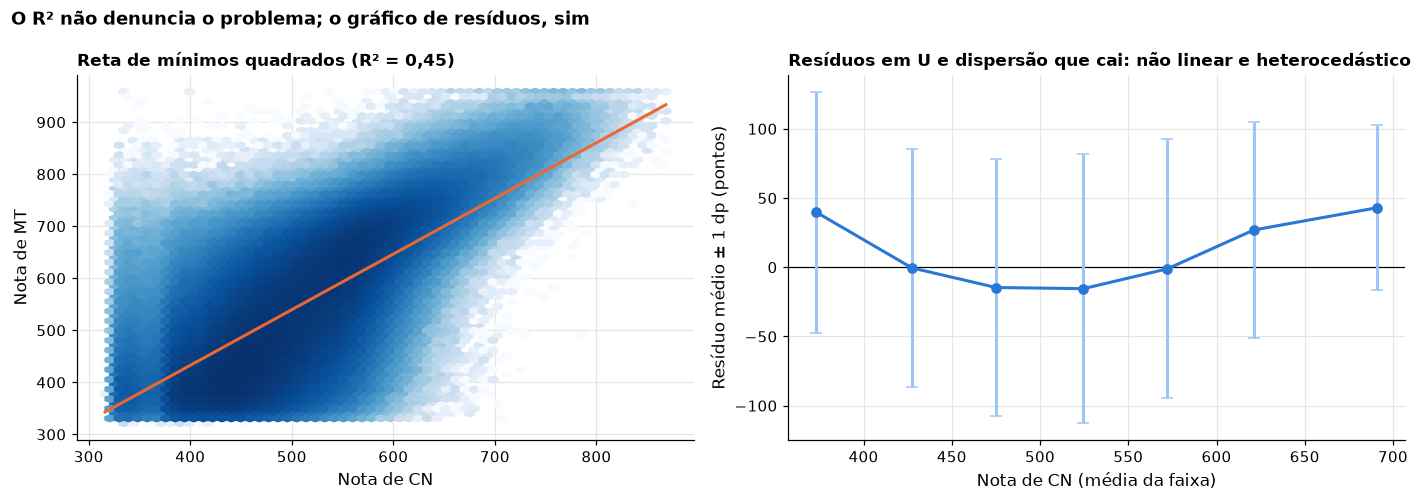

In [74]:
residuos = modelo_cn.resid
faixas = pd.cut(cn, [0, 400, 450, 500, 550, 600, 650, 1000])
diag = pd.DataFrame({'faixa de CN': faixas, 'resíduo': residuos}).groupby('faixa de CN', observed=True).resíduo.agg(['count', 'mean', 'std'])
display(diag.round(1))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))
ax = axes[0]
ax.hexbin(cn, mtv, gridsize=60, cmap='Blues', bins='log', mincnt=1)
xs = np.array([cn.min(), cn.max()])
ax.plot(xs, b0 + b1 * xs, color=LARANJA, lw=2)
ax.set_xlabel('Nota de CN'); ax.set_ylabel('Nota de MT')
ax.set_title(f'Reta de mínimos quadrados (R² = {br(modelo_cn.rsquared, 2)})', fontsize=11)
ax = axes[1]
centros = pd.Series(cn).groupby(faixas, observed=True).mean().to_numpy()   # média de CN em cada faixa
ax.axhline(0, color='black', lw=0.8)
ax.errorbar(centros, diag['mean'], yerr=diag['std'], fmt='o-', color=AZUL, ecolor='#9ec5f4', capsize=4, lw=2)
ax.set_xlabel('Nota de CN (média da faixa)'); ax.set_ylabel('Resíduo médio ± 1 dp (pontos)')
ax.set_title('Resíduos em U e dispersão que cai: não linear e heterocedástico', fontsize=11)
fig.suptitle('O R² não denuncia o problema; o gráfico de resíduos, sim', x=0.01, ha='left', fontweight='bold')
plt.tight_layout()
salvar(fig, 'm6_residuos_mt_cn')
plt.show()

## 5.3 Renda é ordinal: a codificação muda o r

In [75]:
codigo = base.Q006.map({c: i + 1 for i, c in enumerate(FAIXAS_RENDA)}).to_numpy()
ponto_medio = dict(zip(FAIXAS_RENDA, [0, 660, 1650, 2310, 2970, 3630, 4620, 5940, 7260, 8580, 9900, 11220, 12540,
                                      14520, 17820, 23100, 30000]))   # aproximação declarada (A = 0; Q = 30.000)
renda_rs = base.Q006.map(ponto_medio).to_numpy()
print('Médias de MT por faixa:', base.groupby('Q006').NU_NOTA_MT.mean().loc[FAIXAS_RENDA].round(1).to_dict())
print(f'r (código 1–17)          = {br(np.corrcoef(codigo, mtv)[0, 1], 3)}')
print(f'r (ponto médio em R$)    = {br(np.corrcoef(renda_rs, mtv)[0, 1], 3)}')
print(f'r (log do ponto médio)   = {br(np.corrcoef(np.log(np.clip(renda_rs, 330, None)), mtv)[0, 1], 3)}')
print(f'Spearman (postos)        = {br(stats.spearmanr(codigo[idx], mtv[idx]).statistic, 3)} (300 mil pares)')

Médias de MT por faixa: {'A': 461.6, 'B': 483.2, 'C': 516.4, 'D': 536.5, 'E': 554.9, 'F': 573.4, 'G': 589.0, 'H': 606.9, 'I': 617.8, 'J': 628.7, 'K': 637.0, 'L': 644.7, 'M': 653.6, 'N': 658.5, 'O': 667.1, 'P': 678.6, 'Q': 691.2}
r (código 1–17)          = 0,467
r (ponto médio em R$)    = 0,410
r (log do ponto médio)   = 0,475
Spearman (postos)        = 0,460 (300 mil pares)


## 5.4 Regressão múltipla: controlar o que foi medido

In [76]:
conc = base[base.TP_ESCOLA.isin([2, 3])].copy()          # concluintes de 2023 que informaram escola
conc['renda'] = conc.Q006.map({c: i + 1 for i, c in enumerate(FAIXAS_RENDA)})
conc['privada'] = (conc.TP_ESCOLA == 3).astype(int)
conc['mulher'] = (conc.TP_SEXO == 'F').astype(int)
# Cor/raça autodeclarada: indicadoras 0/1, com "Branca" (o maior grupo) como referência
conc['preta'] = (conc.TP_COR_RACA == 2).astype(int)
conc['parda'] = (conc.TP_COR_RACA == 3).astype(int)
conc['indígena'] = (conc.TP_COR_RACA == 5).astype(int)
conc['amarela ou não decl.'] = conc.TP_COR_RACA.isin([0, 4]).astype(int)
COR_VARS = ['preta', 'parda', 'indígena', 'amarela ou não decl.']

def nome_modelo(vars_):
    partes = [v for v in vars_ if v not in COR_VARS] + (['cor/raça'] if set(COR_VARS) <= set(vars_) else [])
    return 'MT ~ ' + ' + '.join(partes)

linhas = []
for vars_ in (COR_VARS, ['renda'], ['renda', 'privada'], ['renda', 'privada', 'mulher'], ['renda', 'privada', 'mulher'] + COR_VARS):
    mo = sm.OLS(conc.NU_NOTA_MT, sm.add_constant(conc[vars_])).fit()
    linhas.append({'modelo': nome_modelo(vars_), **{v: mo.params[v] for v in vars_}, 'R²': mo.rsquared})
print('n =', len(conc))
pd.DataFrame(linhas).set_index('modelo')[['renda', 'privada', 'mulher'] + COR_VARS + ['R²']].round(3)

n = 1002841


,renda,privada,mulher,preta,parda,indígena,amarela ou não decl.,R²
modelo,,,,,,,,
MT ~ cor/raça,NaN,NaN,NaN,-73.352,-61.847,-103.185,-37.176,0.068
MT ~ renda,15.688,NaN,NaN,NaN,NaN,NaN,NaN,0.228
MT ~ renda + privada,11.881,60.585,NaN,NaN,NaN,NaN,NaN,0.256
MT ~ renda + privada + mulher,11.408,60.729,-34.041,NaN,NaN,NaN,NaN,0.275
MT ~ renda + privada + mulher + cor/raça,10.395,57.850,-34.912,-35.056,-25.670,-56.247,-16.909,0.286


Ao incluir o tipo de escola, o coeficiente da renda **cai**: parte da associação atribuída à renda era associação com a escola privada (renda e escola andam juntas). Isso é **controle de confundimento observado**; variáveis não medidas continuam lá.

**Cor/raça (referência: brancos):** sozinha, a cor/raça está associada a diferenças de −73 pontos (pretos), −62 (pardos) e −103 (indígenas). Com renda, escola e sexo no modelo, as diferenças caem para cerca da metade (−35, −26 e −56): parte acompanha a renda e a escola, e parte **permanece**. O que permanece **não** é "o efeito da cor": é a diferença que estas variáveis não explicam (território, qualidade da escola, discriminação e outros fatores não medidos). E o R² quase não sobe (0,275 → 0,286): a maior parte da variação de MT está **dentro** dos grupos.

## 5.5 Quarteto de Anscombe: o resumo não substitui o gráfico

Dados publicados por Anscombe (1973), *Graphs in Statistical Analysis*, The American Statistician 27(1):17–21. Os quatro conjuntos têm praticamente a mesma média, variância, correlação e reta de regressão, e relações completamente diferentes (Módulos 2 e 7).

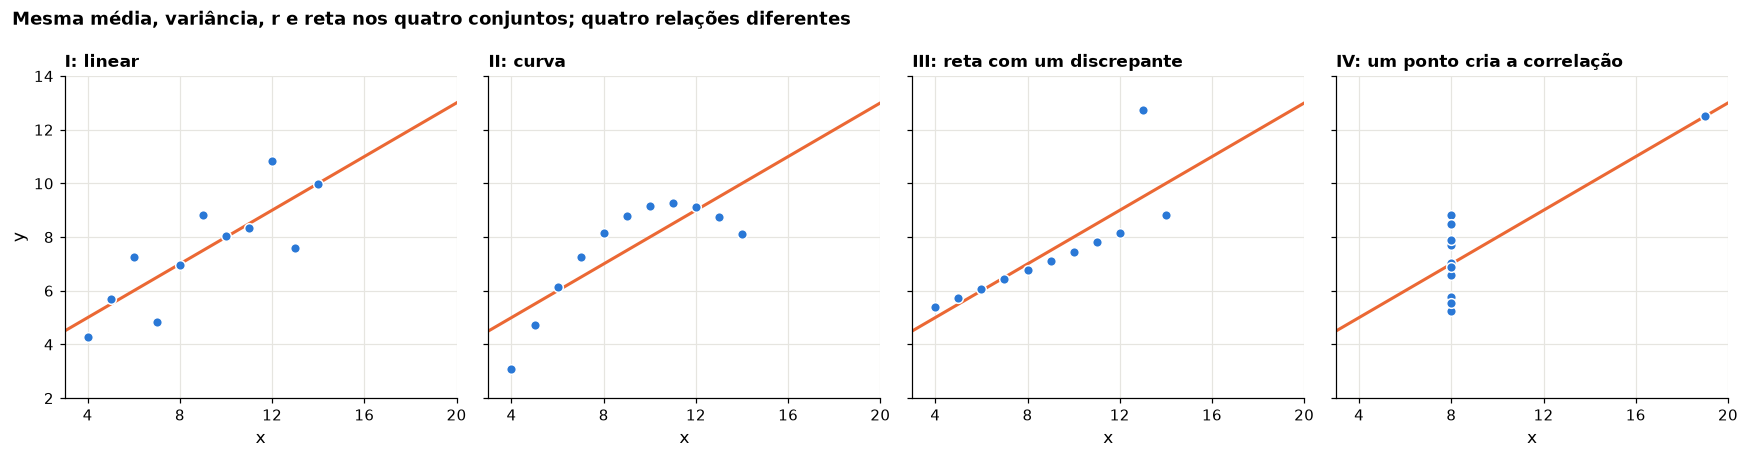

,média x,média y,variância y,r,intercepto,inclinação
I: linear,9.0,7.501,4.127,0.816,3.000,0.5
II: curva,9.0,7.501,4.128,0.816,3.001,0.5
III: reta com um discrepante,9.0,7.500,4.123,0.816,3.002,0.5
IV: um ponto cria a correlação,9.0,7.501,4.123,0.817,3.002,0.5


In [77]:
X_ANS = [10, 8, 13, 9, 11, 14, 6, 4, 12, 7, 5]
ANSCOMBE = {
    'I: linear':                      (X_ANS, [8.04, 6.95, 7.58, 8.81, 8.33, 9.96, 7.24, 4.26, 10.84, 4.82, 5.68]),
    'II: curva':                      (X_ANS, [9.14, 8.14, 8.74, 8.77, 9.26, 8.10, 6.13, 3.10, 9.13, 7.26, 4.74]),
    'III: reta com um discrepante':   (X_ANS, [7.46, 6.77, 12.74, 7.11, 7.81, 8.84, 6.08, 5.39, 8.15, 6.42, 5.73]),
    'IV: um ponto cria a correlação': ([8, 8, 8, 8, 8, 8, 8, 19, 8, 8, 8], [6.58, 5.76, 7.71, 8.84, 8.47, 7.04, 5.25, 12.50, 5.56, 7.91, 6.89]),
}
linhas = {}
fig, axes = plt.subplots(1, 4, figsize=(16, 4.2), sharex=True, sharey=True)
xs = np.array([3, 20])
for ax, (nome, (x, y)) in zip(axes, ANSCOMBE.items()):
    x, y = np.array(x, dtype=float), np.array(y)
    b1, b0 = np.polyfit(x, y, 1)
    linhas[nome] = {'média x': x.mean(), 'média y': y.mean(), 'variância y': y.var(ddof=1),
                    'r': np.corrcoef(x, y)[0, 1], 'intercepto': b0, 'inclinação': b1}
    ax.plot(xs, b0 + b1 * xs, color=LARANJA, lw=2)
    ax.scatter(x, y, s=40, color=AZUL, edgecolor='white', linewidth=1, zorder=3)
    ax.set_title(nome, fontsize=11)
    ax.set_xlabel('x')
axes[0].set_ylabel('y')
axes[0].set_xlim(3, 20); axes[0].set_ylim(2, 14)
axes[0].set_xticks([4, 8, 12, 16, 20])
fig.suptitle('Mesma média, variância, r e reta nos quatro conjuntos; quatro relações diferentes', x=0.01, ha='left', fontweight='bold')
plt.tight_layout()
salvar(fig, 'm6_anscombe')
plt.show()
pd.DataFrame(linhas).T.round(3)

### IA — Prompts do Módulo 7

**Prompt 1 — a regressão múltipla do slide "o que permanece"**

```text
Papel: Você é um estatístico revisando uma análise para gestores públicos.

Contexto: DataFrame conc com os concluintes de 2023 que informaram escola (base de análise do ENEM
2023, cerca de 1 milhão). Colunas: NU_NOTA_MT; Q006 (renda, 17 faixas ordinais A–Q); TP_ESCOLA (2
pública, 3 privada); TP_SEXO (M, F); TP_COR_RACA (0 não declarada, 1 branca, 2 preta, 3 parda, 4
amarela, 5 indígena). Dados observacionais.

Pergunta: Quanto da variação de MT está associada à renda, ao tipo de escola, ao sexo e à cor/raça,
cada uma mantidas as outras constantes?

Tarefa: (1) Proponha a codificação: renda como código 1–17 (diga o que isso supõe); escola, sexo e
cor/raça como indicadoras 0/1, com “branca” como referência. (2) Ajuste com statsmodels (OLS) cinco
modelos: só cor/raça; só renda; + escola; + sexo; + cor/raça. (3) Tabela com coeficientes, IC95% e
R² de cada modelo. (4) Diagnóstico: resíduos × ajustados e VIF.

Restrições: Não use “efeito” nem “causa”. Diga que variáveis importantes ficaram de fora. Só código,
sem números.

Formato: Modelos lado a lado; diagnóstico; quatro frases de interpretação em linguagem de
associação.
```

**Verificação independente** (célula abaixo; os coeficientes e o R² estão na tabela da seção 5.4):
- n = 1.002.841
- Renda: +15,7 → +11,9 quando a escola entra
- Preta: −73,4 → −35,1; R²: 0,068 → 0,286
- Cor/raça como indicadoras, nunca como número 0–6
- Texto: “diferença que permanece”, não “efeito da cor”

**Outros prompts do bloco — ler um gráfico de resíduos**
```text
Descrevo o gráfico de resíduos: [padrão em U / funil / pontos isolados].
Diga: (a) qual suposição está violada, (b) qual a consequência para IC e testes,
(c) duas correções possíveis com vantagens e riscos, (d) como saber se a correção funcionou.
Não presuma informações que não descrevi.
```

**Auditoria de linguagem causal e de generalização** (use quando a IA escrever "efeito" ou "a renda determina a nota")
```text
Analise o parágrafo abaixo de um relatório. Marque cada frase que sugere causa (palavras como
"efeito", "impacto", "provoca", "explica", "devido a") e diga se o delineamento descrito
(observacional/experimental) sustenta a causa. Verifique também se a conclusão vale para quem ficou
fora da base (por exemplo, quem não respondeu à pergunta ou não compareceu à prova).
Reescreva as frases com linguagem de associação.
[colar parágrafo — por exemplo: "A renda explica 23% da nota de Matemática; estudar em escola
privada tem efeito positivo sobre o desempenho de todos os estudantes do país."]
```


In [78]:
# Verificação do Prompt 1: n, codificação da cor/raça e VIF do modelo completo (o diagnóstico pedido no item 4)
vars_comp = ['renda', 'privada', 'mulher'] + COR_VARS
print('n =', br(len(conc), 0))
print('Cor/raça como indicadoras 0/1 (não como número 0–6):', bool(conc[COR_VARS].isin([0, 1]).all().all()))
Xc = sm.add_constant(conc[vars_comp]).to_numpy(dtype=float)
vif = pd.Series([variance_inflation_factor(Xc, i + 1) for i in range(len(vars_comp))], index=vars_comp)
display(vif.round(2).to_frame('VIF (acima de 10 indica colinearidade forte)'))

n = 1.002.841
Cor/raça como indicadoras 0/1 (não como número 0–6): True


,VIF (acima de 10 indica colinearidade forte)
renda,1.57
privada,1.49
mulher,1.01
preta,1.16
parda,1.24
indígena,1.01
amarela ou não decl.,1.03


---
# Encerramento: checklist de relatório

Para cada resultado levado à diretoria:
1. **Pergunta e hipótese** escritas antes da análise (pré-registro).
2. **População** analisada e quem ficou de fora (nulos, zeros, filtros, presença).
3. **Plano amostral** e justificativa do n (precisão ou menor efeito relevante).
4. **Efeito + IC95% + valor-p + tamanho do efeito** (nunca só o valor-p).
5. **Leitura de relevância** com a margem definida antes (diferente e relevante / irrelevante / inconclusivo).
6. **Limitações:** delineamento observacional, confundidores, quem ficou fora da base.
7. **Registro de IA:** prompt, modelo, data e a verificação independente feita.

In [79]:
# Modelo de registro de uso de IA (regra 7): uma linha por prompt usado na análise
registro_ia = pd.DataFrame(columns=['data', 'ferramenta/modelo', 'parte do notebook', 'prompt (resumo)',
                                    'o que foi aproveitado', 'verificação independente feita', 'resultado da verificação'])
registro_ia

,data,ferramenta/modelo,parte do notebook,prompt (resumo),o que foi aproveitado,verificação independente feita,resultado da verificação
